# $\mathrm{Na}_{\mathrm{V}}1.5$ ensemble RMSF

This notebook compares structural variability across independently predicted AlphaFold ensembles generated with the original MSA (vanilla) and with targeted regions of the MSA masked. The central question is whether masking broadens or narrows the conformational ensemble locally, and whether those changes extend beyond the residues whose evolutionary information was removed.

RMSF is used here as a descriptive measure of variation across independently generated structures. It should not be interpreted as molecular dynamics fluctuation or as a direct measure of thermodynamic flexibility.

## Definition of ensemble RMSF

For residue $i$, the ensemble RMSF is calculated from the aligned Cα coordinates of the $M$ available models:

$$
\mathrm{RMSF}_i = \sqrt{\frac{1}{M}\sum_{k=1}^{M}\left\lVert\mathbf{r}_{i,k}-\overline{\mathbf{r}}_i\right\rVert^2}
$$

Here, $\mathbf{r}_{i,k}$ is the aligned Cα coordinate of residue $i$ in model $k$, and $\overline{\mathbf{r}}_i$ is its mean coordinate across the ensemble. RMSF is therefore always non-negative. Larger values indicate that the predicted coordinates occupy a broader region after common structural alignment.

The comparison plotted in the lower panels is

$$
\Delta\mathrm{RMSF}_i = \mathrm{RMSF}_{i,\mathrm{masked}}-\mathrm{RMSF}_{i,\mathrm{vanilla}}.
$$

Positive values indicate broader sampling in the masked ensemble; negative values indicate broader sampling in vanilla. A positive value is not automatically evidence of a better prediction—the sampled states must still be assessed against structural references and channel-state measurements.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display
repo_root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'scripts'/'ensemble_rmsf_analysis').is_dir())
sys.path.insert(0,str(repo_root))
from scripts.ensemble_rmsf_analysis.io import load_primary_profile
from scripts.ensemble_rmsf_analysis.comparisons import paired_rmsf_comparison,summarize_comparison
from scripts.ensemble_rmsf_analysis.experimental import paired_experimental_differences
from scripts.ensemble_rmsf_analysis.topology import TOPOLOGY
from shared.plotting import ensemble_protocol_palette,ACCENT_PALETTE
import importlib
import scripts.ensemble_rmsf_analysis.plotting as rmsf_plotting
importlib.reload(rmsf_plotting)
plot_whole_protein=rmsf_plotting.plot_whole_protein
plot_zoom=rmsf_plotting.plot_zoom
plot_whole_protein_lines=rmsf_plotting.plot_whole_protein_lines
plot_zoom_lines=rmsf_plotting.plot_zoom_lines
CHANNEL='nav15'
CHANNEL_LABEL='$\\mathrm{Na}_{\\mathrm{V}}1.5$'
CHANNEL_TOPOLOGY=TOPOLOGY[CHANNEL]
analysis_root=repo_root/CHANNEL/'dataRMSF'/'analysis'; figures=analysis_root/'figures'; tables=analysis_root/'tables'
figures.mkdir(parents=True,exist_ok=True); tables.mkdir(parents=True,exist_ok=True)

## Data and mask provenance

The profiles below were calculated from the selected structural ensembles after their common alignment. Coverage fields report how consistently a residue was resolved across the contributing models.

Direct-mask annotations use the supplied authoritative table in raw, 1-based AlphaFold query numbering. They are not presented as A3M-derived because the production A3M files are not present in this repository. Yellow background regions in the residue profiles mark these directly masked positions; they do not indicate statistical significance or unusually high RMSF.

In [2]:
profile,schema,profile_path=load_primary_profile(repo_root,CHANNEL)
PROFILE_IS_ALL_OK3='all_ok_3' in profile_path.name.lower()
display(Markdown(f'**RMSF profile in use:** `{profile_path.relative_to(repo_root)}`'))
if not PROFILE_IS_ALL_OK3:
    display(Markdown('> **QC warning:** this is the legacy `all_models` profile, not an All-OK-3 RMSF recomputation. Pre-convergence recycle snapshots are included, so long tails and numerical interpretations remain provisional until the cluster-generated `all_ok_3` profile is supplied.'))
display(pd.read_csv(tables/f'{CHANNEL}_profile_schema.csv'))
mask_path=tables/f'{CHANNEL}_a3m_mask_positions.csv'
MASKS_AVAILABLE=mask_path.is_file()
if MASKS_AVAILABLE:
    mask_table=pd.read_csv(mask_path)
    display(pd.read_csv(tables/f'{CHANNEL}_a3m_mask_summary.csv'))
else:
    mask_table=pd.DataFrame(columns=['dataset','raw_residue_number','directly_masked'])
    print('MASK TABLE MISSING: materialize the supplied authoritative table before running this notebook.')
    print('Run: python -m scripts.ensemble_rmsf_analysis.materialize_authoritative_masks')

**RMSF profile in use:** `nav15/dataRMSF/profiles/nav15_all_ok_3_per_residue_profiles.csv`

,channel,condition,dataset,sequence_condition,protocol,rows,minimum_raw_residue,maximum_raw_residue,selected_profile,rmsf_column,coverage_column
0,Nav1.5,multiple conditions,qqq_masked,qqq,masked,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction
1,Nav1.5,multiple conditions,qqq_masked_v2,qqq,masked_v2,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction
2,Nav1.5,multiple conditions,qqq_vanilla,qqq,vanilla,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction
3,Nav1.5,multiple conditions,wt_masked,wt,masked,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction
4,Nav1.5,multiple conditions,wt_masked_v2,wt,masked_v2,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction
5,Nav1.5,multiple conditions,wt_masked_v2_noIFM,wt,masked_v2_noIFM,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction
6,Nav1.5,multiple conditions,wt_vanilla,wt,vanilla,1572,1,1572,nav15/dataRMSF/profiles/nav15_all_models_per_r...,ensemble_rmsf_A,coverage_fraction


,condition,protocol,channel,dataset,mask_definition,mask_authority,raw_query_length,number_of_directly_masked_residues,directly_masked_ranges,validation_status
0,multiple conditions,not protocol-specific,nav15,wt_masked,nav15_standard,User-supplied authoritative RMSF mask table,1572,293,"159, 162, 165, 172, 198, 209, 220, 223, 226, 2...",passed
1,multiple conditions,not protocol-specific,nav15,wt_masked_v2,nav15_v2,User-supplied authoritative RMSF mask table,1572,193,"159, 162, 165, 172, 198, 209, 220, 223, 226, 2...",passed
2,multiple conditions,not protocol-specific,nav15,wt_masked_v2_noIFM,nav15_v2_noIFM,User-supplied authoritative RMSF mask table,1572,180,"159, 162, 165, 172, 198, 209, 220, 223, 226, 2...",passed
3,multiple conditions,not protocol-specific,nav15,qqq_masked,nav15_standard_plus_IFM,User-supplied authoritative RMSF mask table,1572,306,"159, 162, 165, 172, 198, 209, 220, 223, 226, 2...",passed
4,multiple conditions,not protocol-specific,nav15,qqq_masked_v2,nav15_v2,User-supplied authoritative RMSF mask table,1572,193,"159, 162, 165, 172, 198, 209, 220, 223, 226, 2...",passed


## Sequence-mapped channel topology

The compact blue block track at the bottom of each residue profile maps voltage-sensor helices, pore-forming segments, and selected motifs in raw AlphaFold-model numbering. Reviewed UniProt transmembrane features were transferred by globally aligning each actual model construct to its canonical sequence: P15387 for Kv2.1, Q14524 for Nav1.5, and Q13936 for Cav1.2. This step is essential for the shortened Kv2.1 and Nav1.5 constructs.

UniProt boundaries describe the membrane-spanning core rather than every structurally helical residue. The Cav1.2 DI-S6 cytosolic extension containing G402 and G406 is shown separately. Pore-helix or motif-derived annotations remain explicitly provisional in `scripts/ensemble_rmsf_analysis/topology.py`.

The blue topology blocks and yellow masking bands encode different information: blue identifies the sequence-mapped structural segment; yellow identifies residues whose MSA information was directly masked.

In [3]:
topology_table=pd.DataFrame(CHANNEL_TOPOLOGY)
topology_table.to_csv(tables/f'{CHANNEL}_sequence_mapped_topology.csv',index=False)
display(topology_table)

,label,start,end,domain,confidence
0,DI S1,123,152,DI,provisional
1,DI S2,159,179,DI,provisional
2,DI S3,187,211,DI,provisional
3,DI S4,215,239,DI,provisional
4,DI S5,246,266,DI,provisional
5,DI S6,267,282,DI,provisional
6,DII S1,382,418,DII,provisional
7,DII S2,514,543,DII,provisional
8,DII S3,584,609,DII,provisional
9,DII S4,612,630,DII,provisional


## Residue-resolved vanilla–masked comparisons

Each comparison uses the vanilla and masked ensembles for the same protein sequence. The first representation uses residue bars, which makes individual positions explicit. The second uses continuous lines with a translucent fill from zero to the RMSF curve. That fill represents RMSF magnitude, not a confidence interval or standard deviation. Mutation-centered panels then enlarge the relevant local sequence window.

### WT: vanilla versus masked

#### Whole-protein residue profile — bar representation

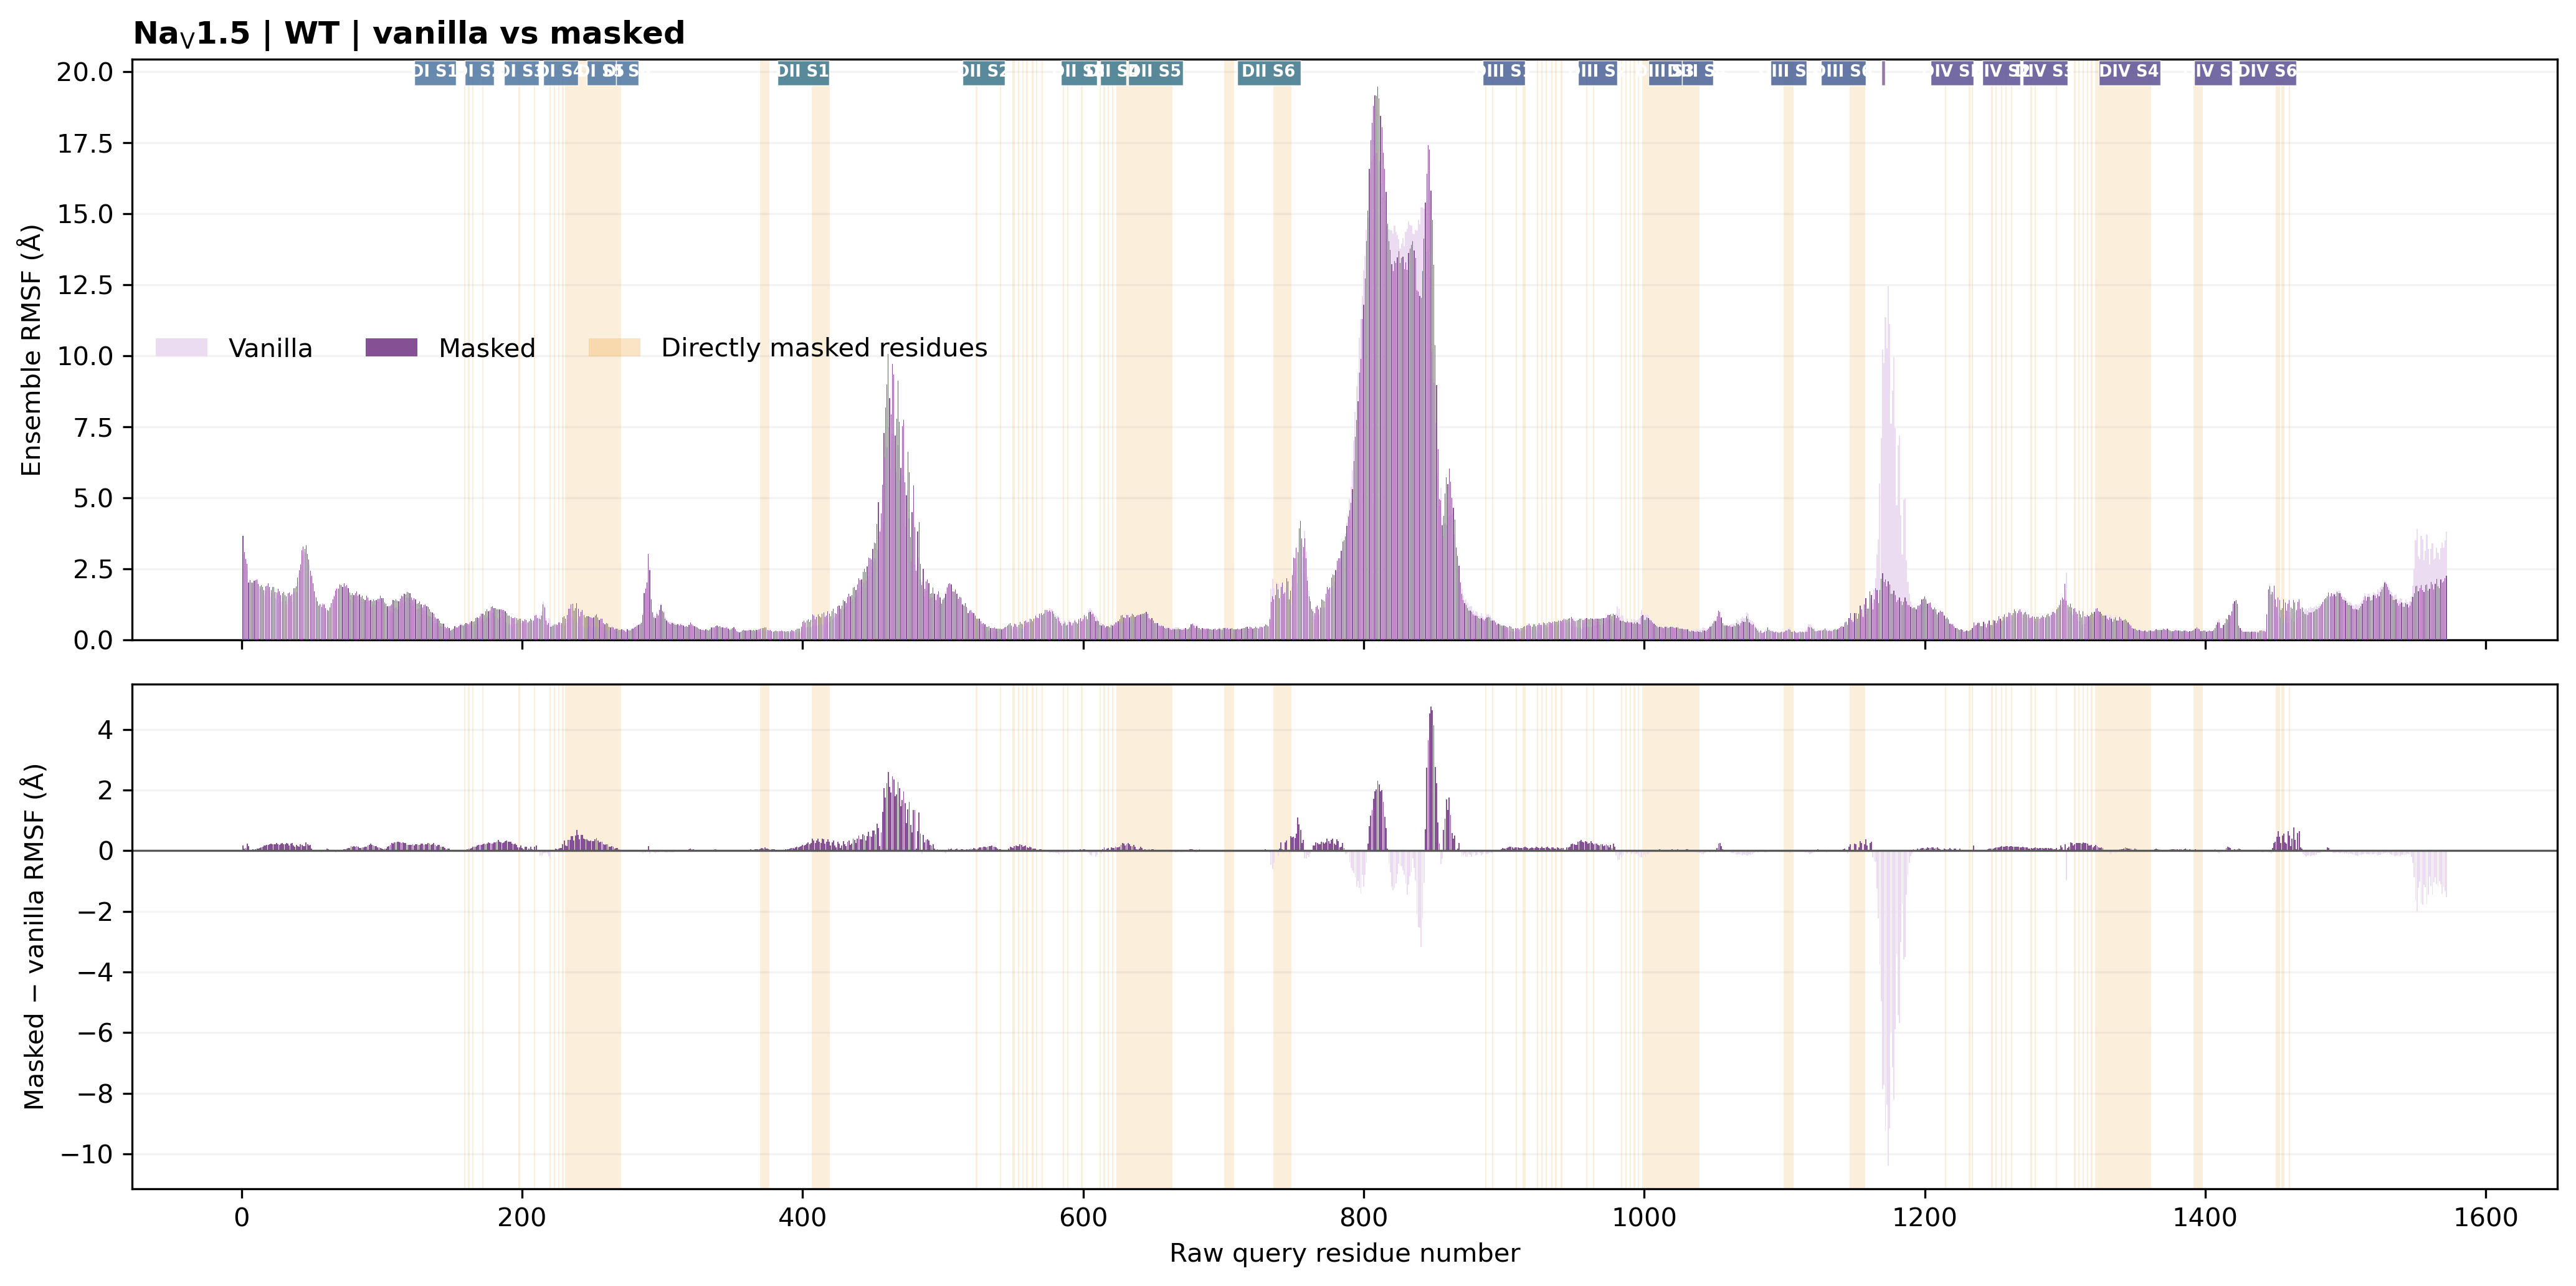

#### Whole-protein residue profile — line and magnitude-fill representation

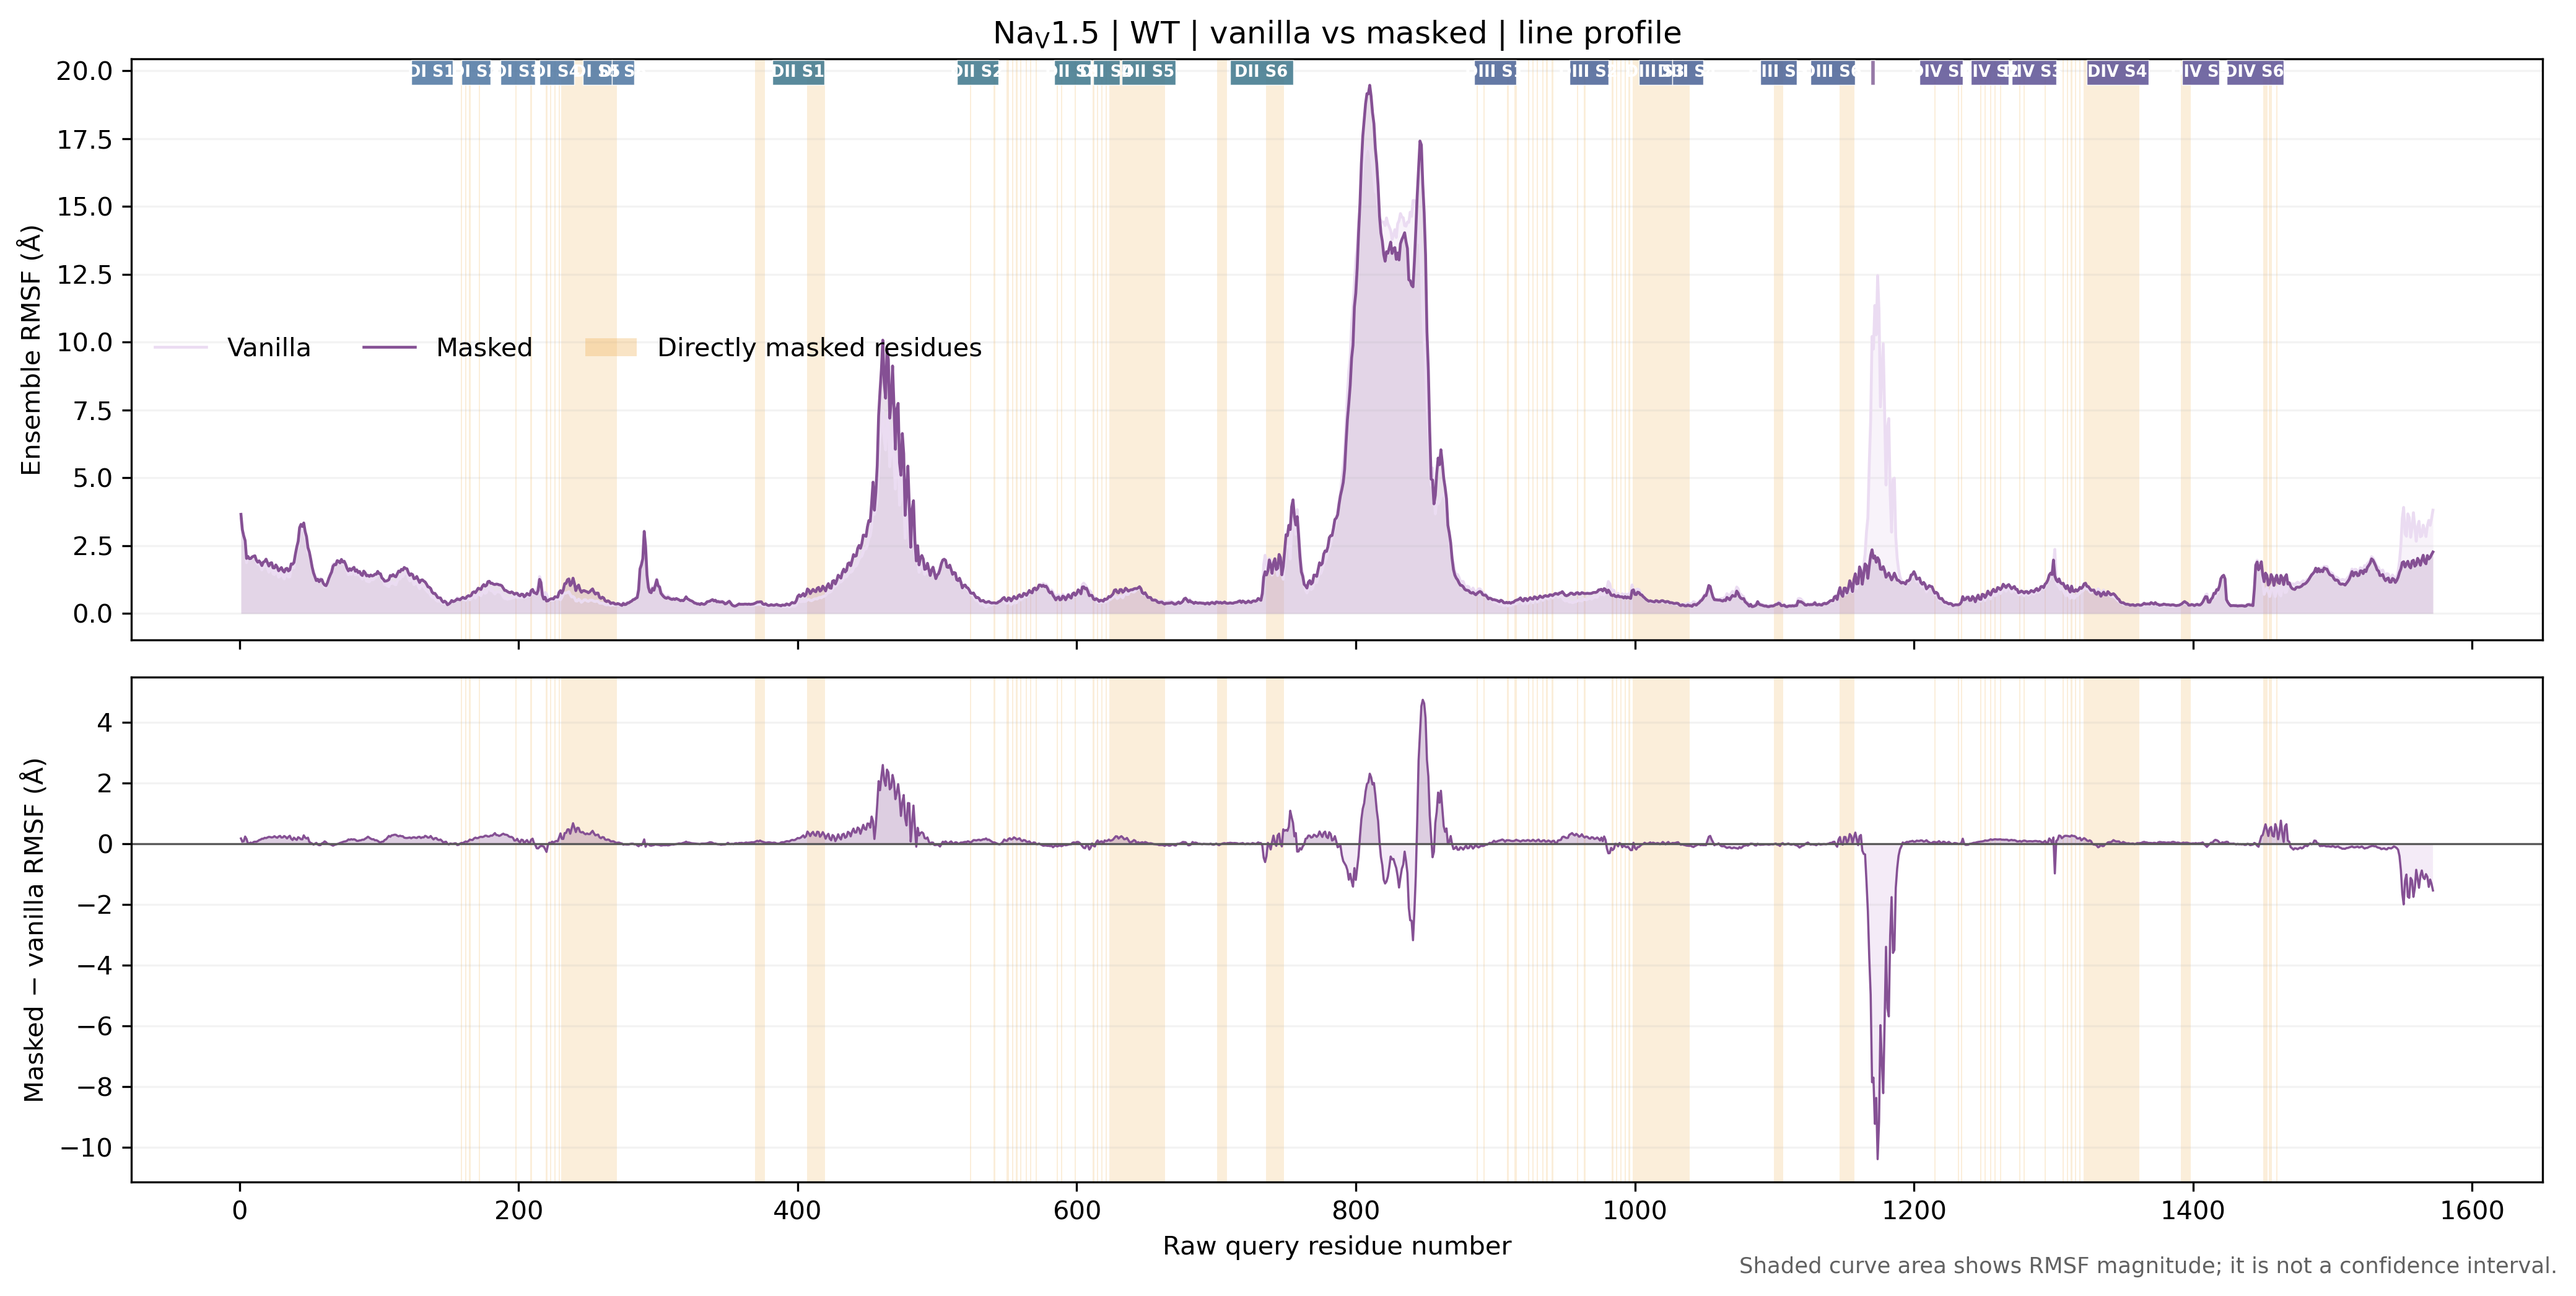

#### Mutation-centered window: raw residues 1140–1200

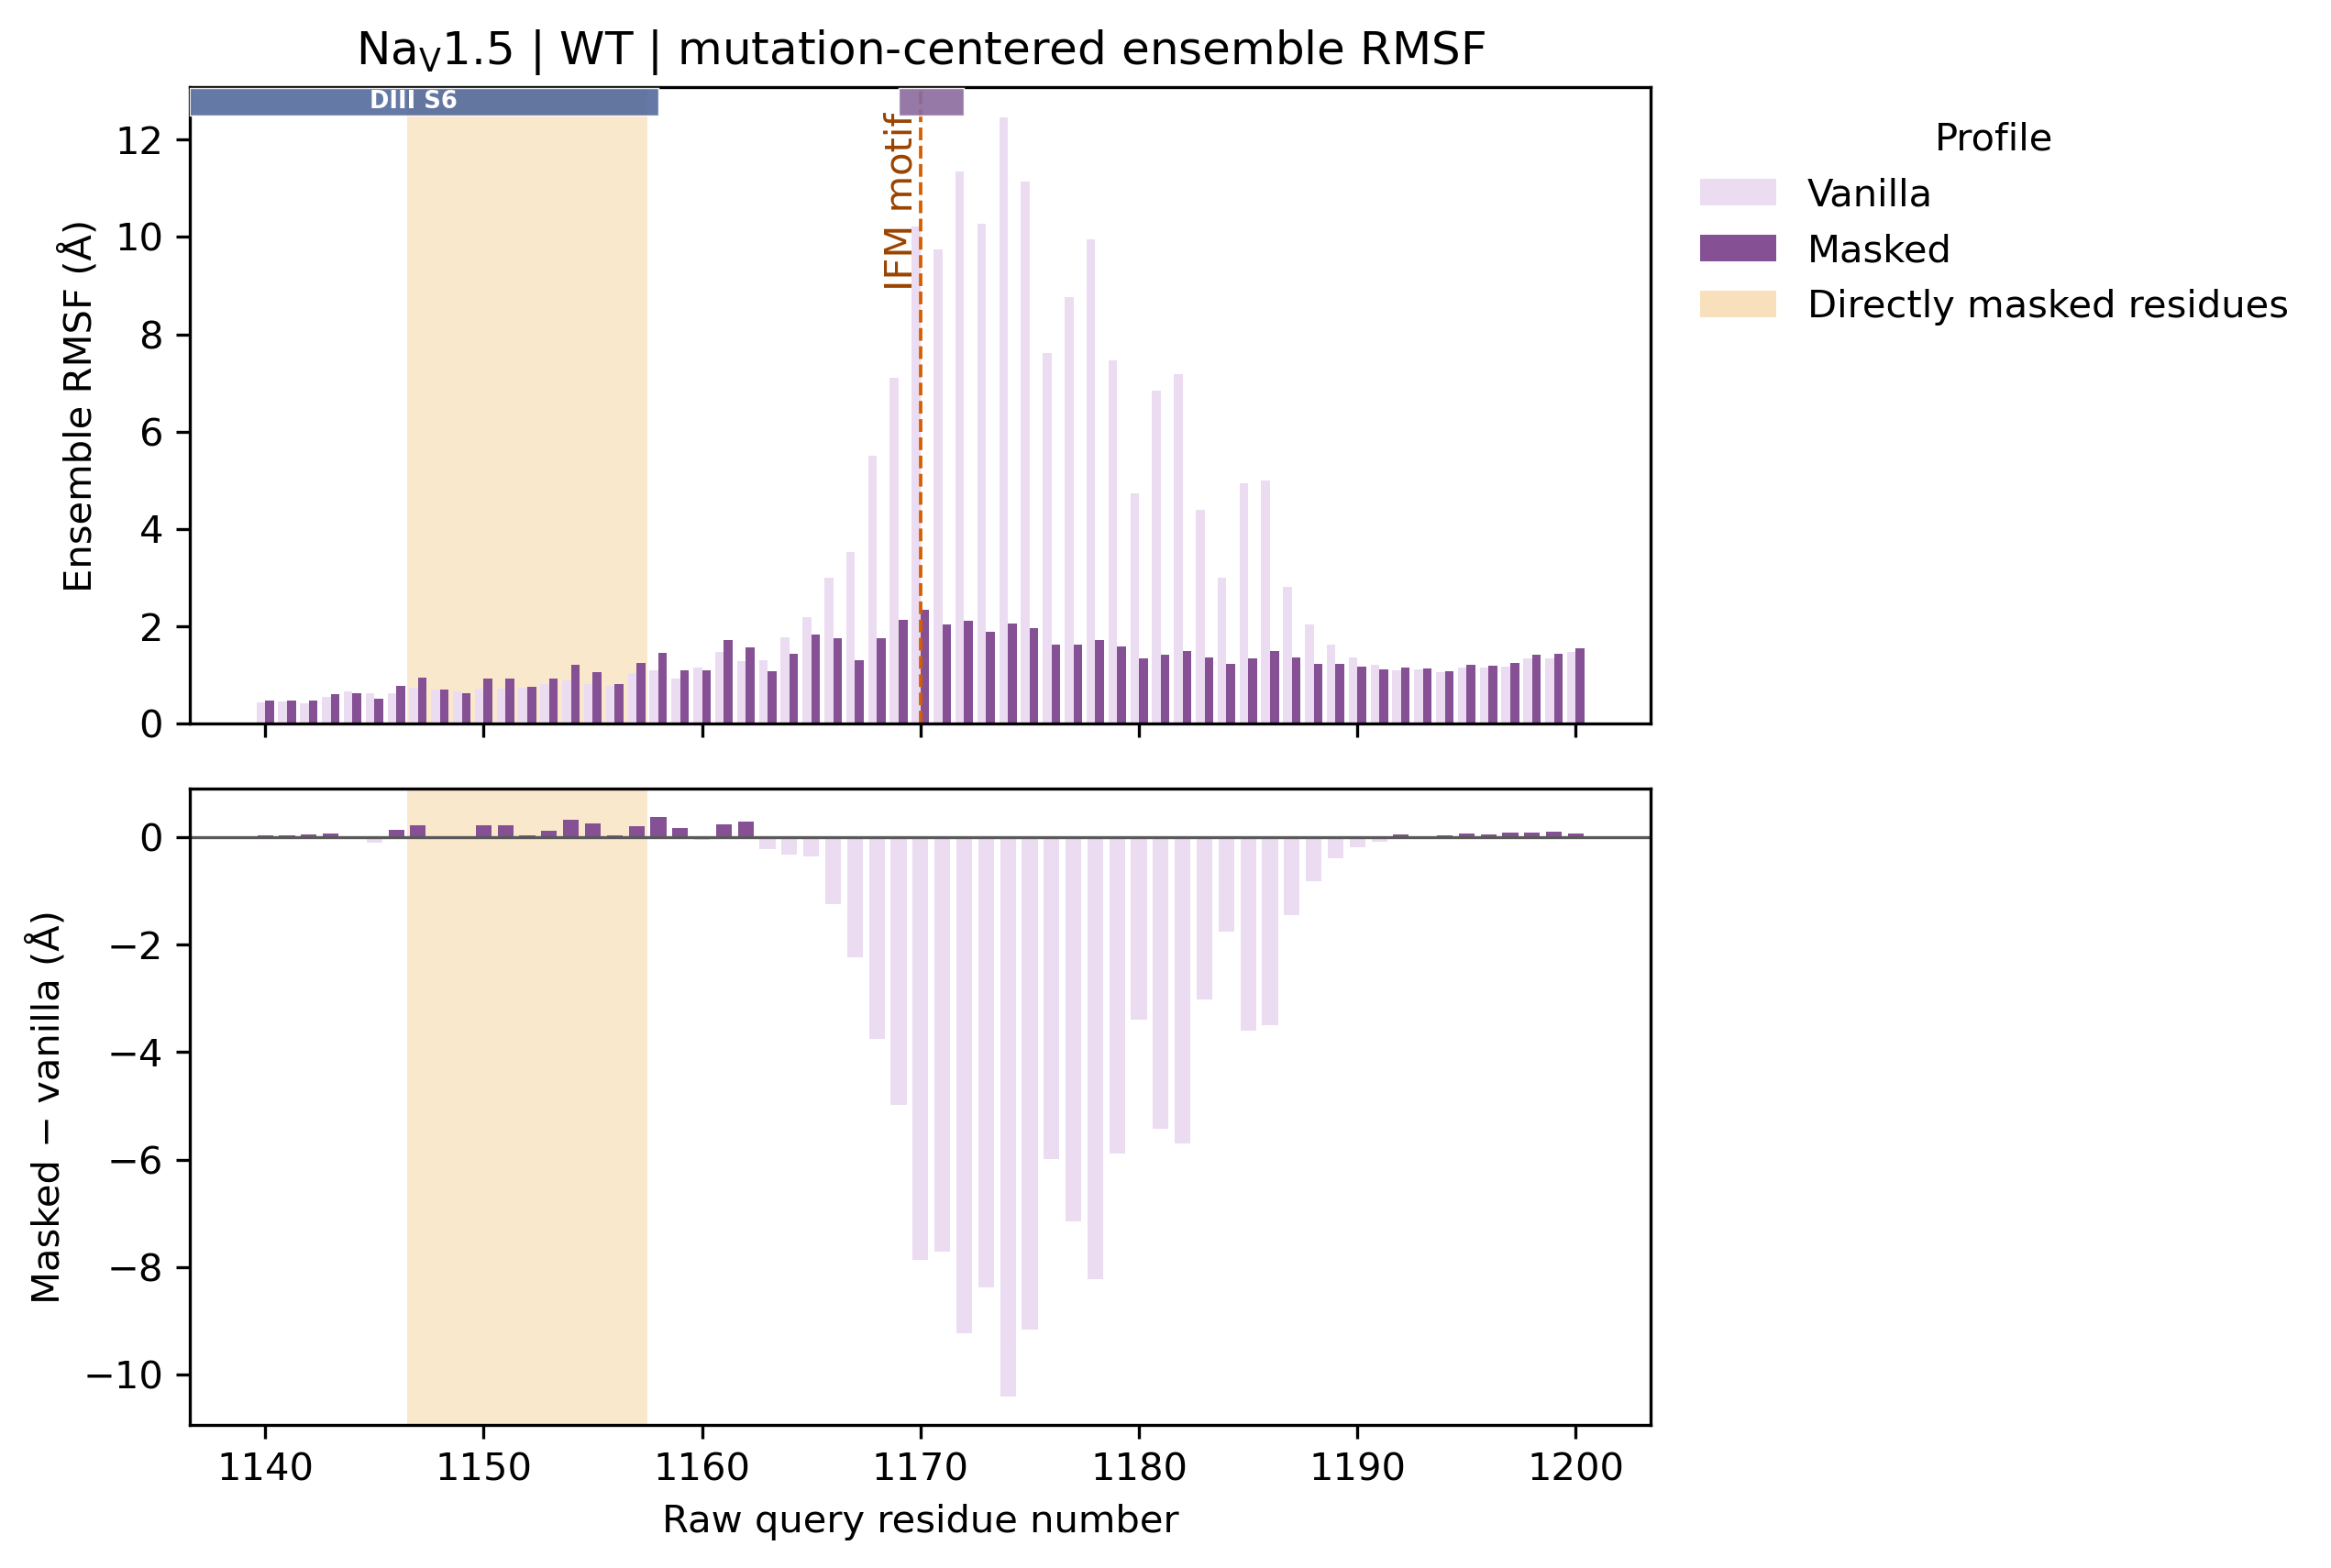

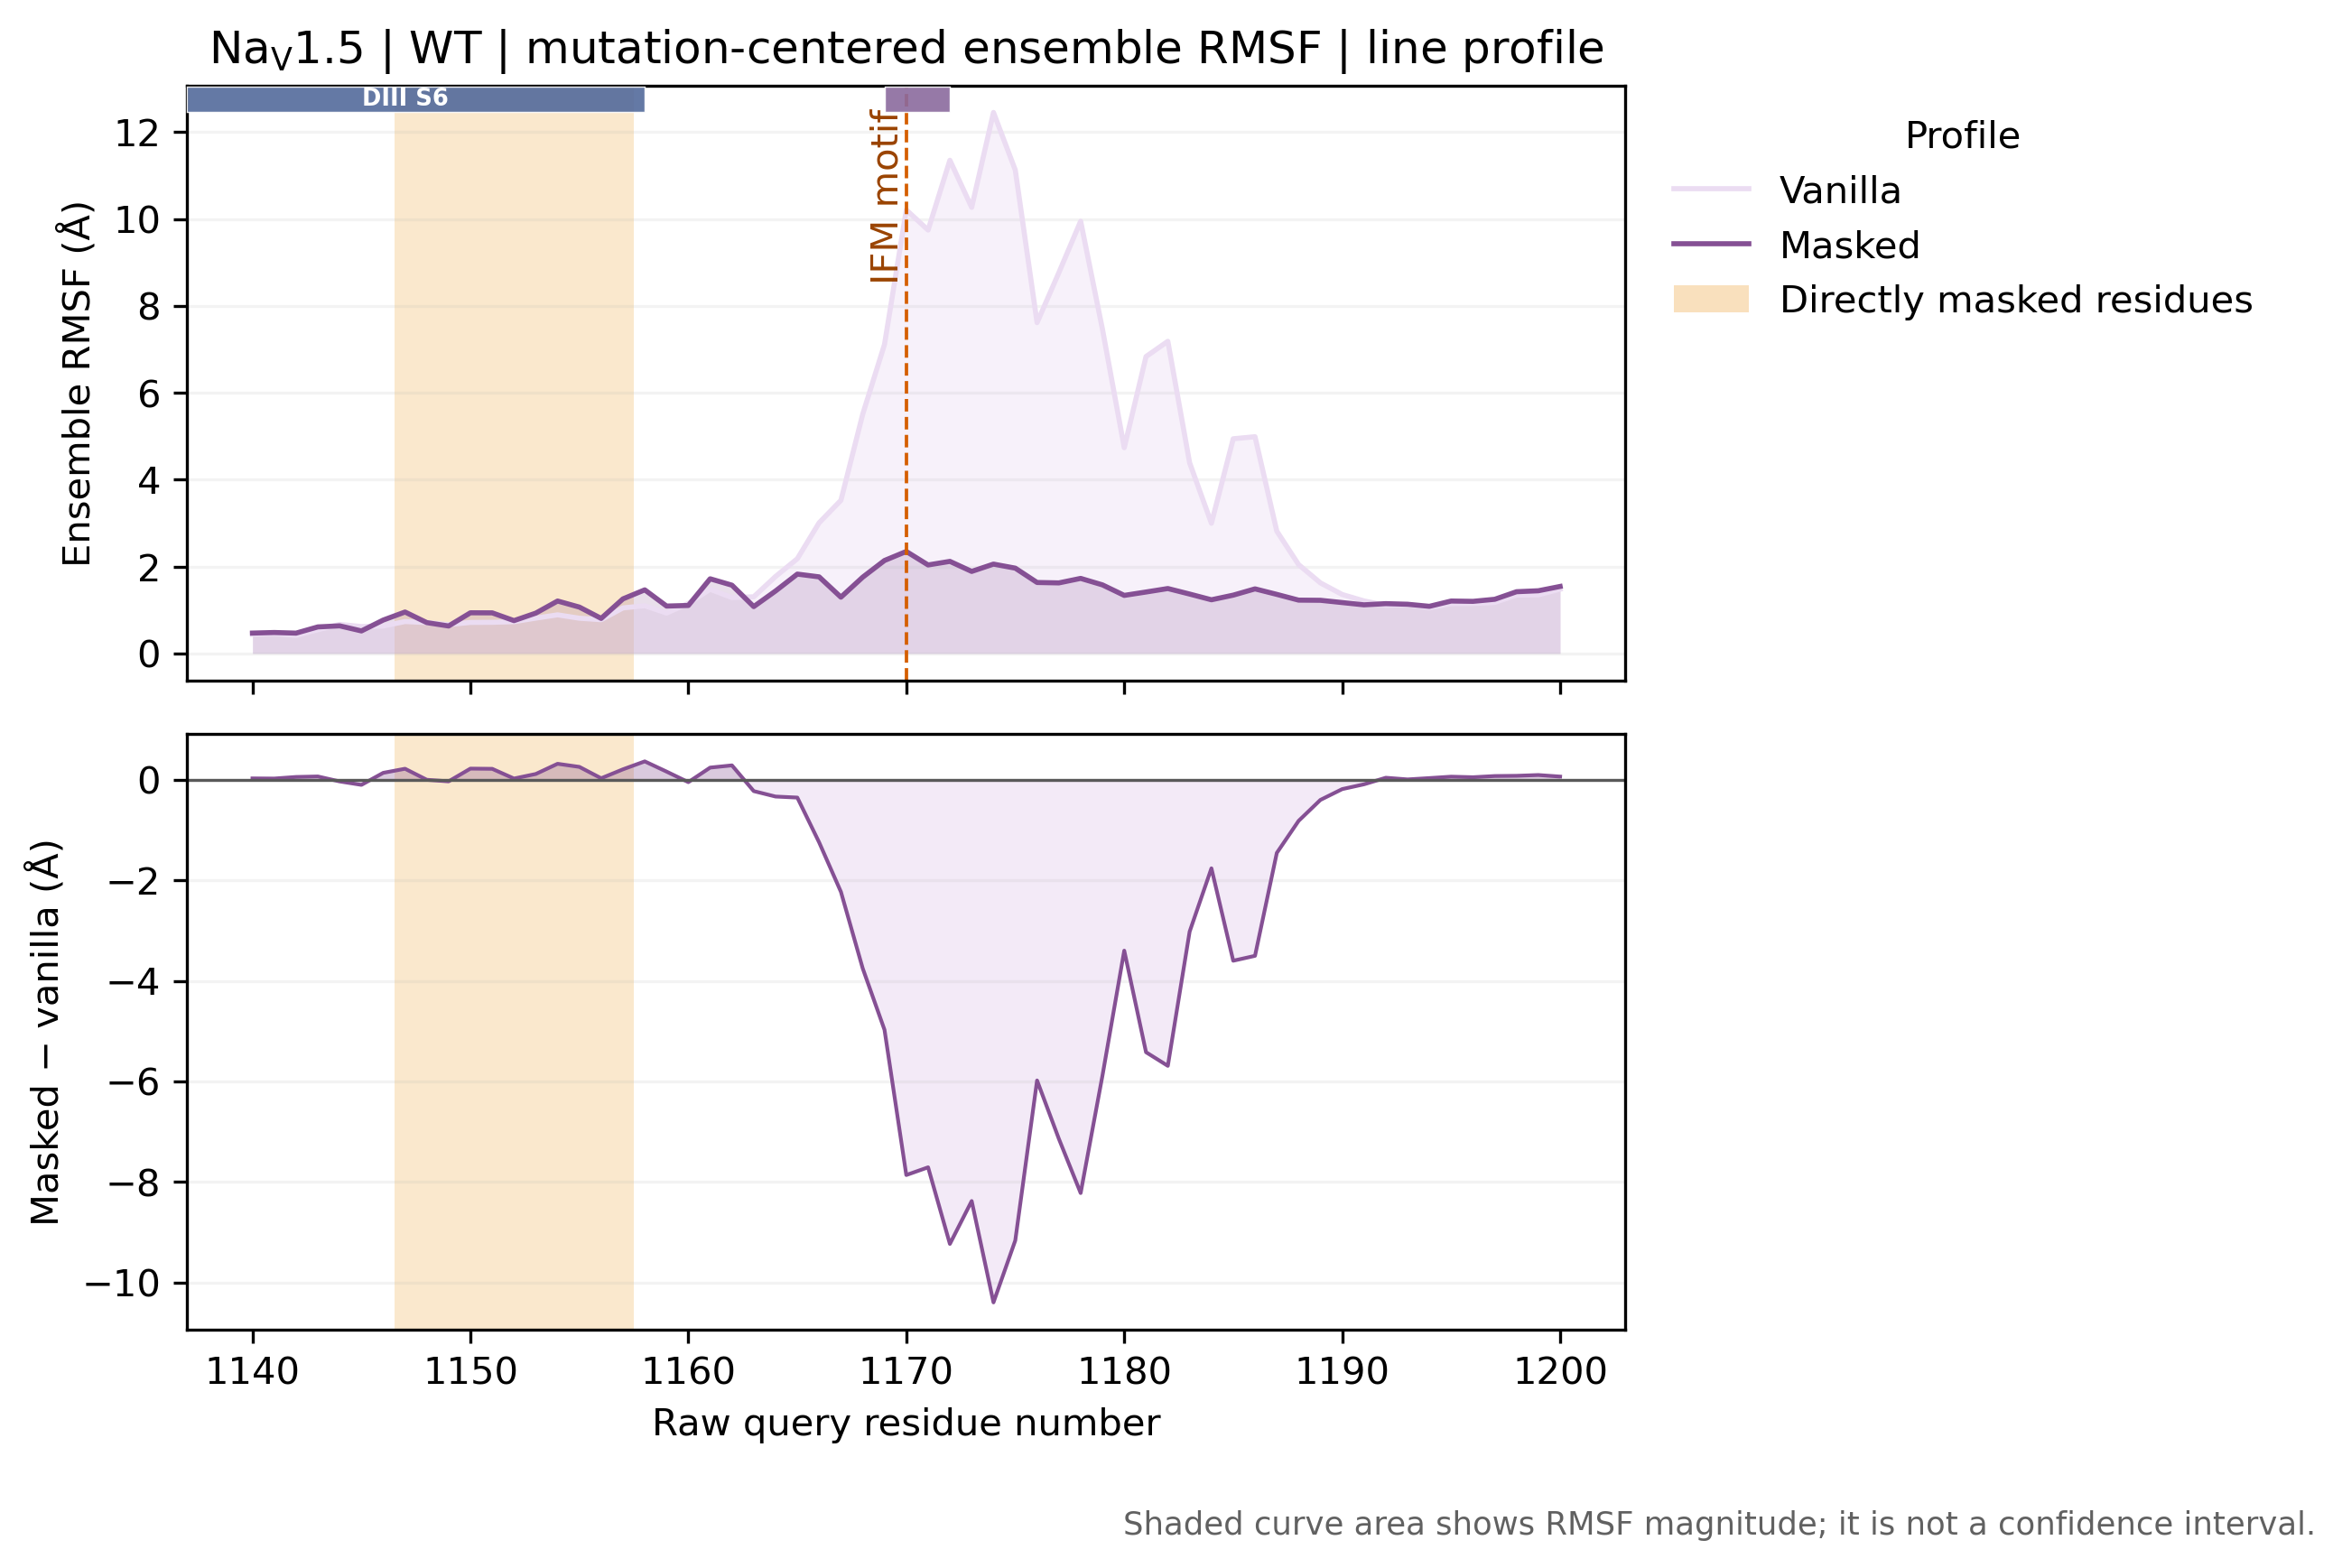

### WT: vanilla versus masked v2

#### Whole-protein residue profile — bar representation

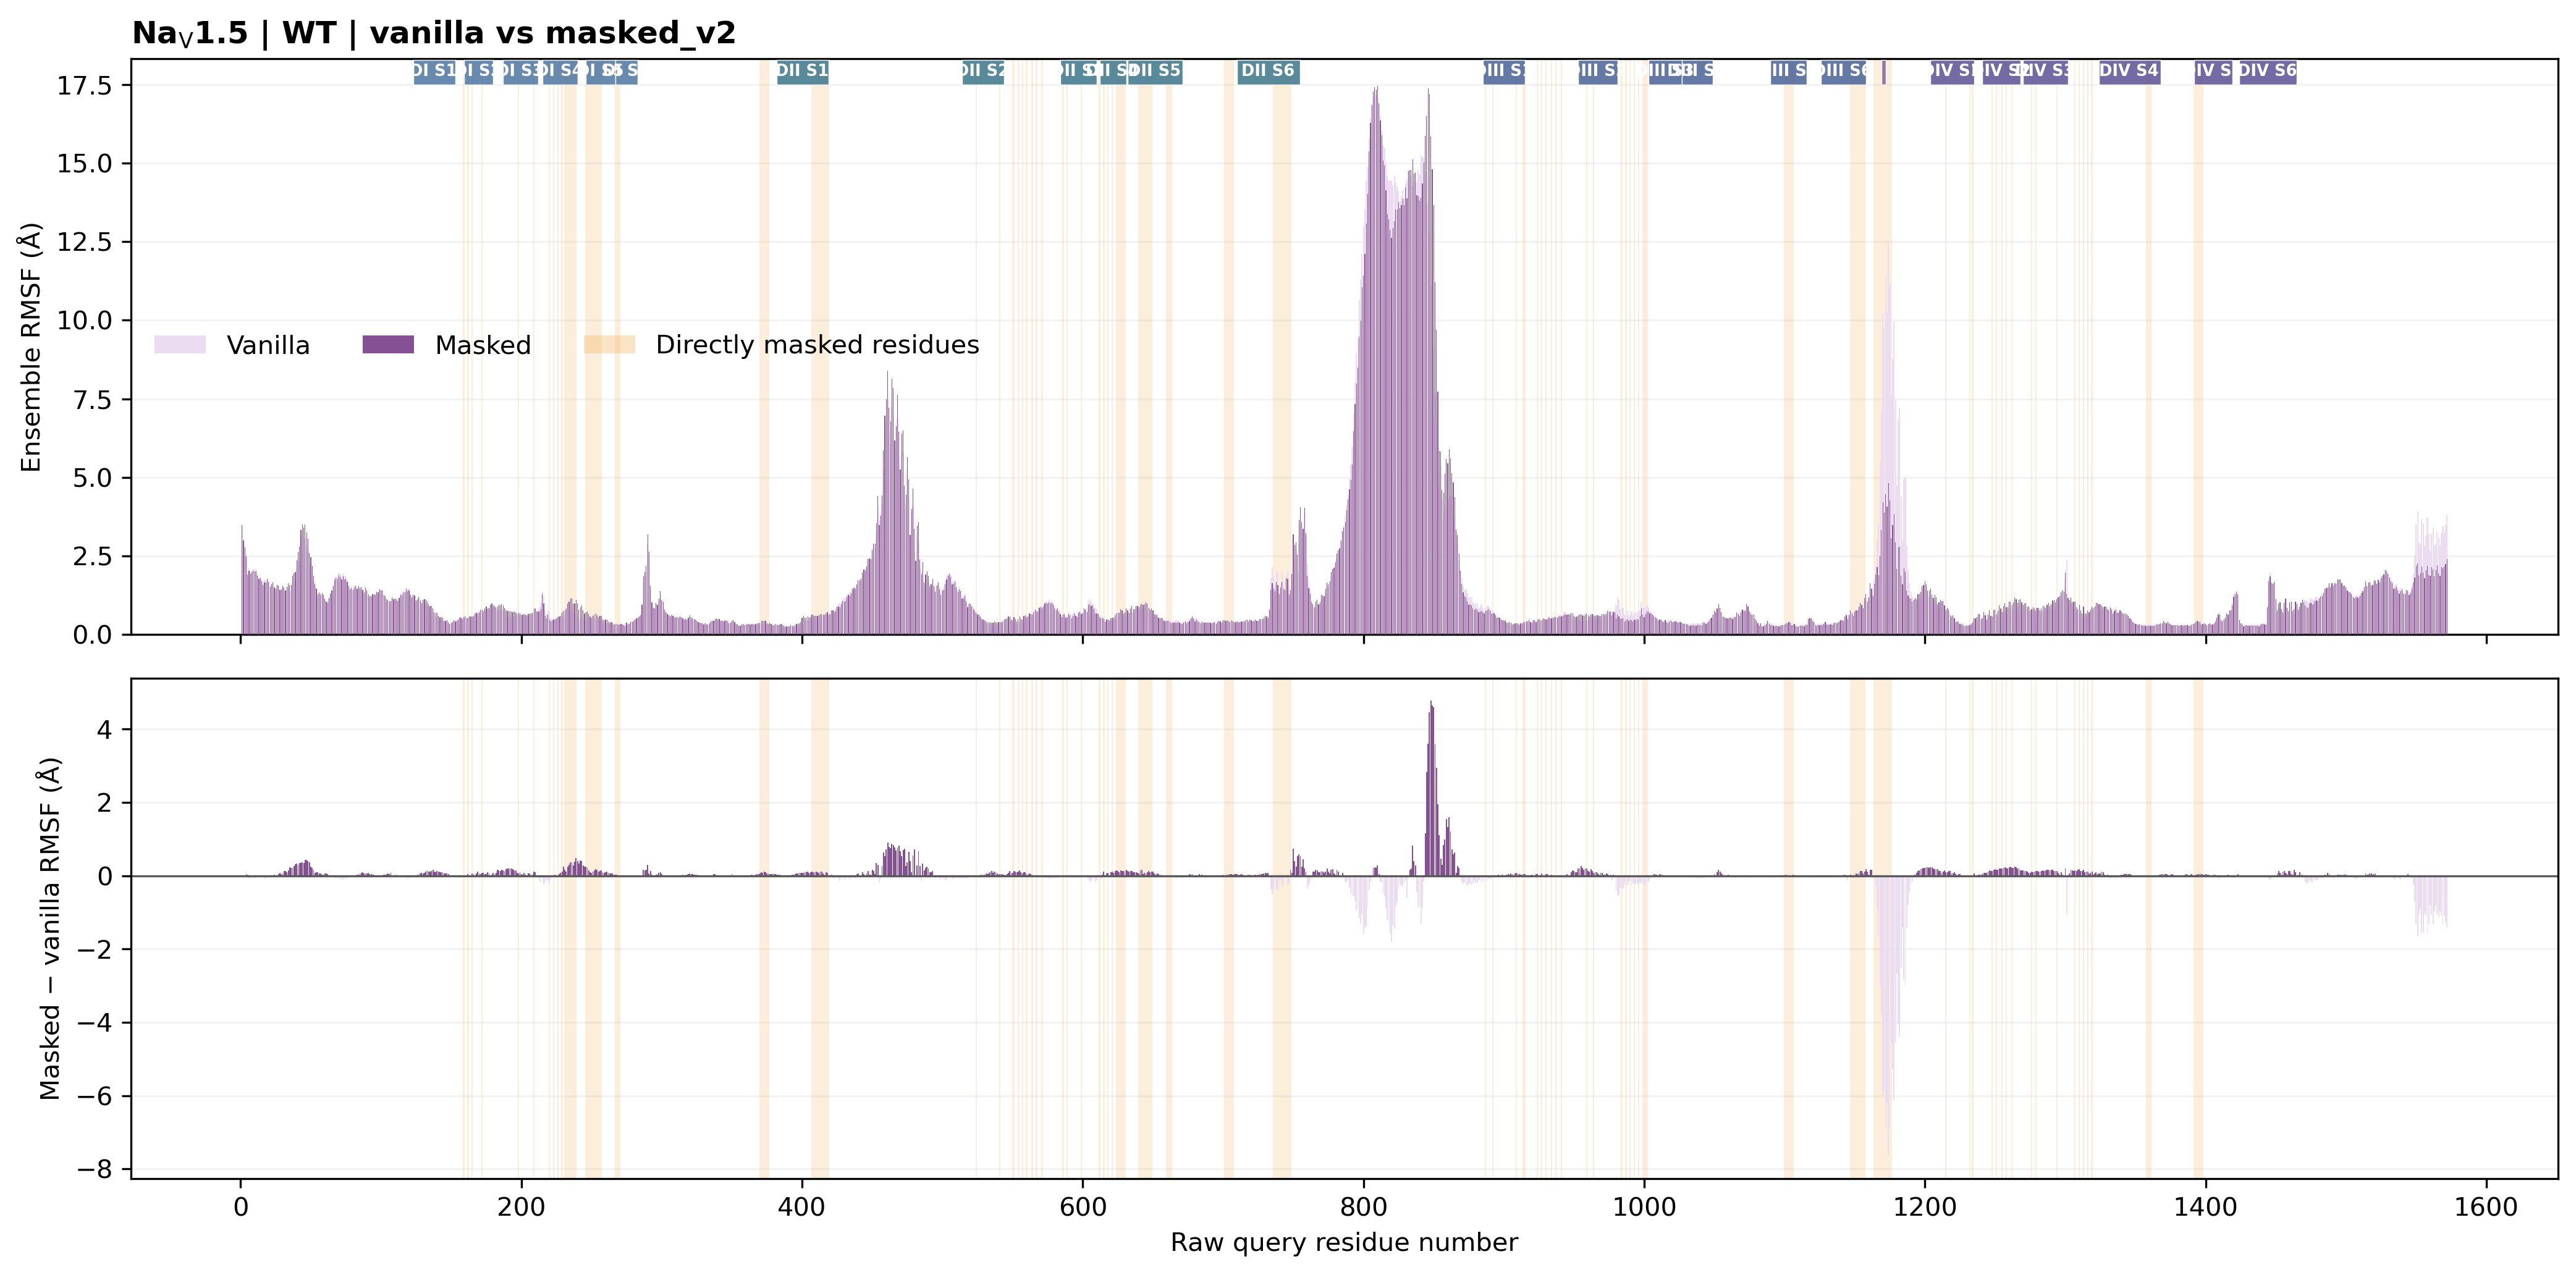

#### Whole-protein residue profile — line and magnitude-fill representation

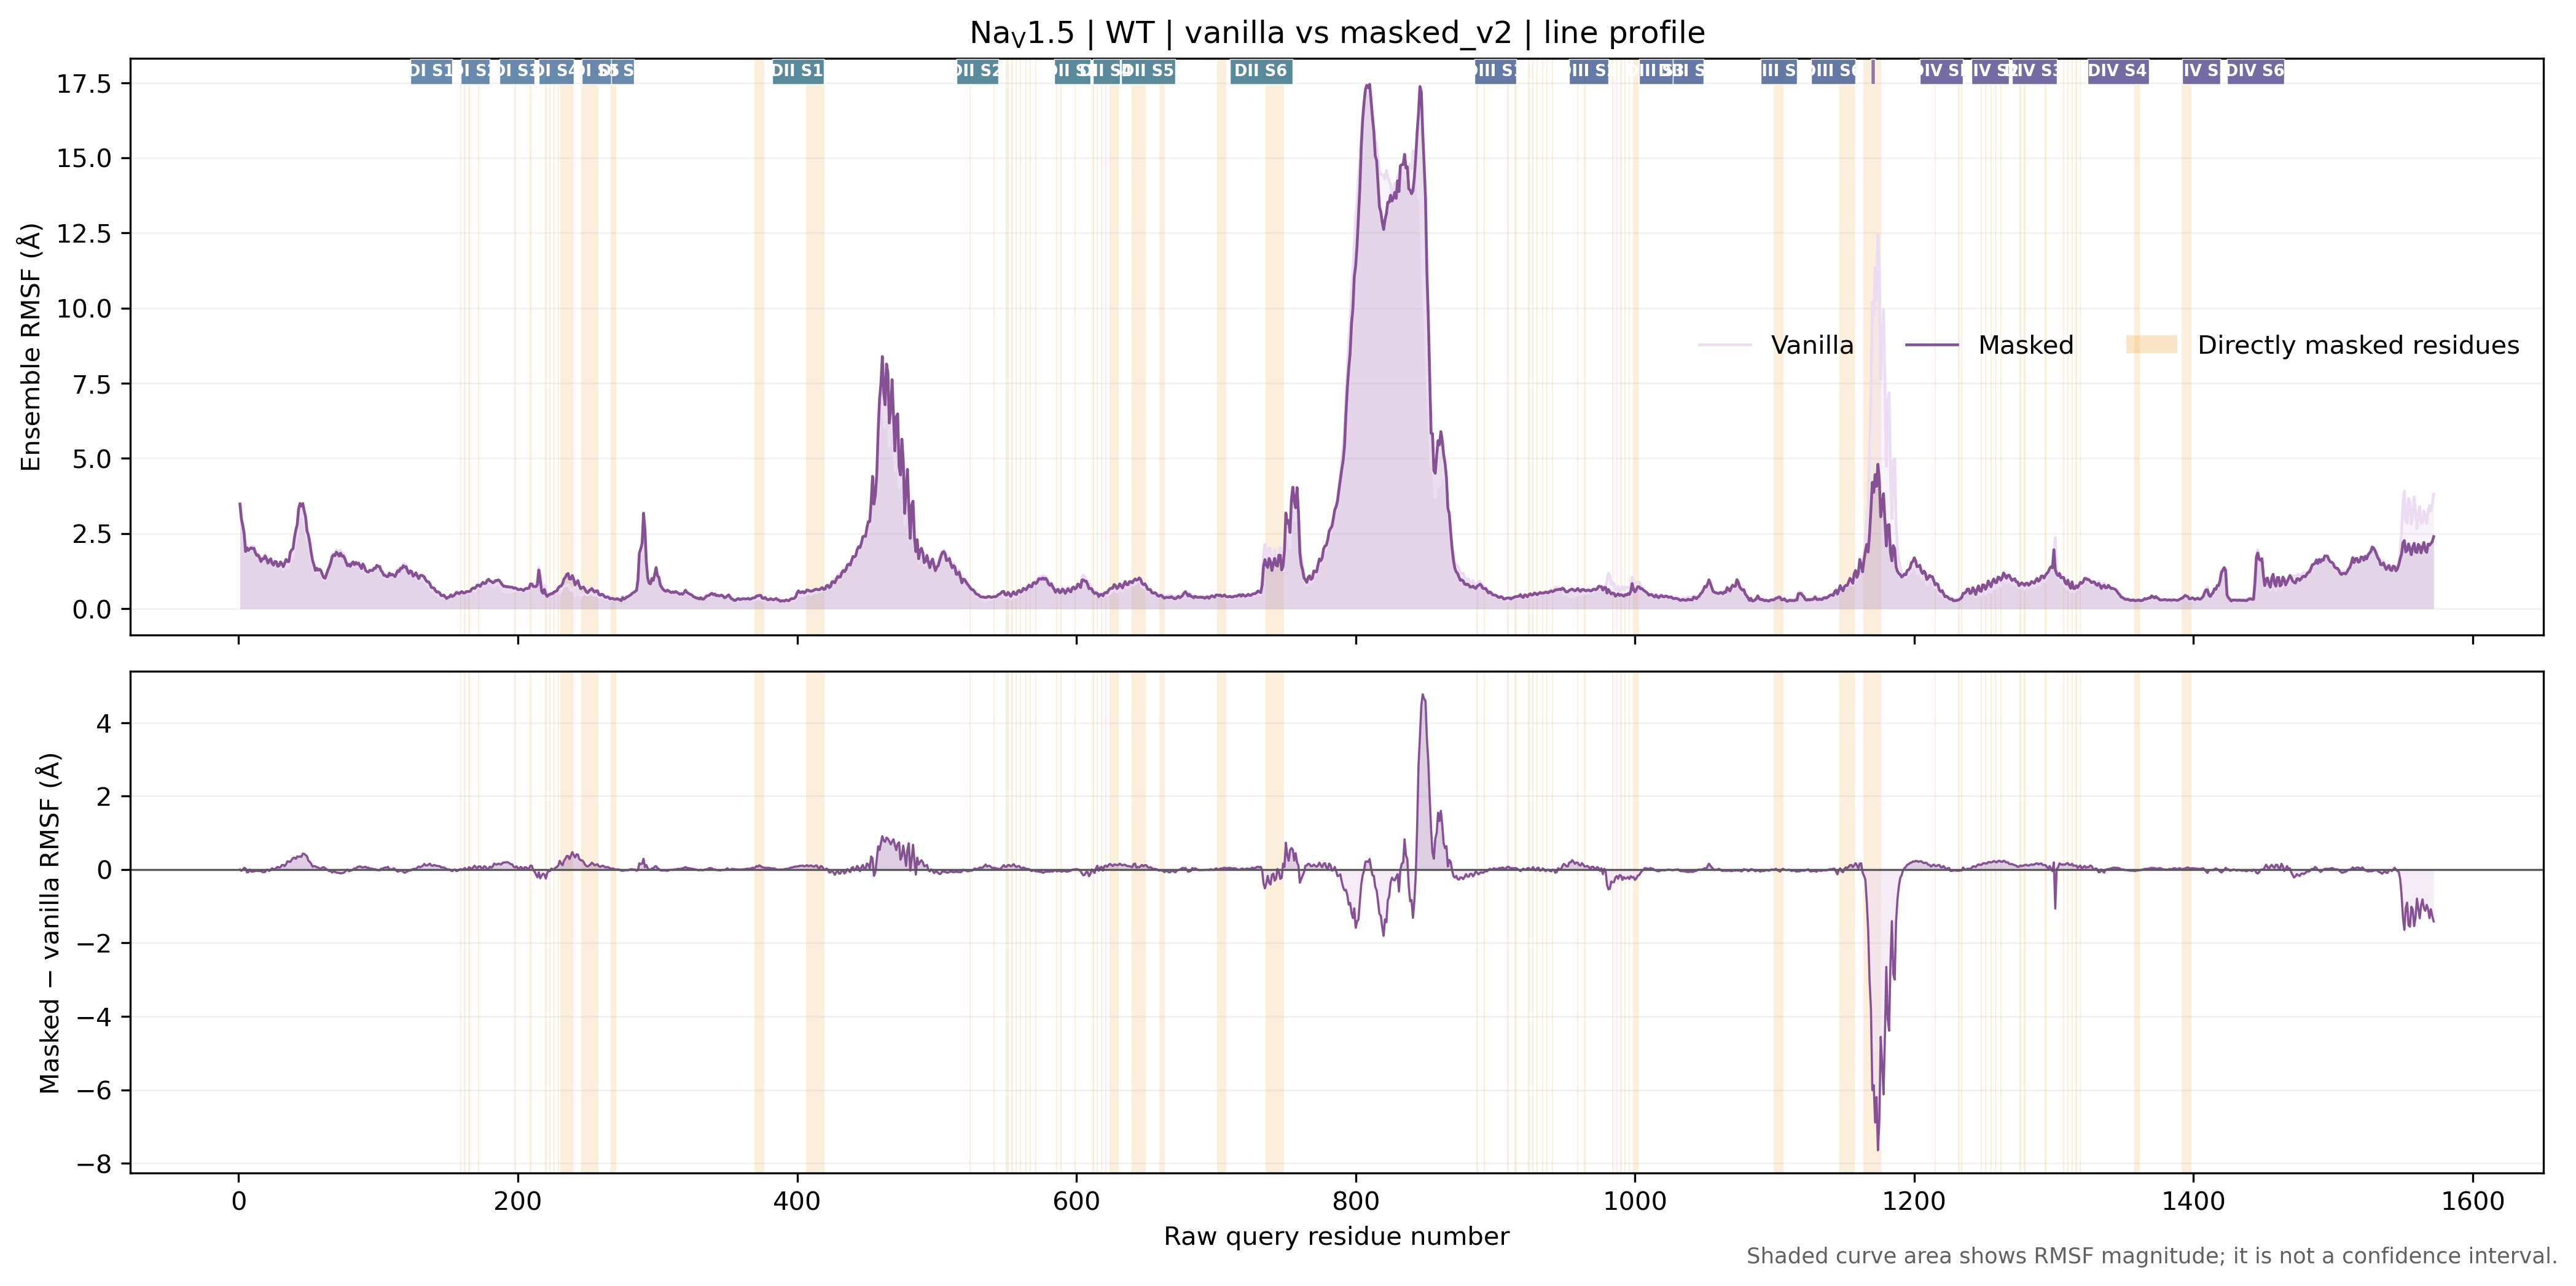

#### Mutation-centered window: raw residues 1140–1200

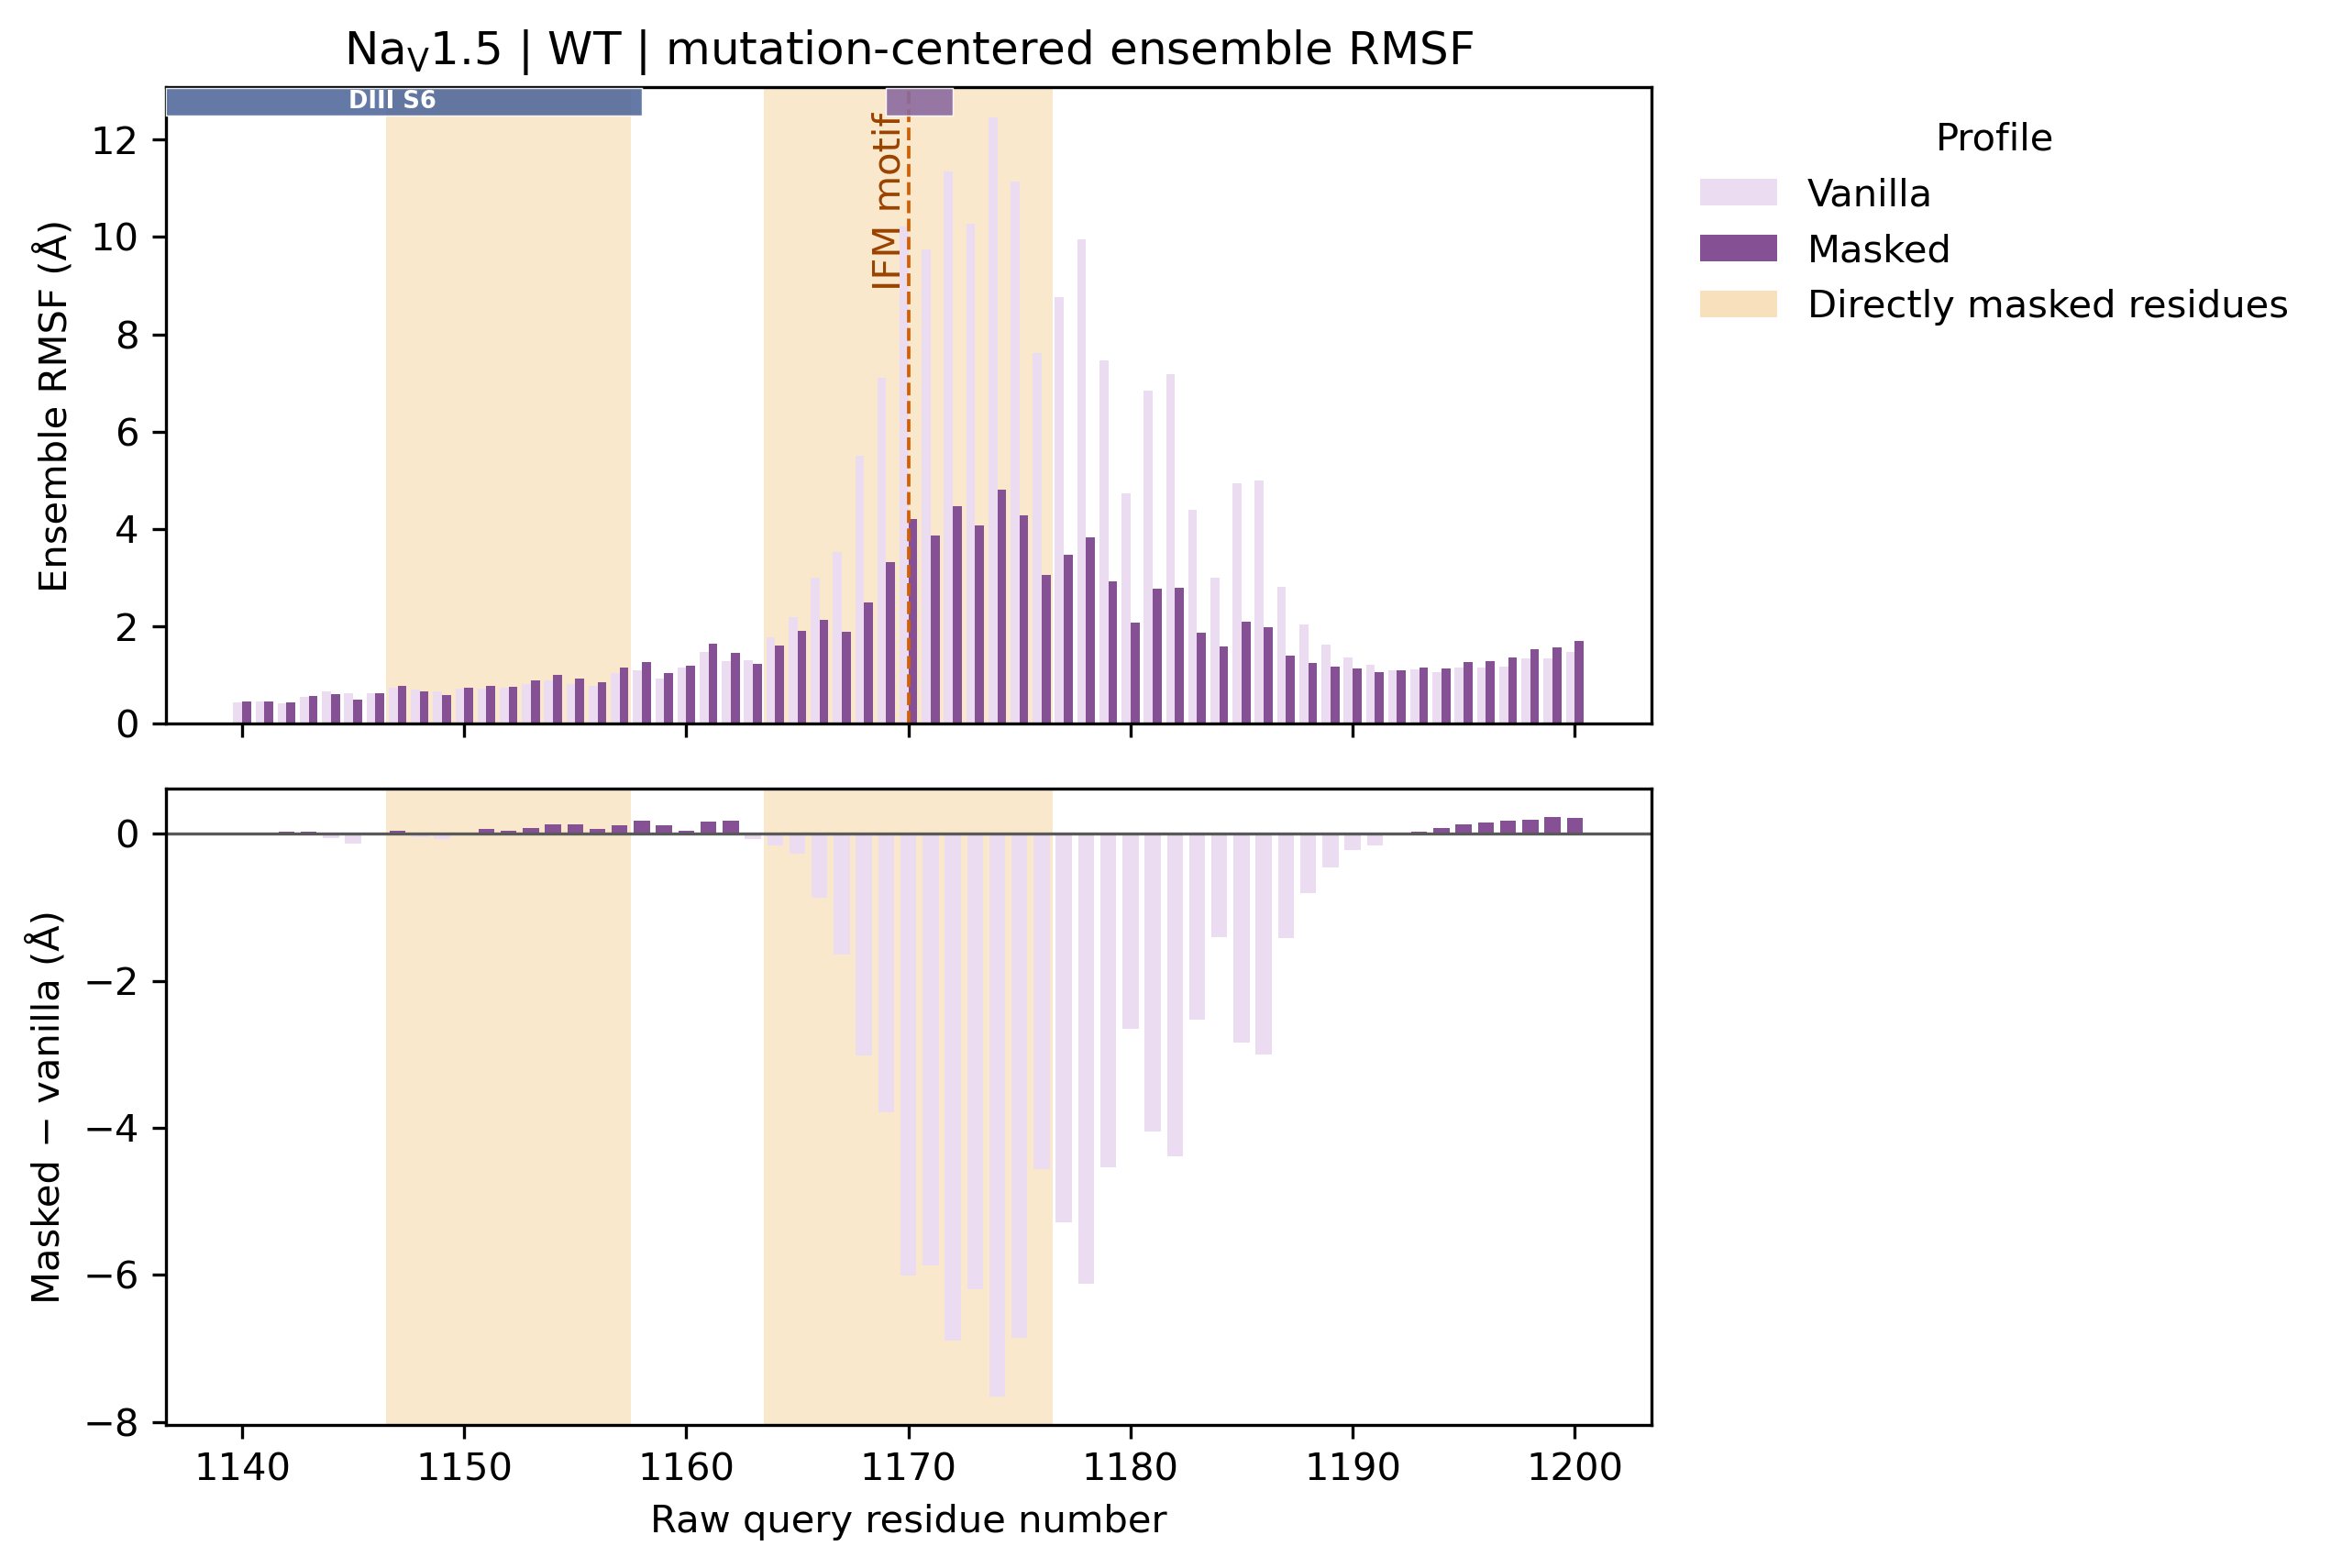

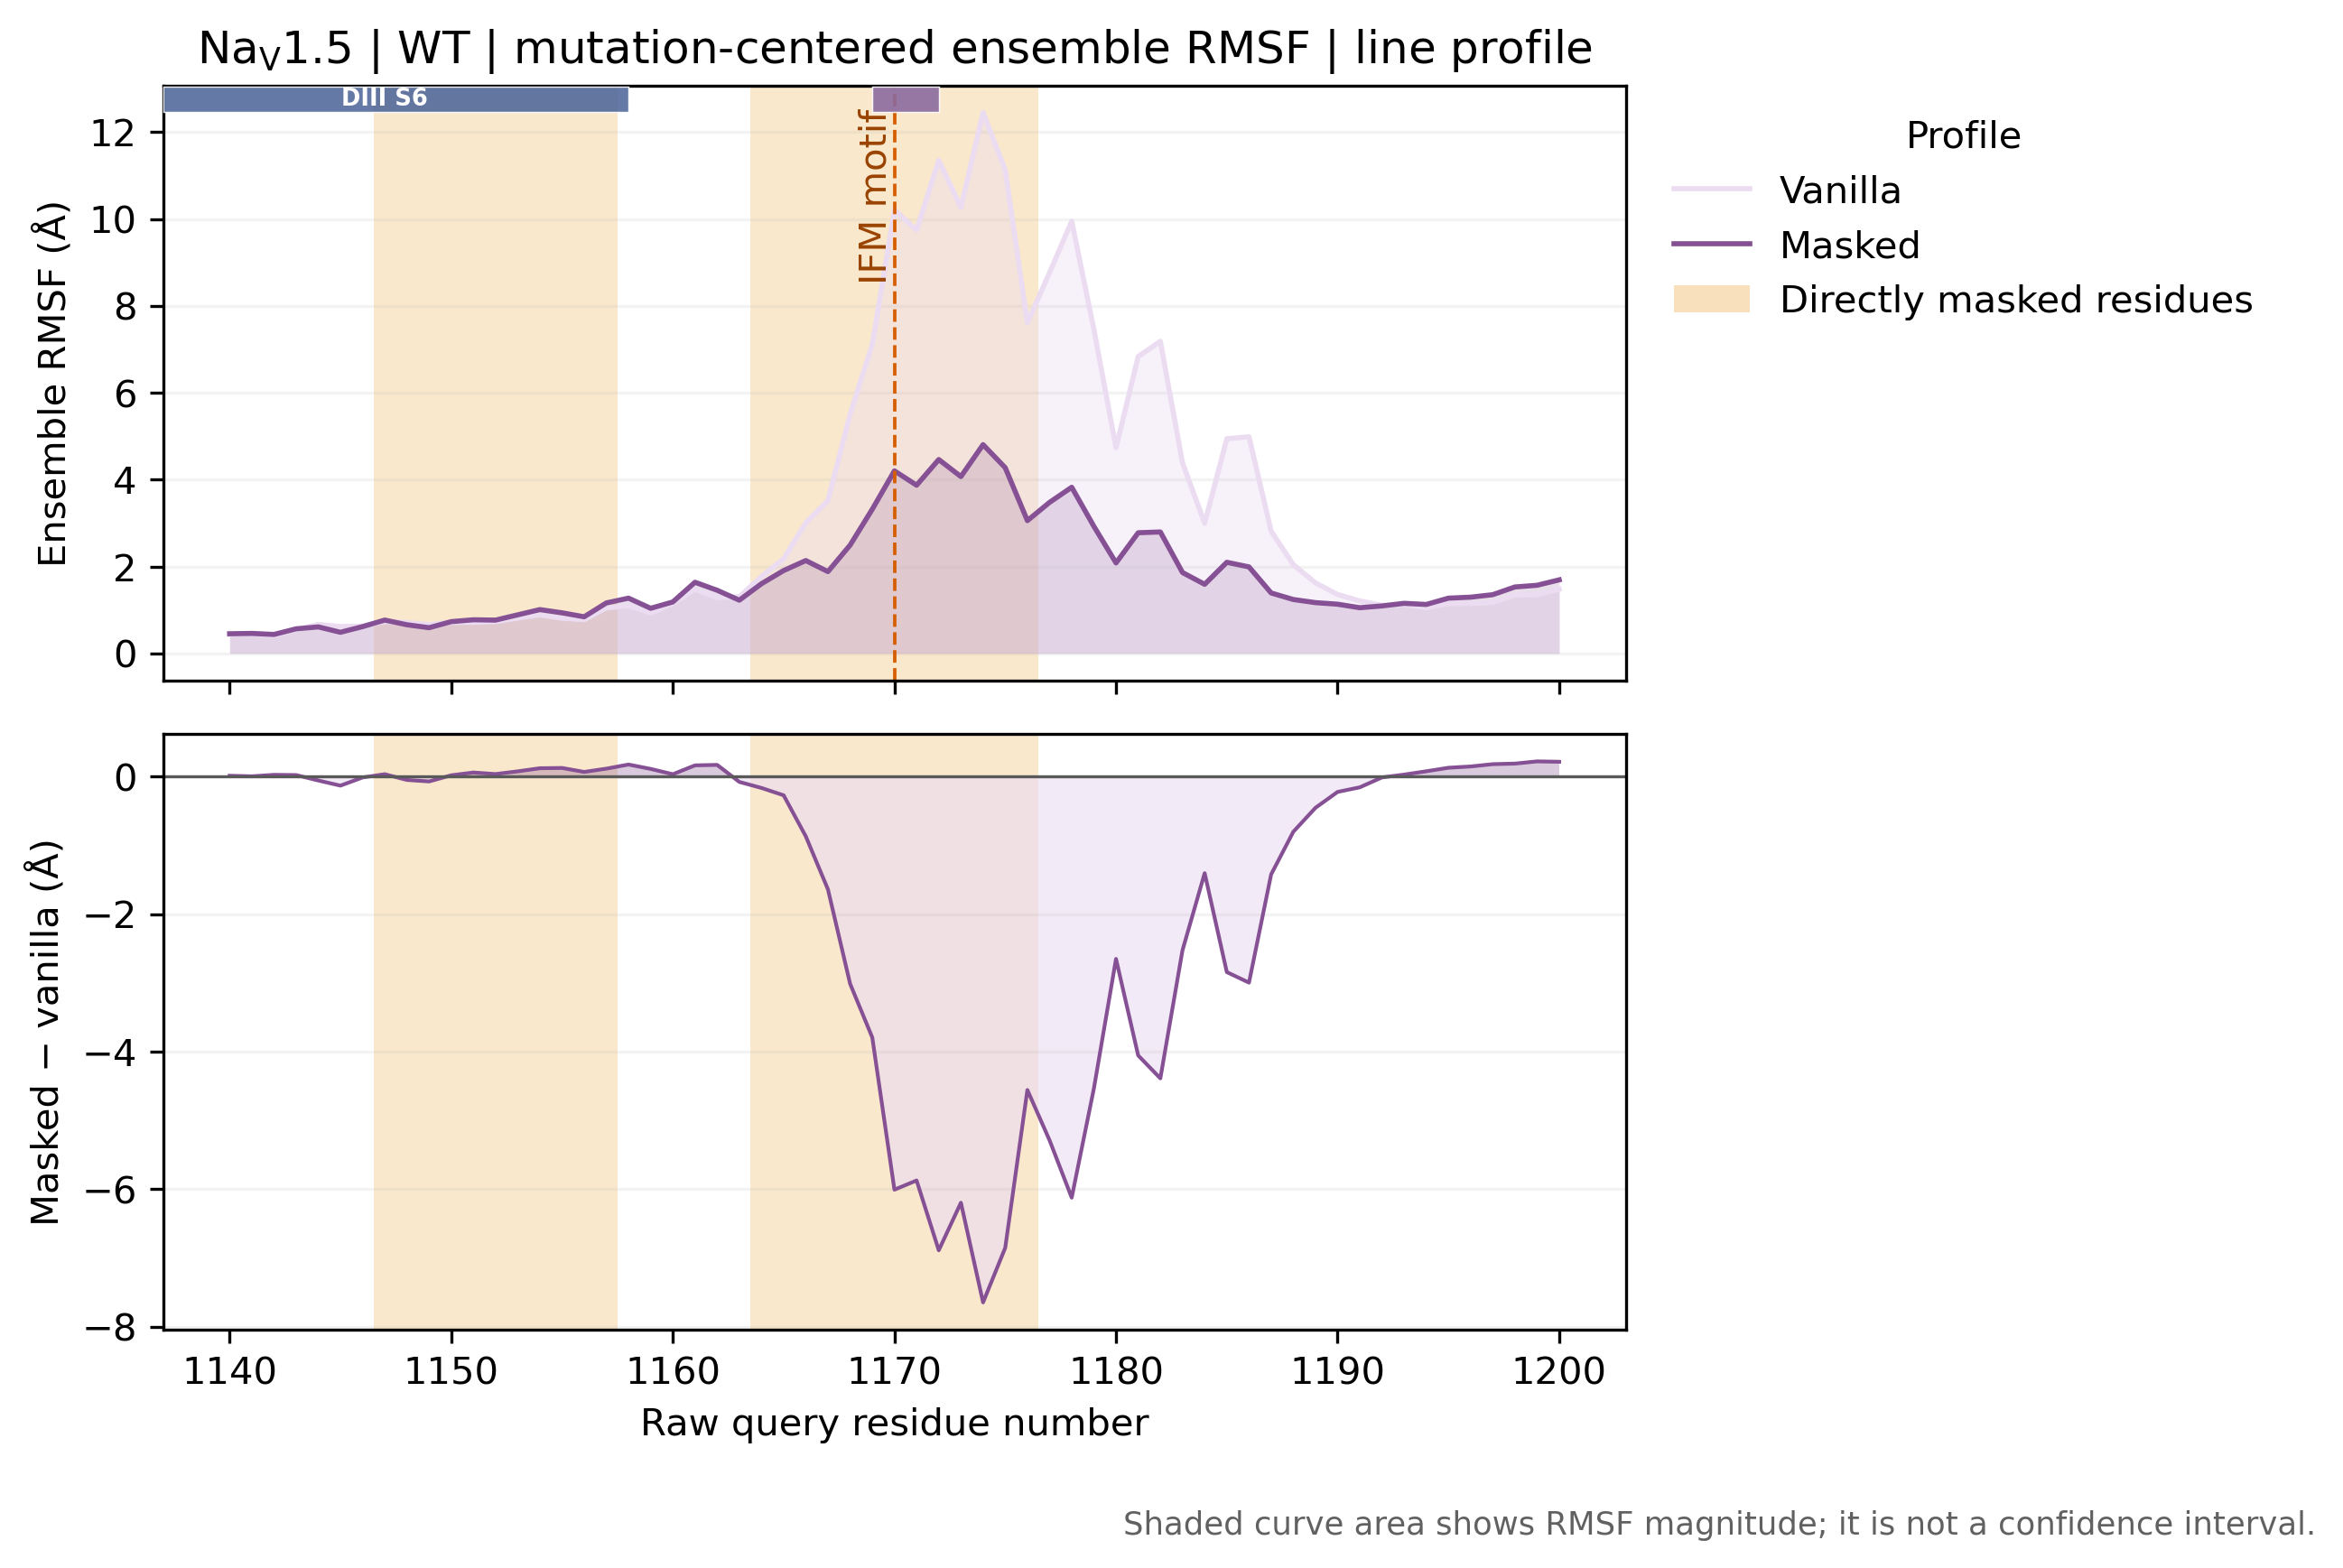

### WT: vanilla versus masked v2 noIFM

#### Whole-protein residue profile — bar representation

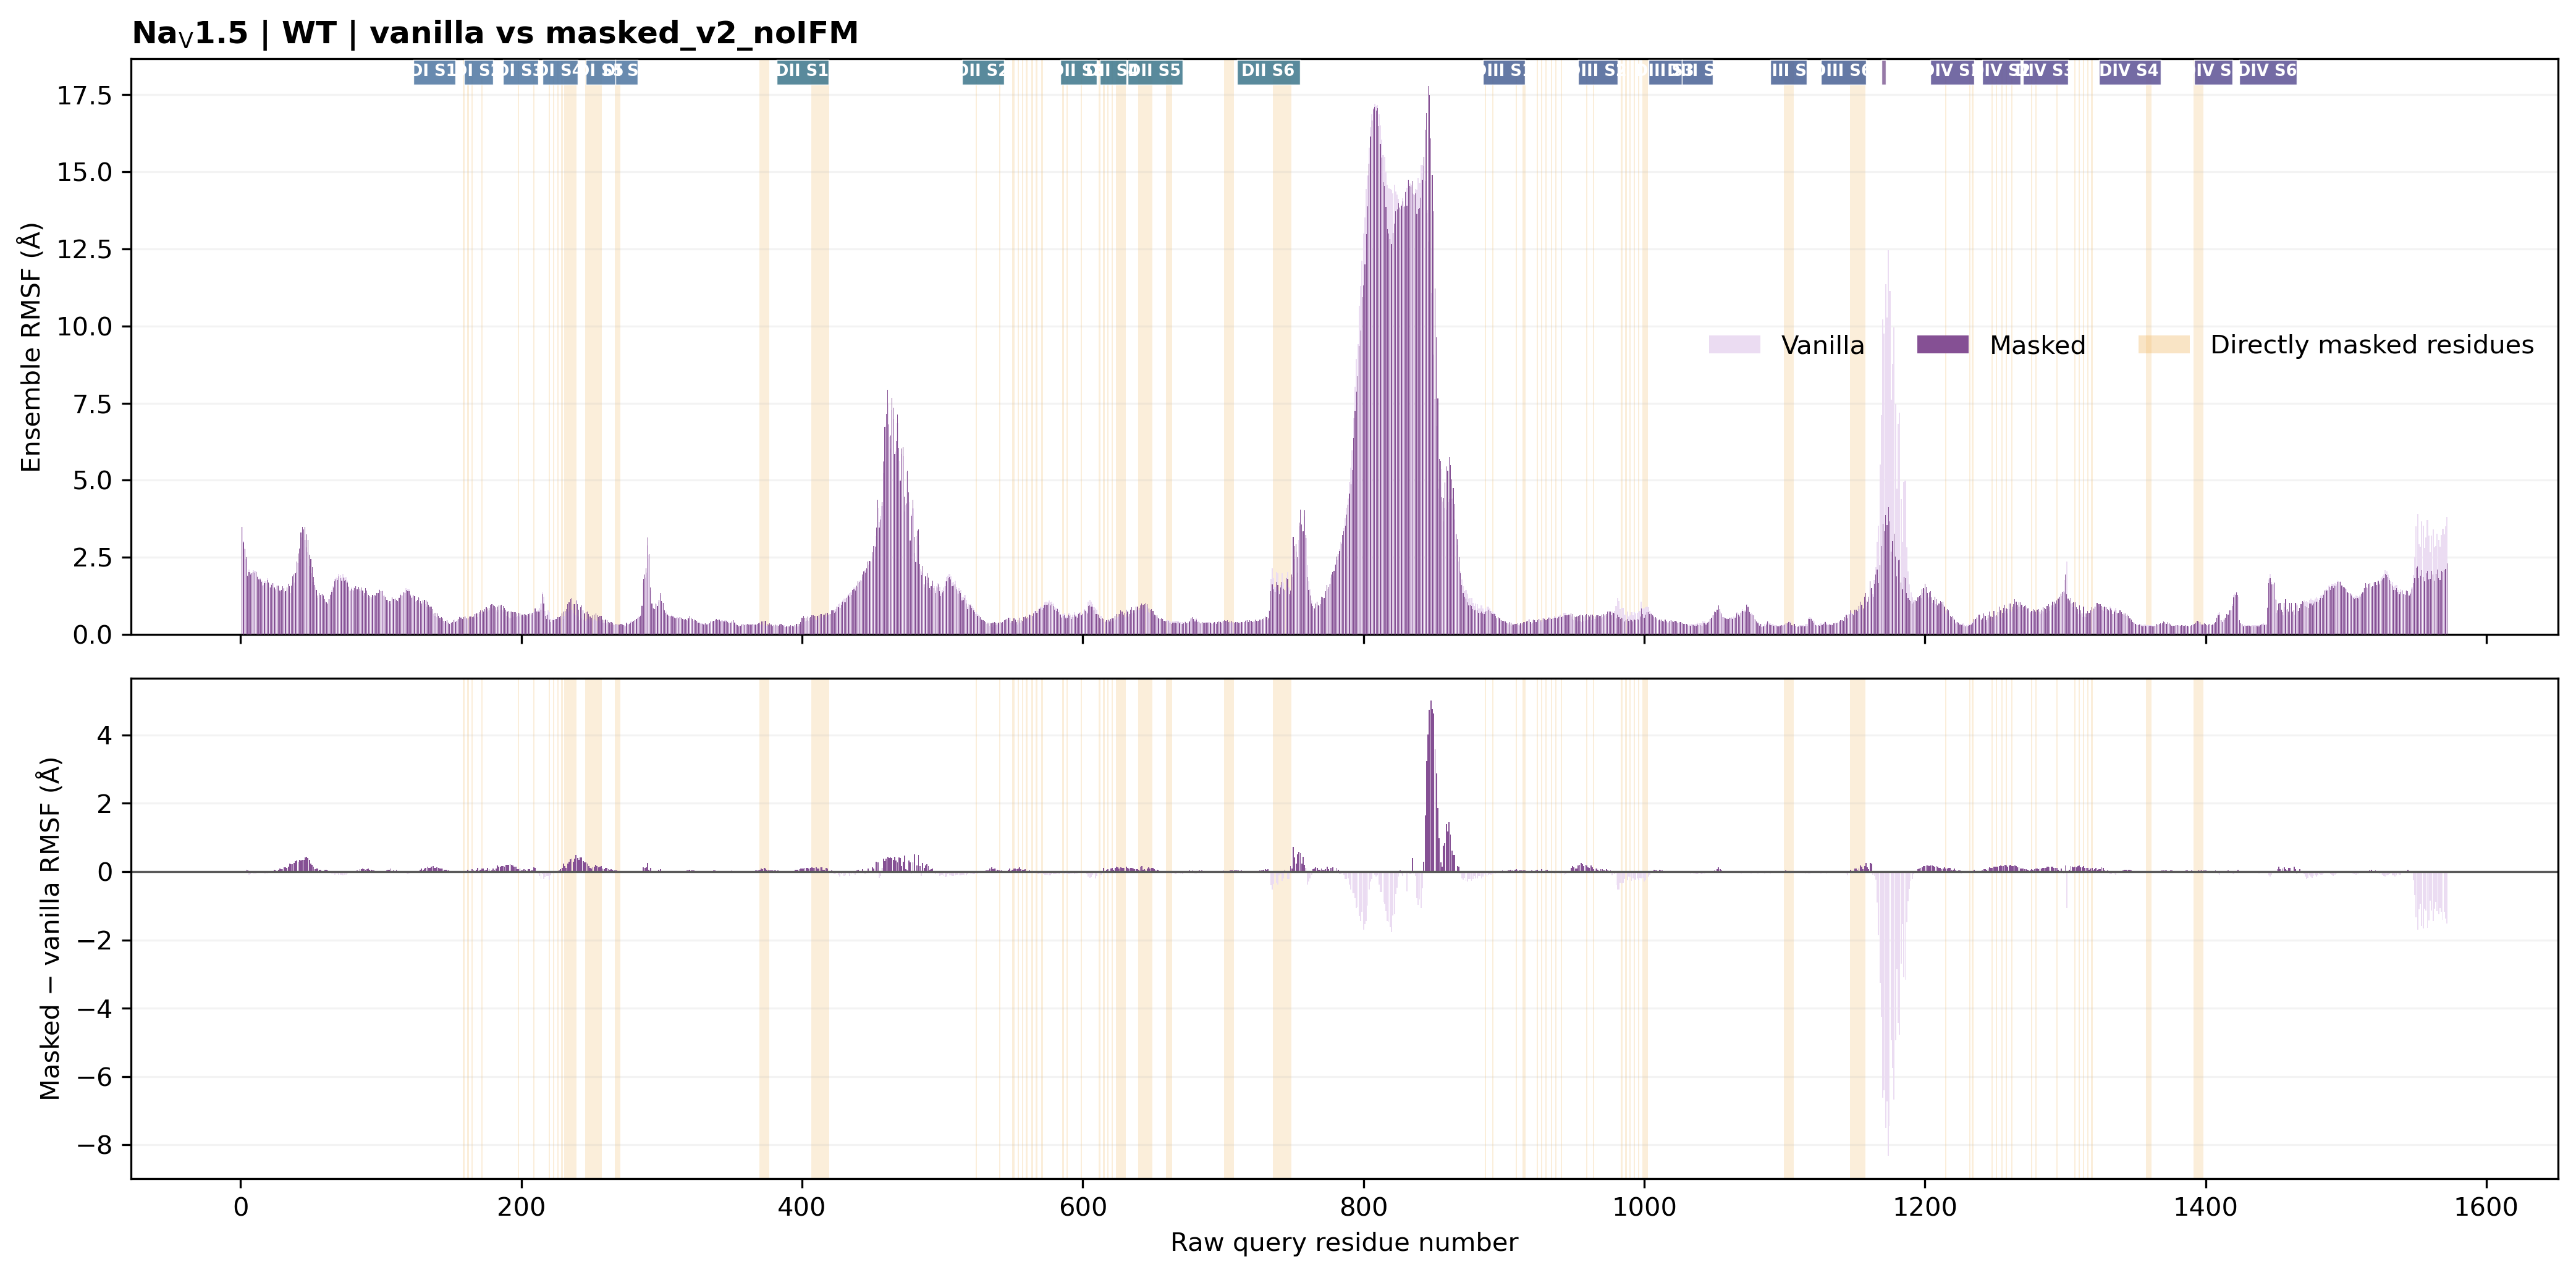

#### Whole-protein residue profile — line and magnitude-fill representation

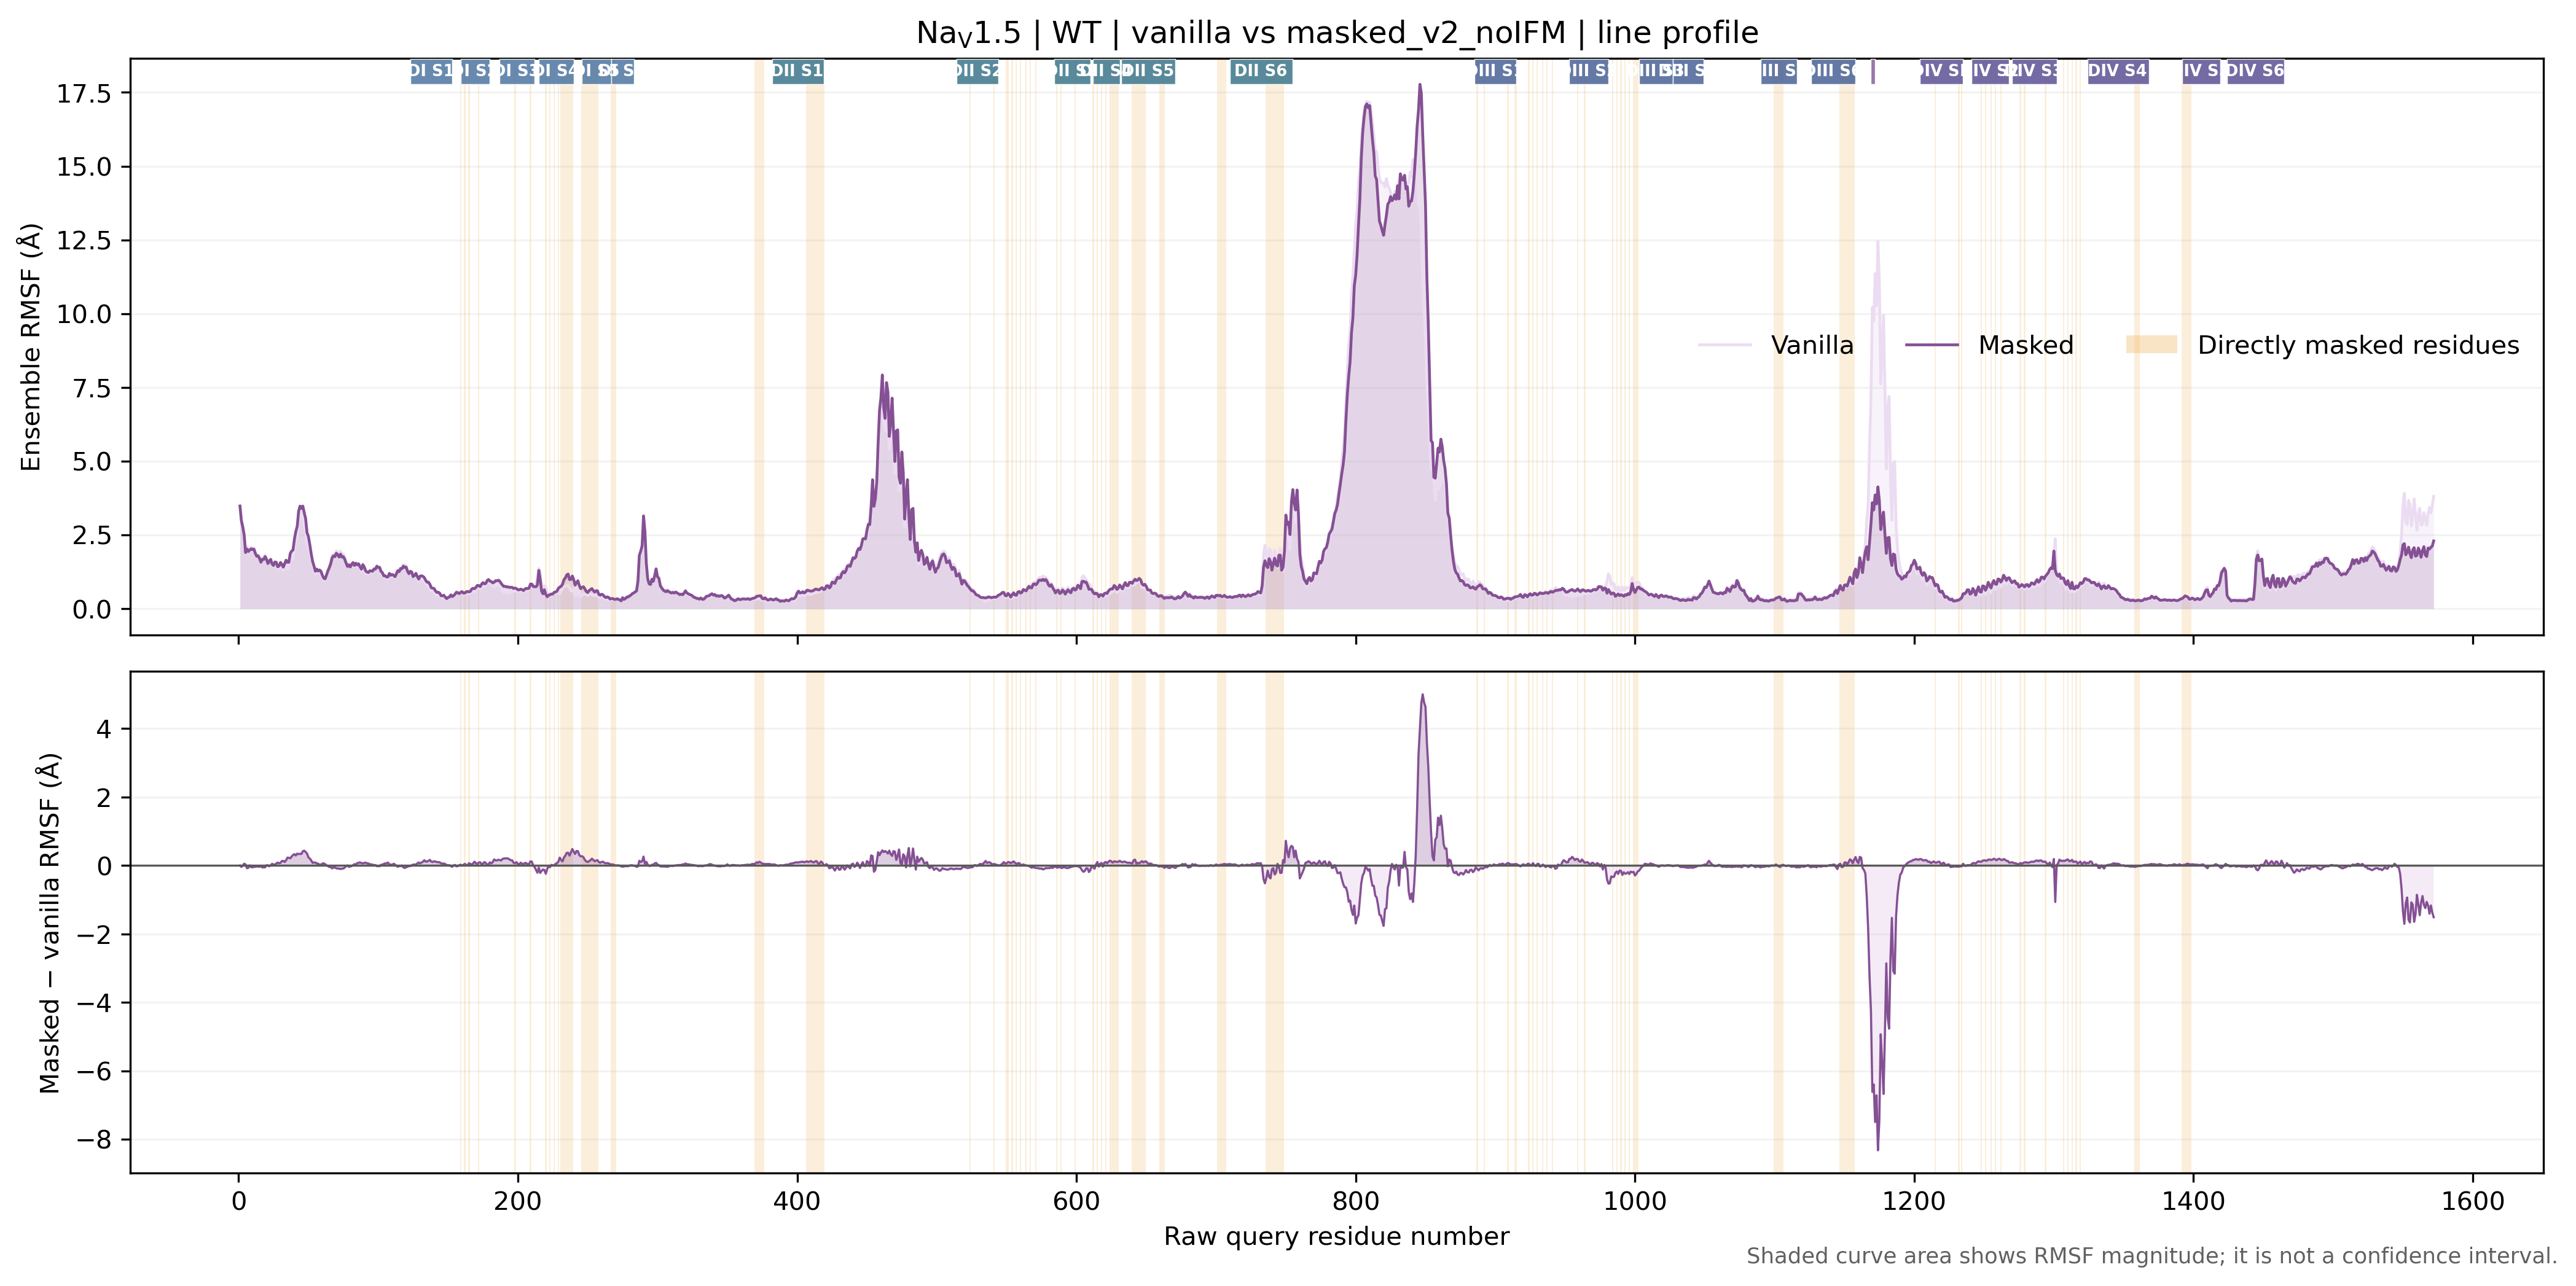

#### Mutation-centered window: raw residues 1140–1200

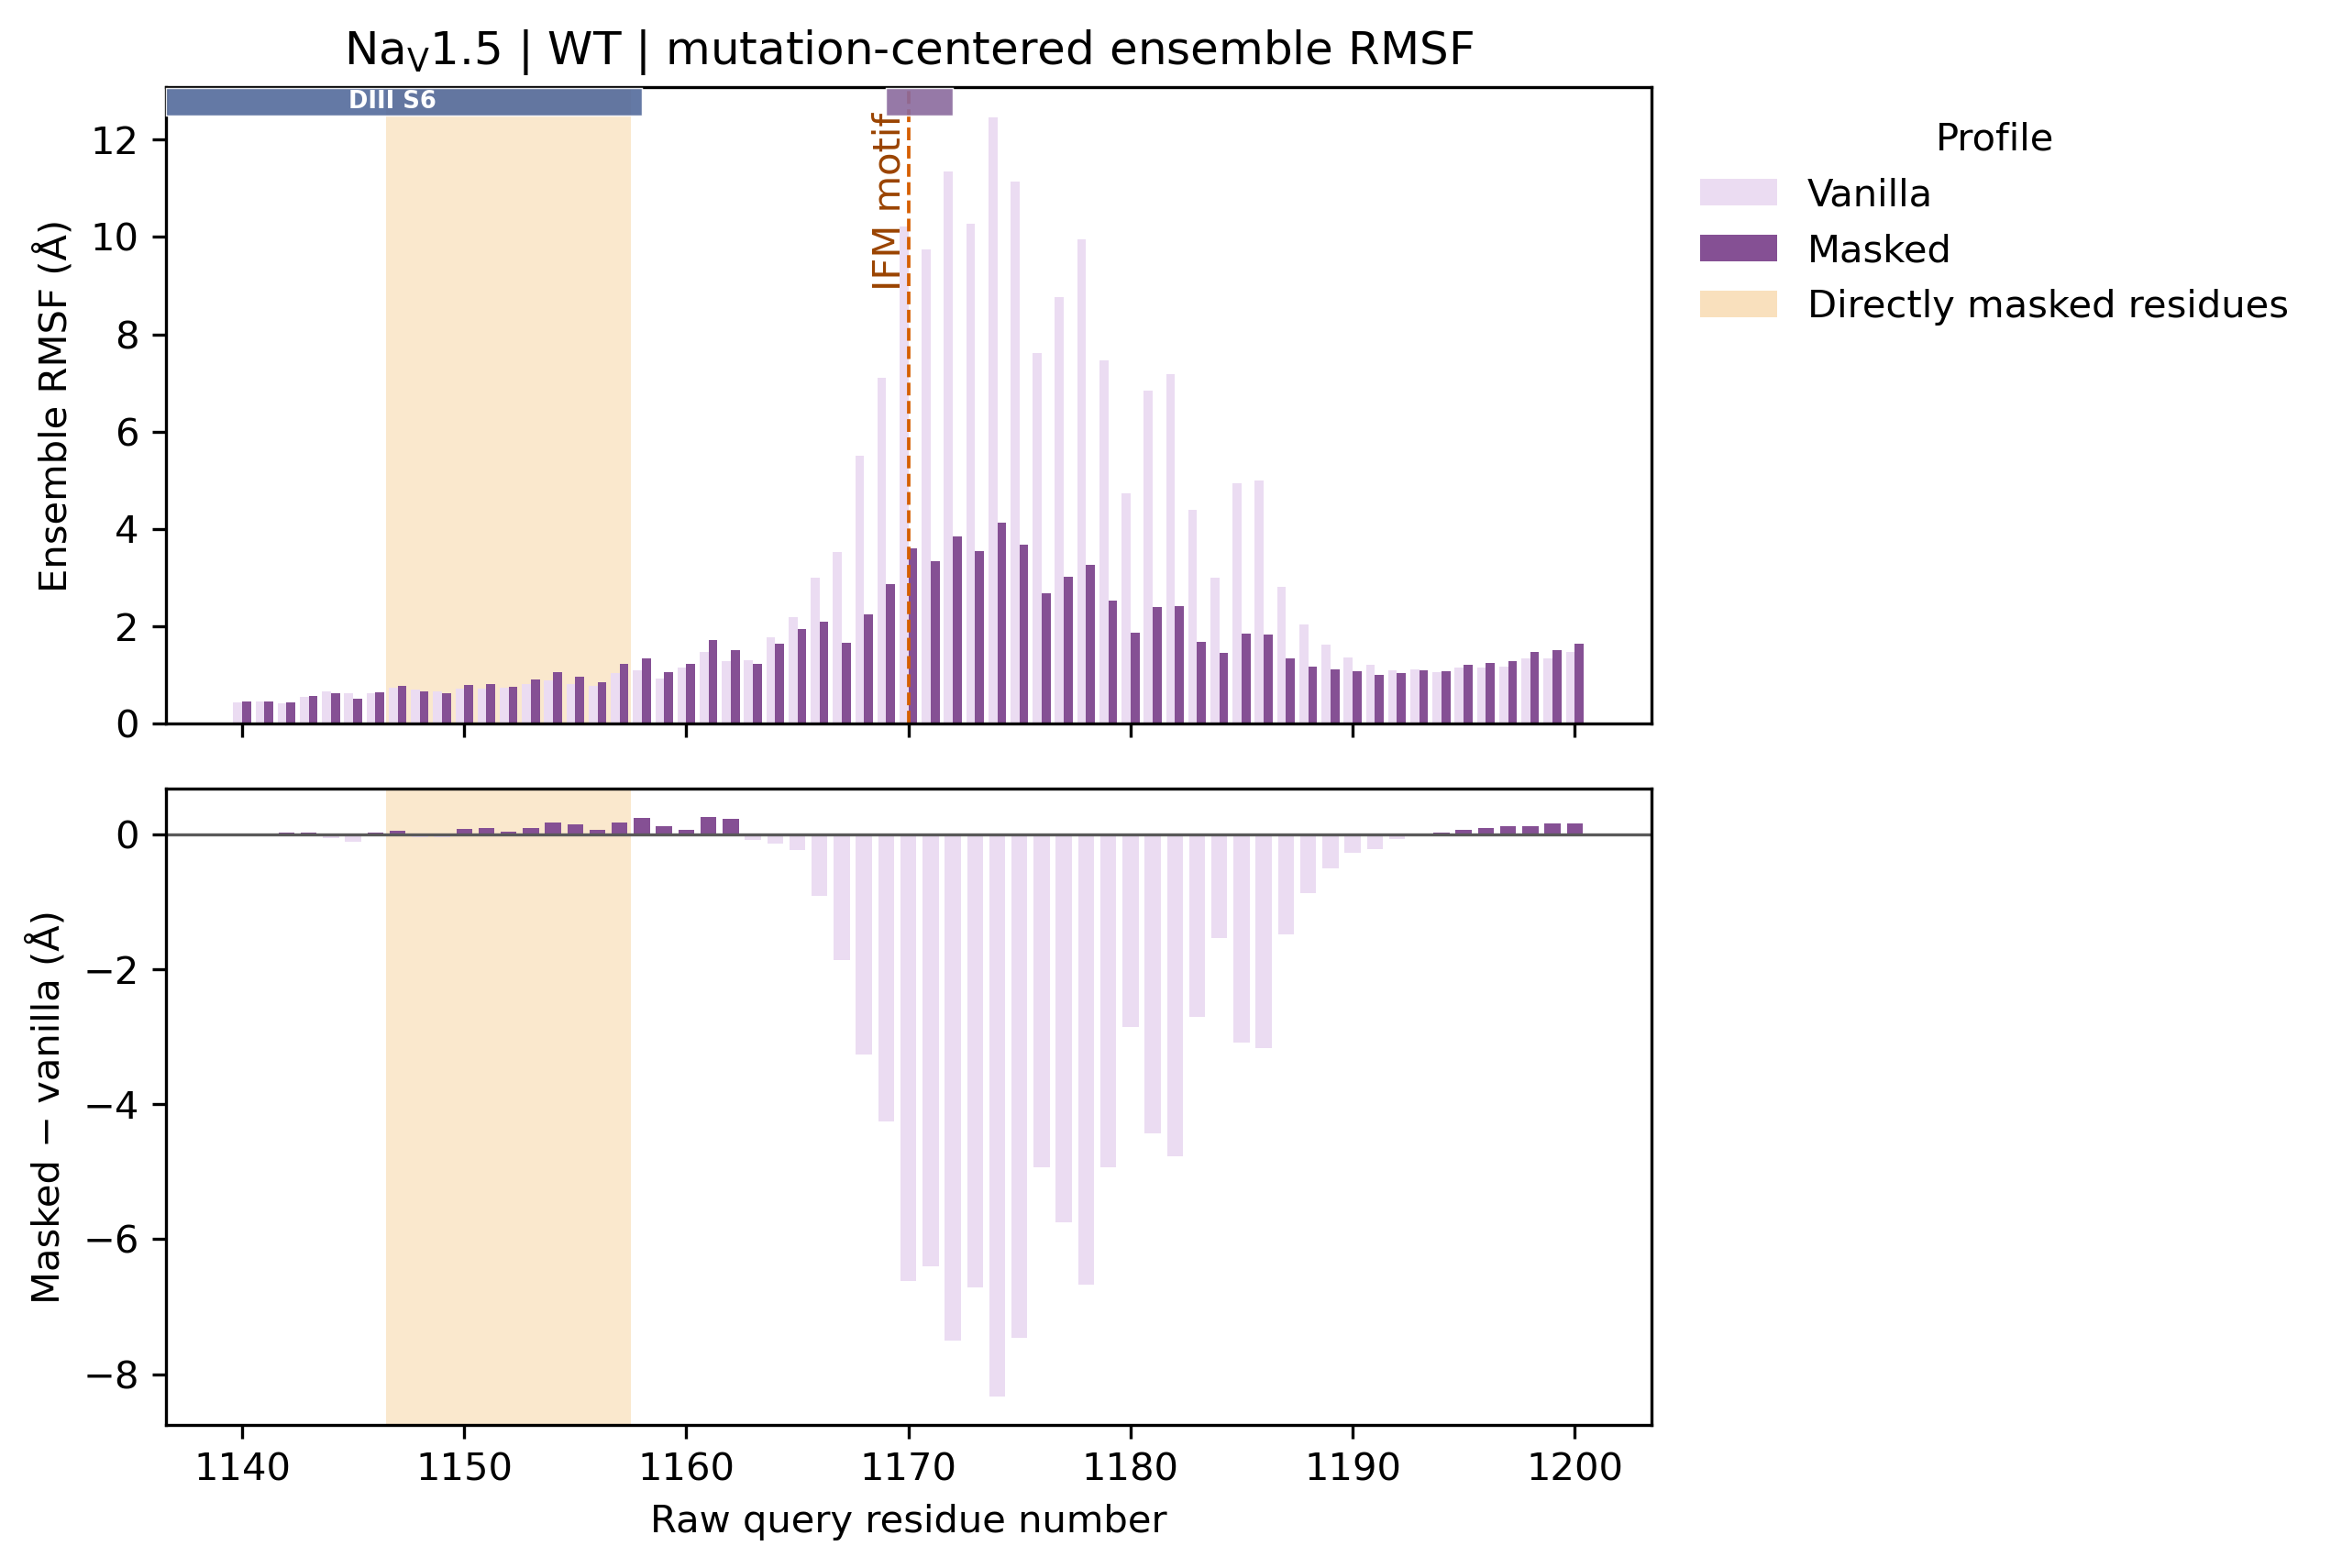

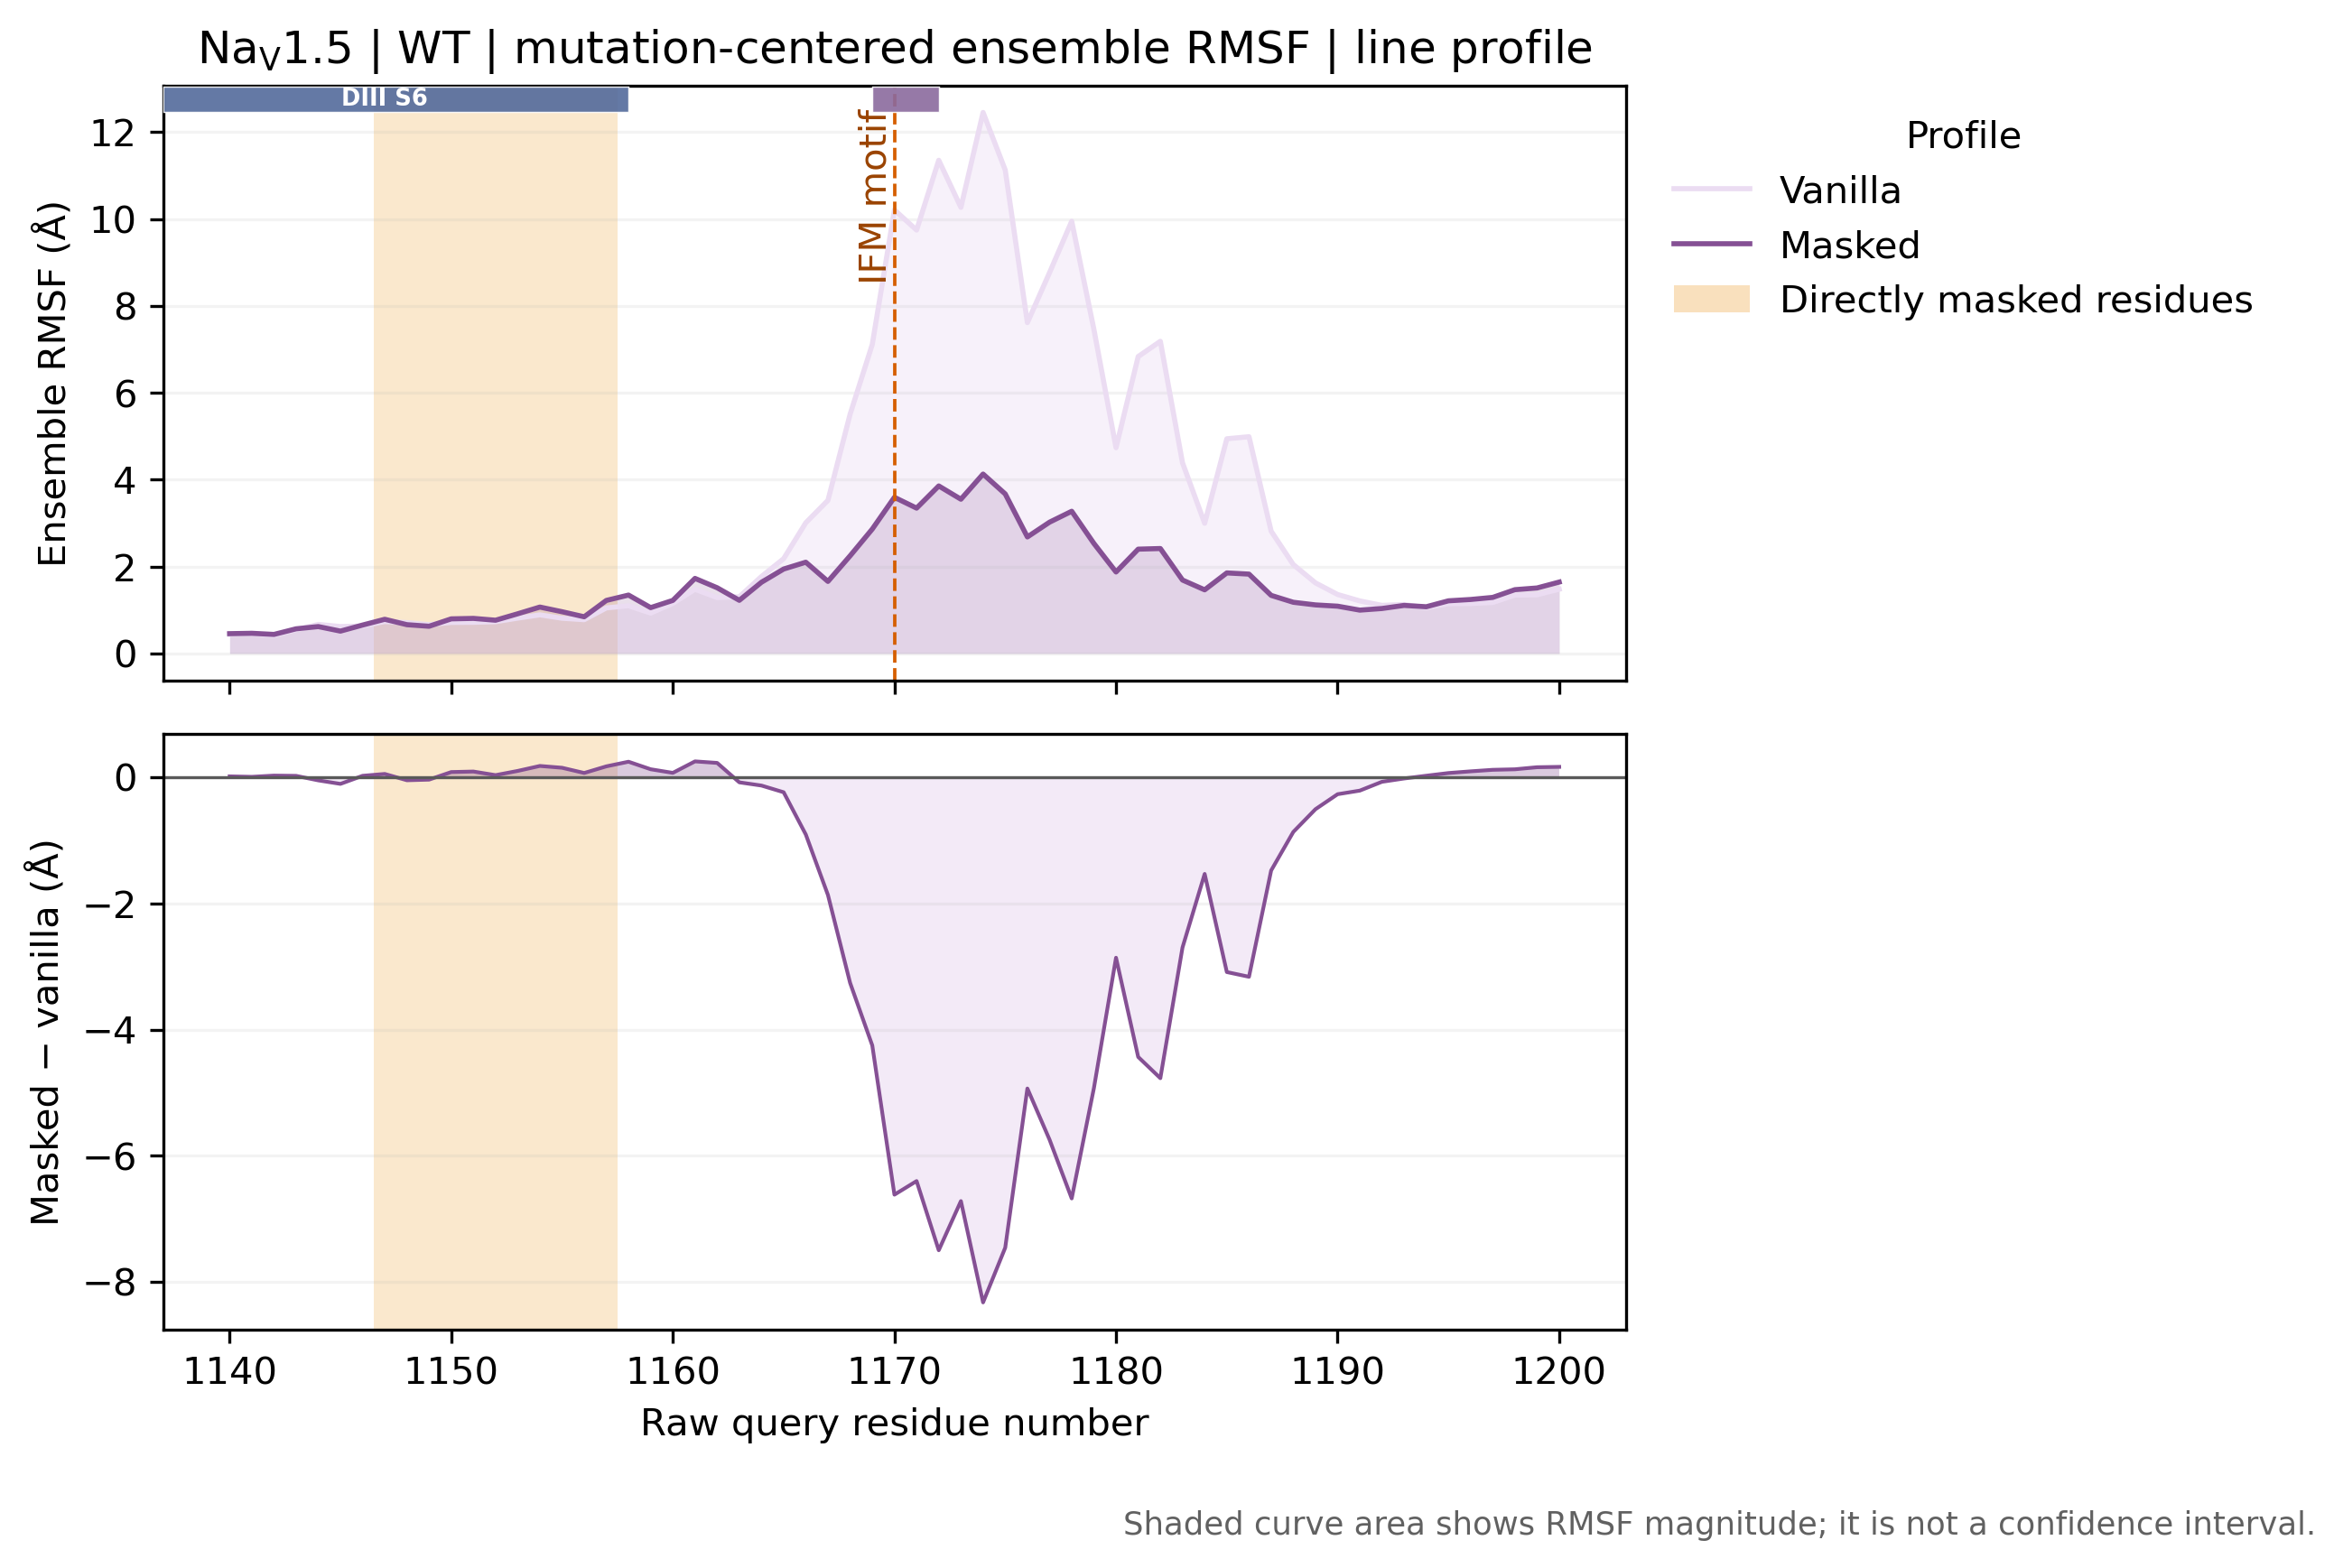

### QQQ: vanilla versus masked

#### Whole-protein residue profile — bar representation

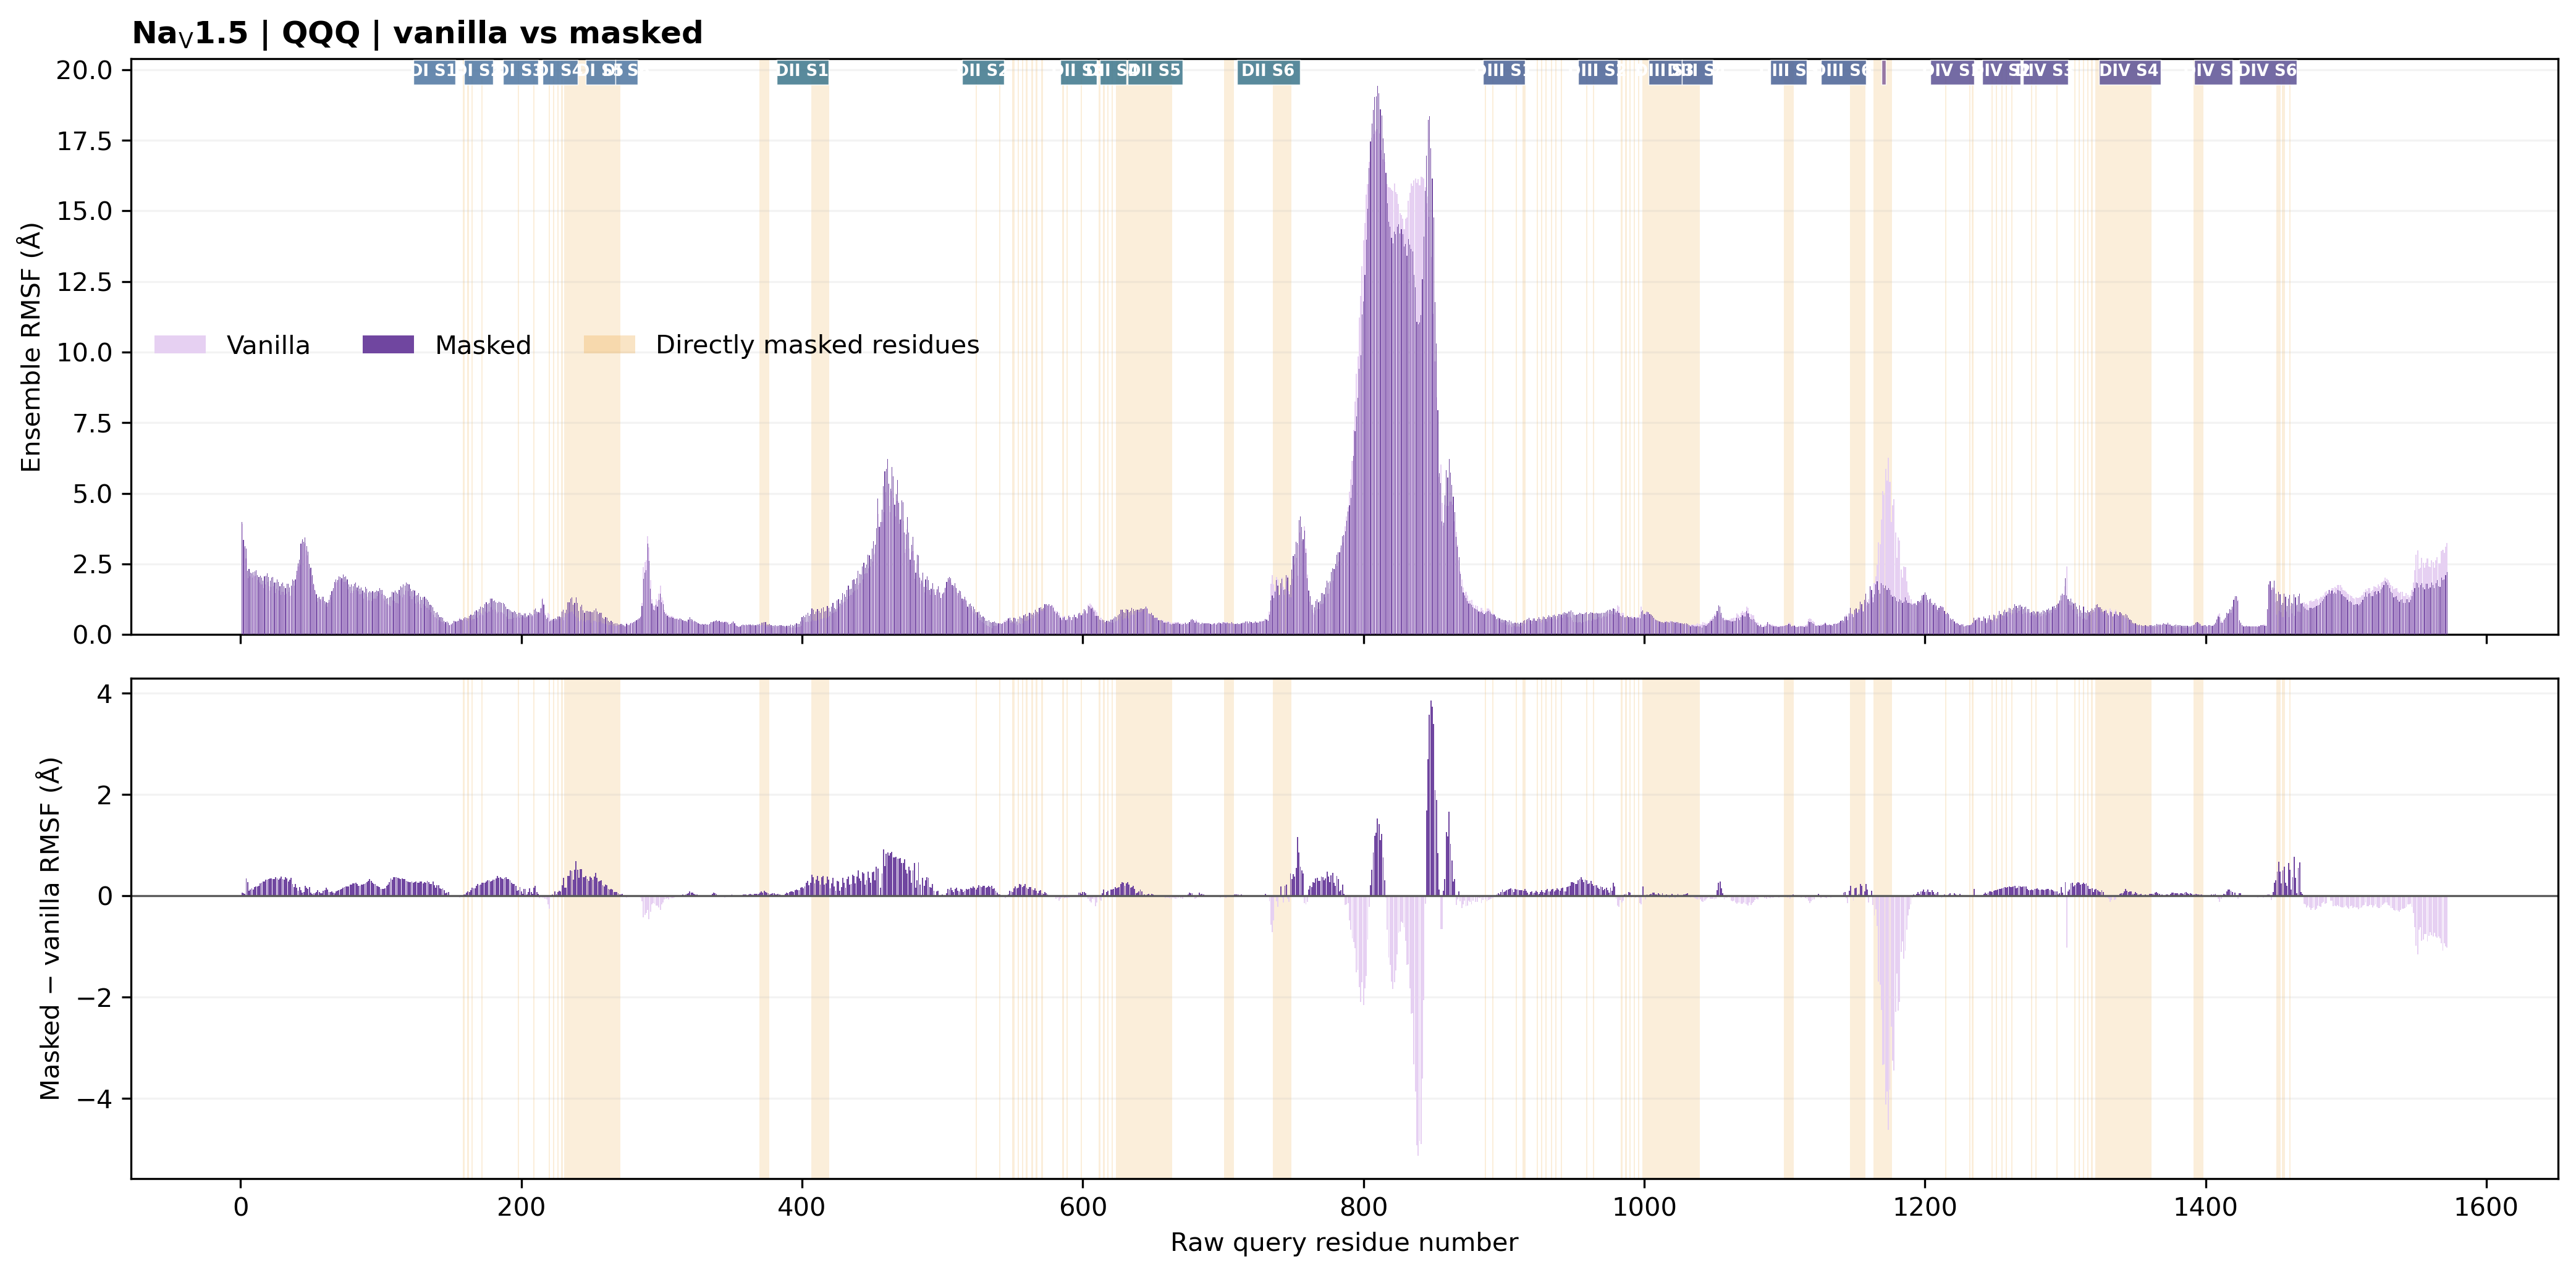

#### Whole-protein residue profile — line and magnitude-fill representation

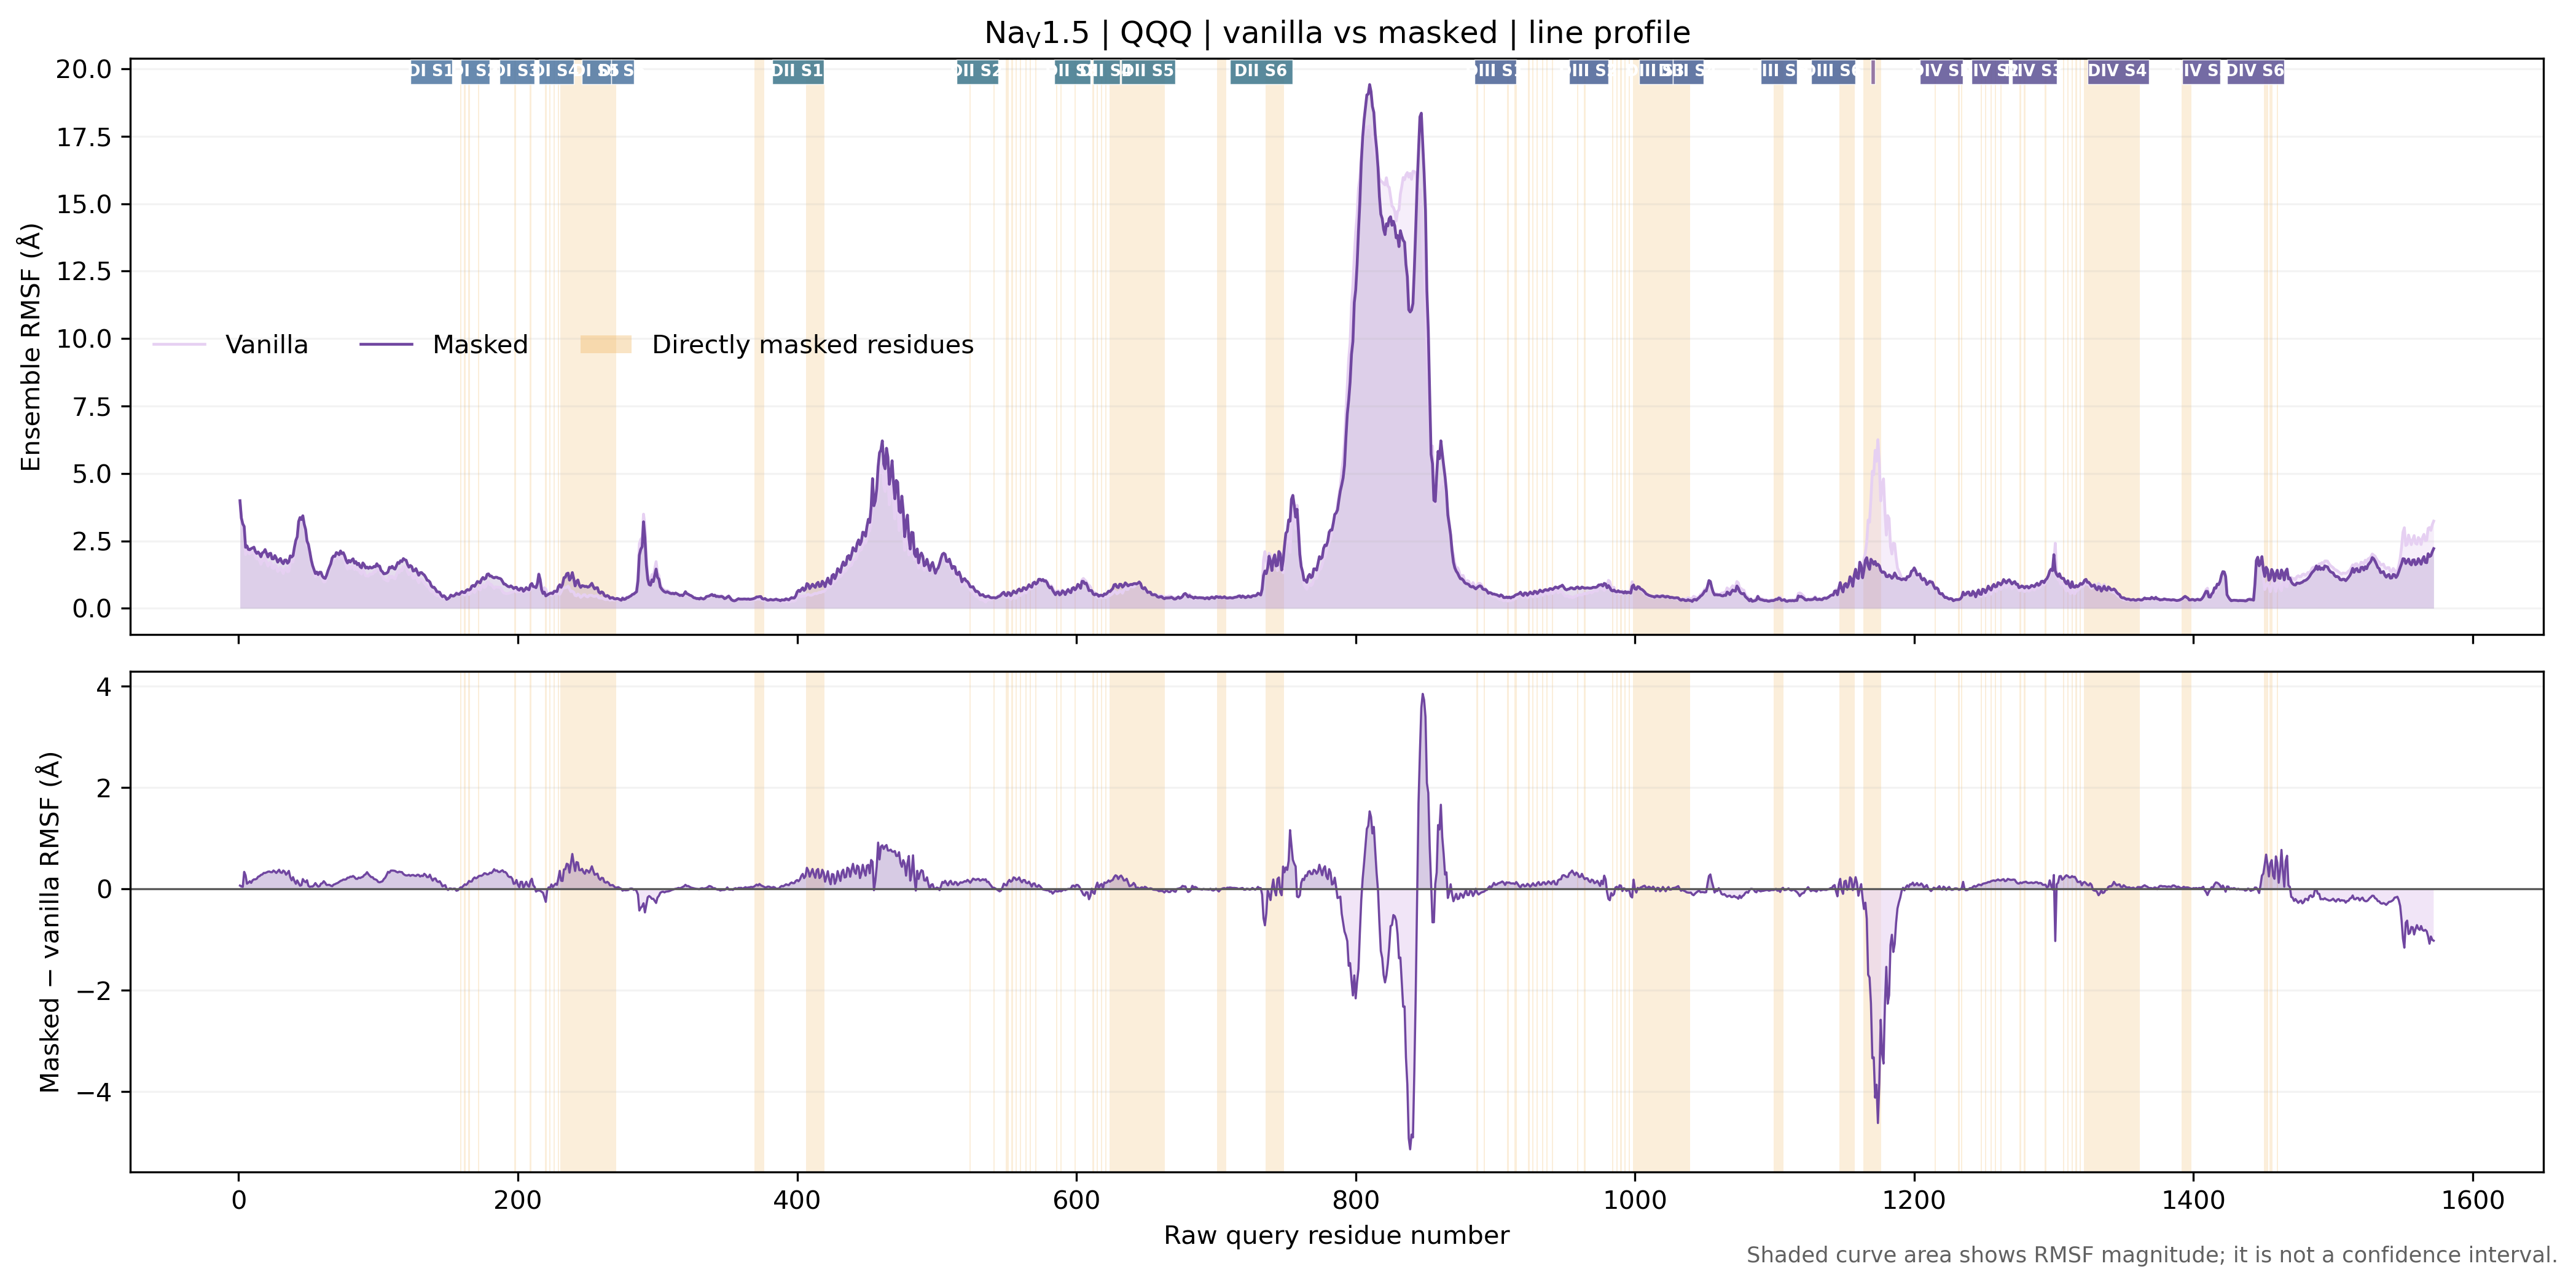

#### Mutation-centered window: raw residues 1140–1200

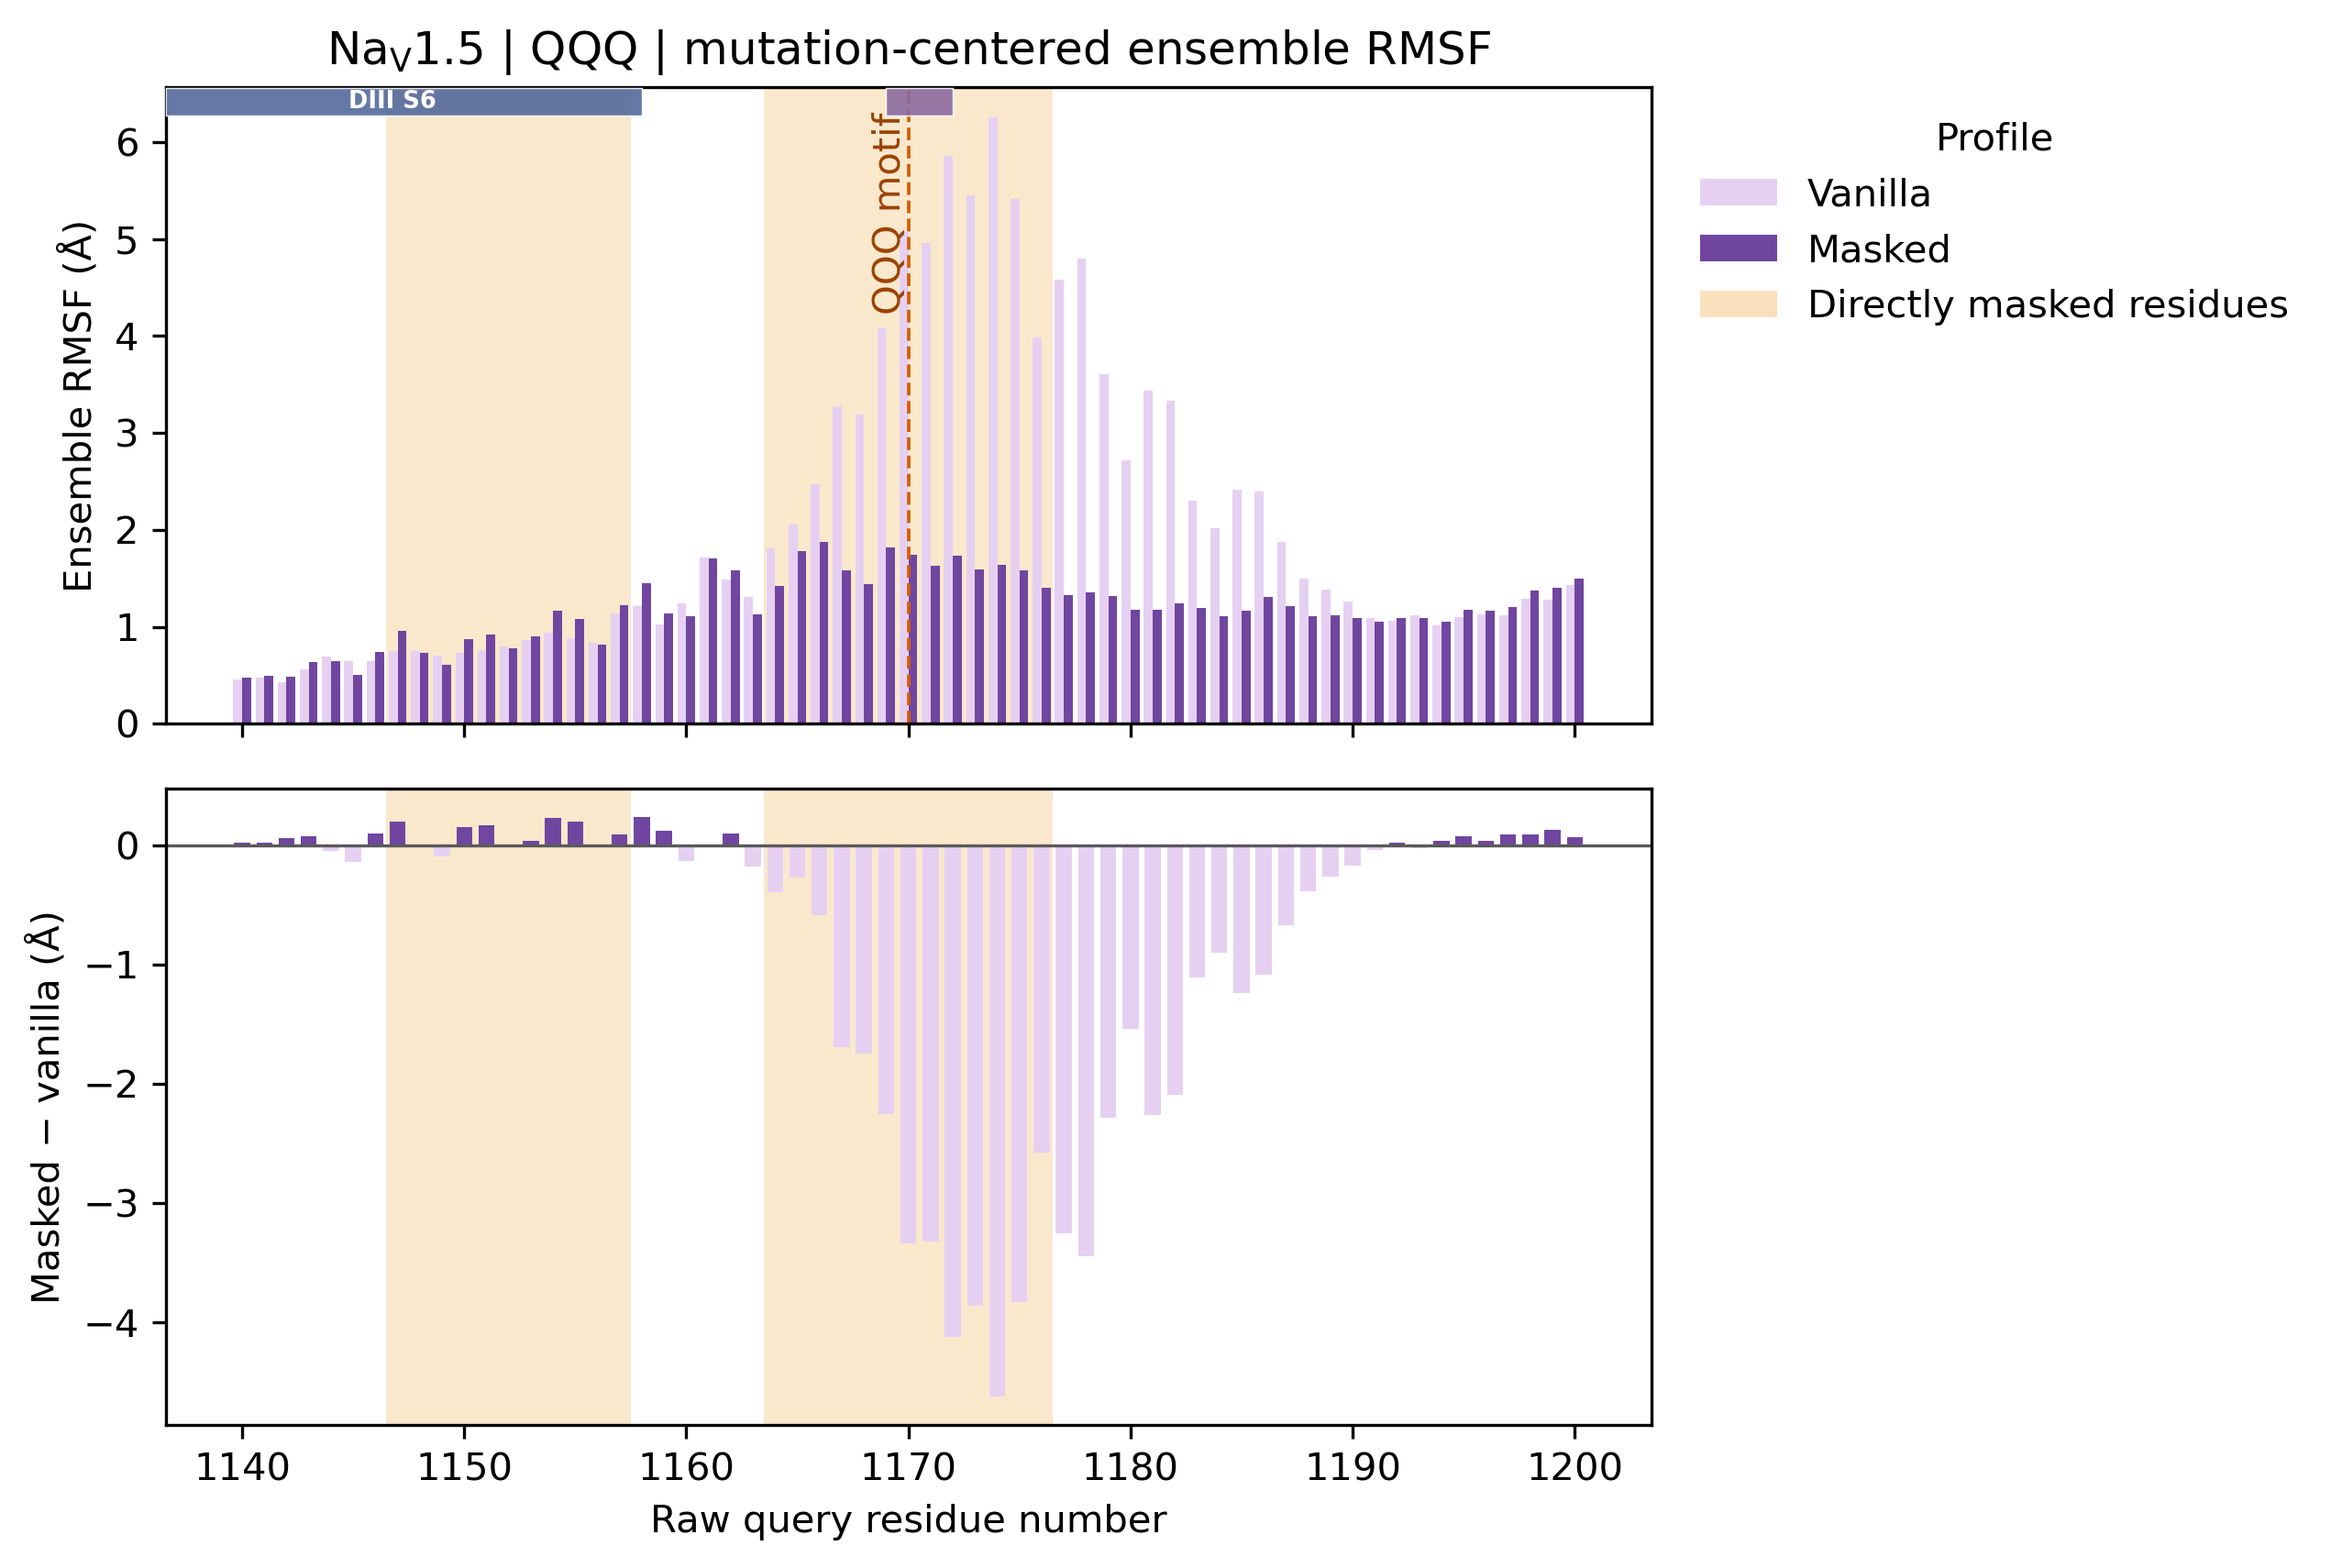

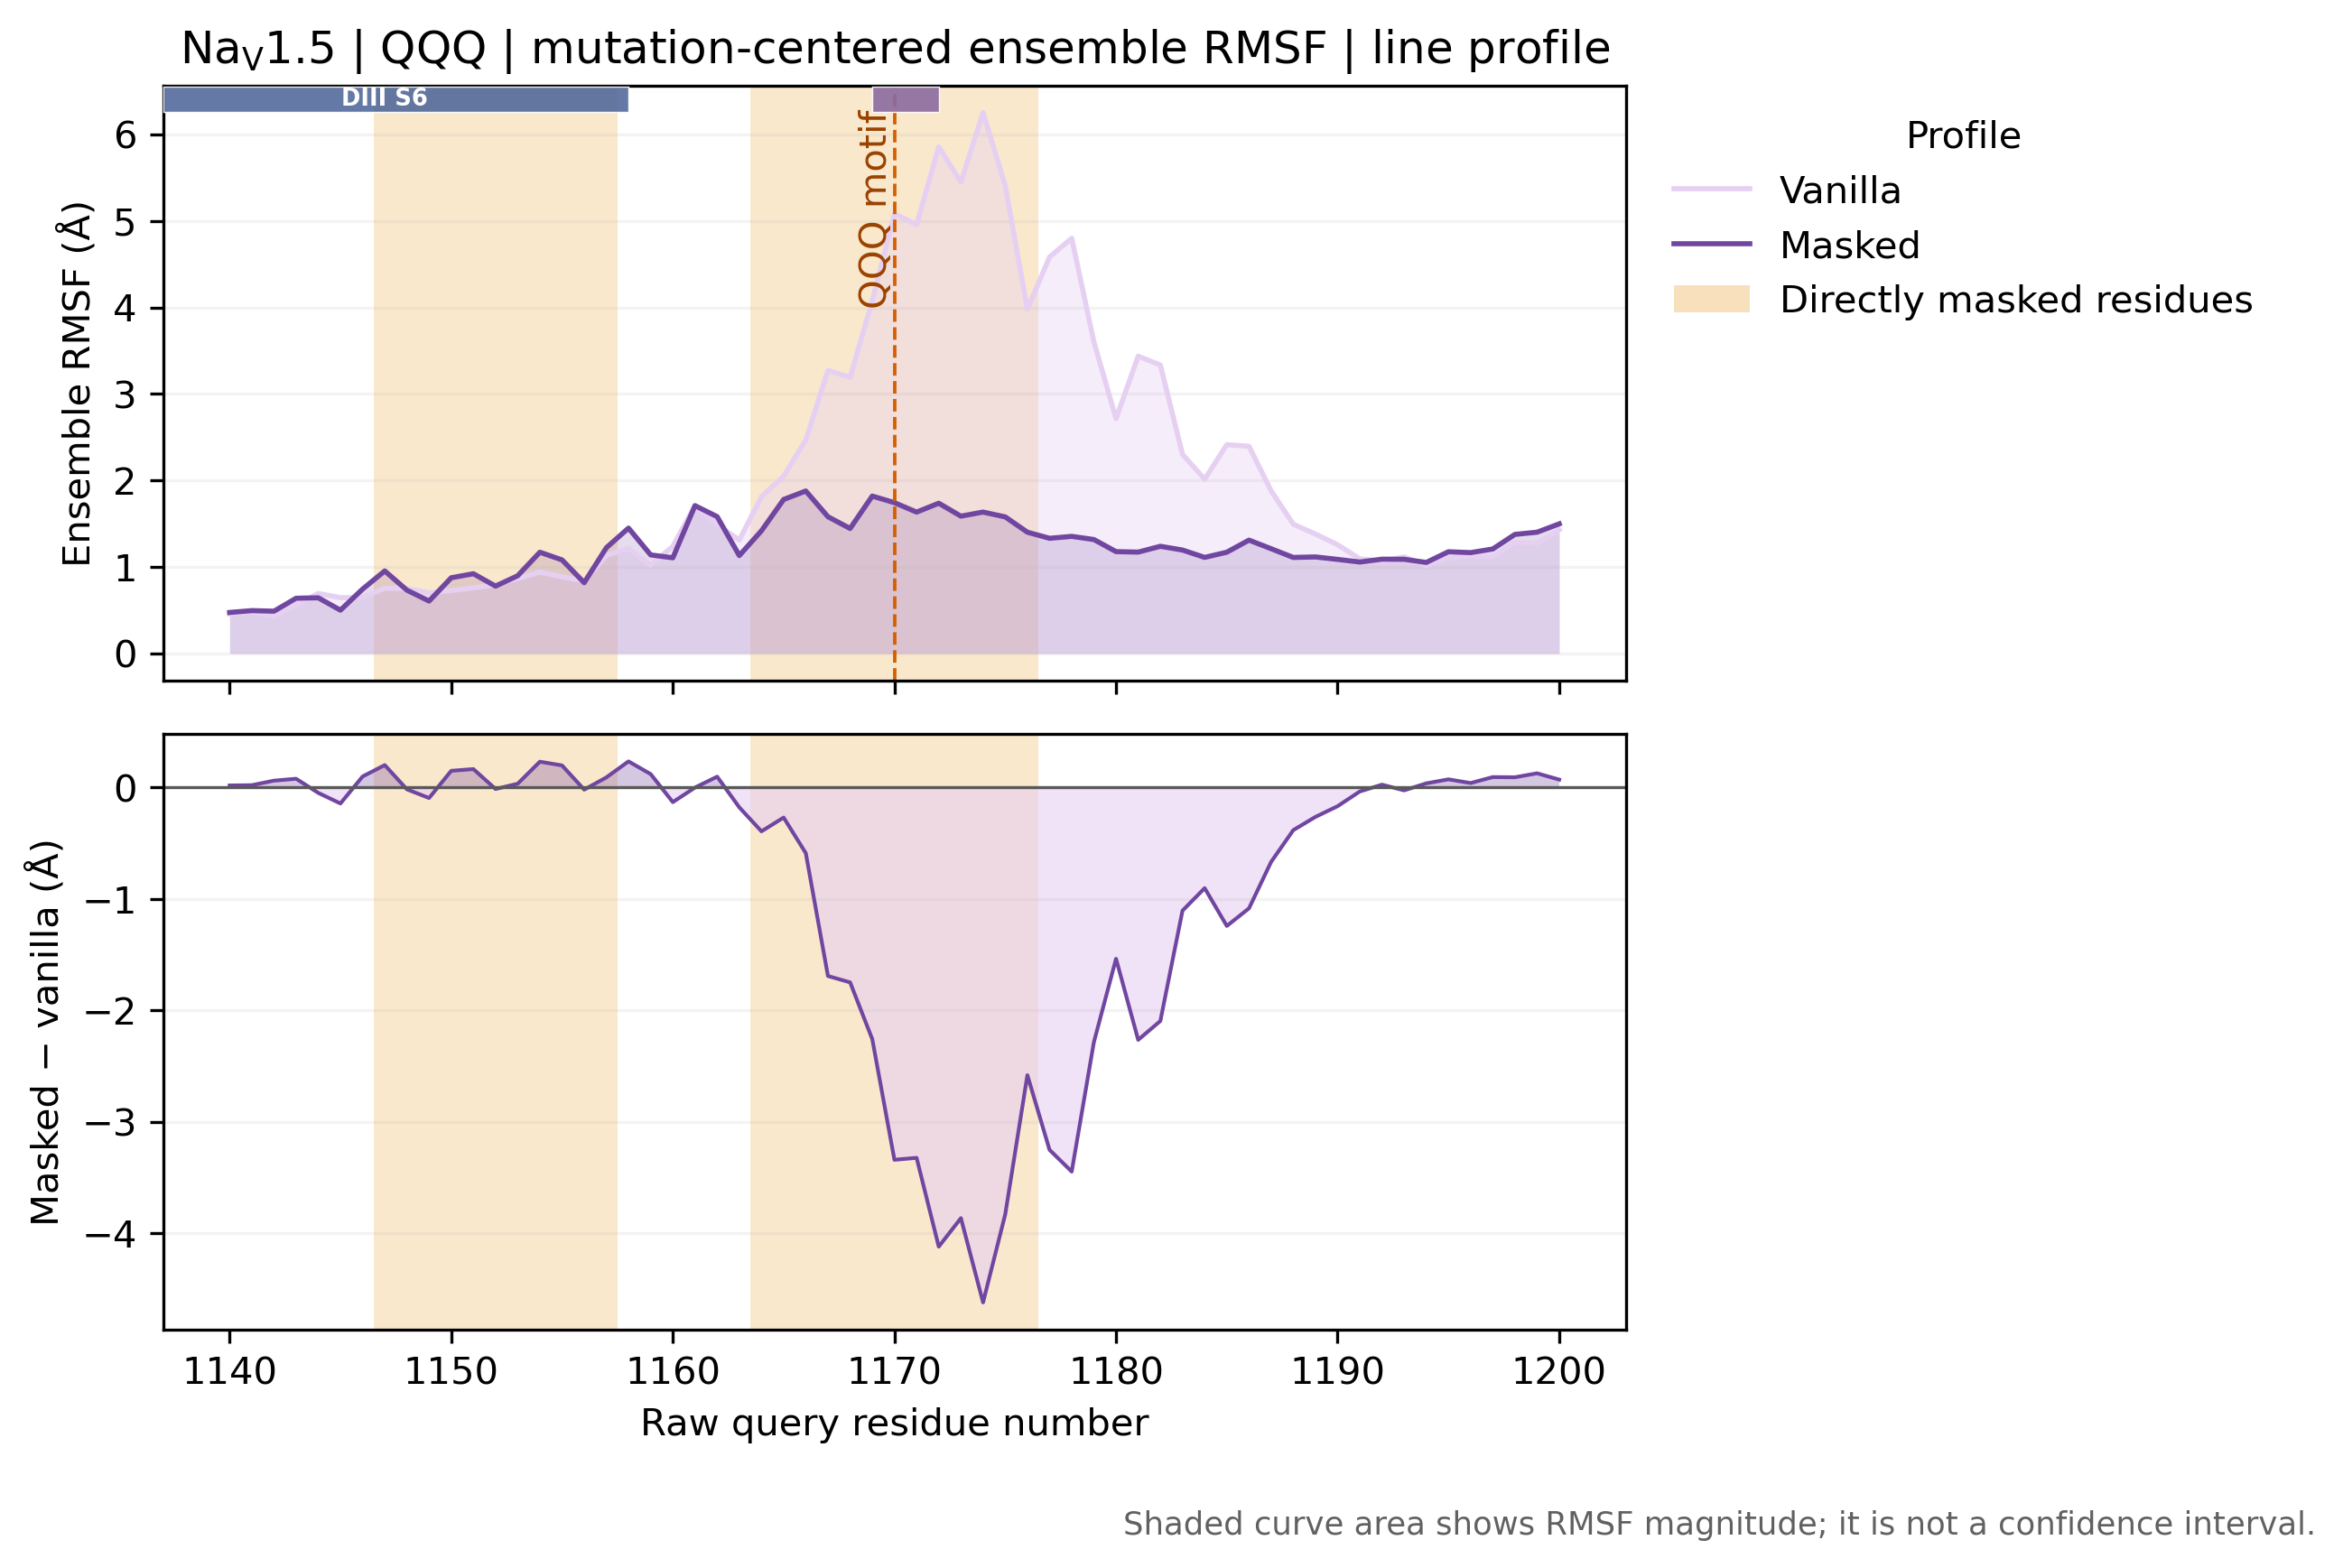

### QQQ: vanilla versus masked v2

#### Whole-protein residue profile — bar representation

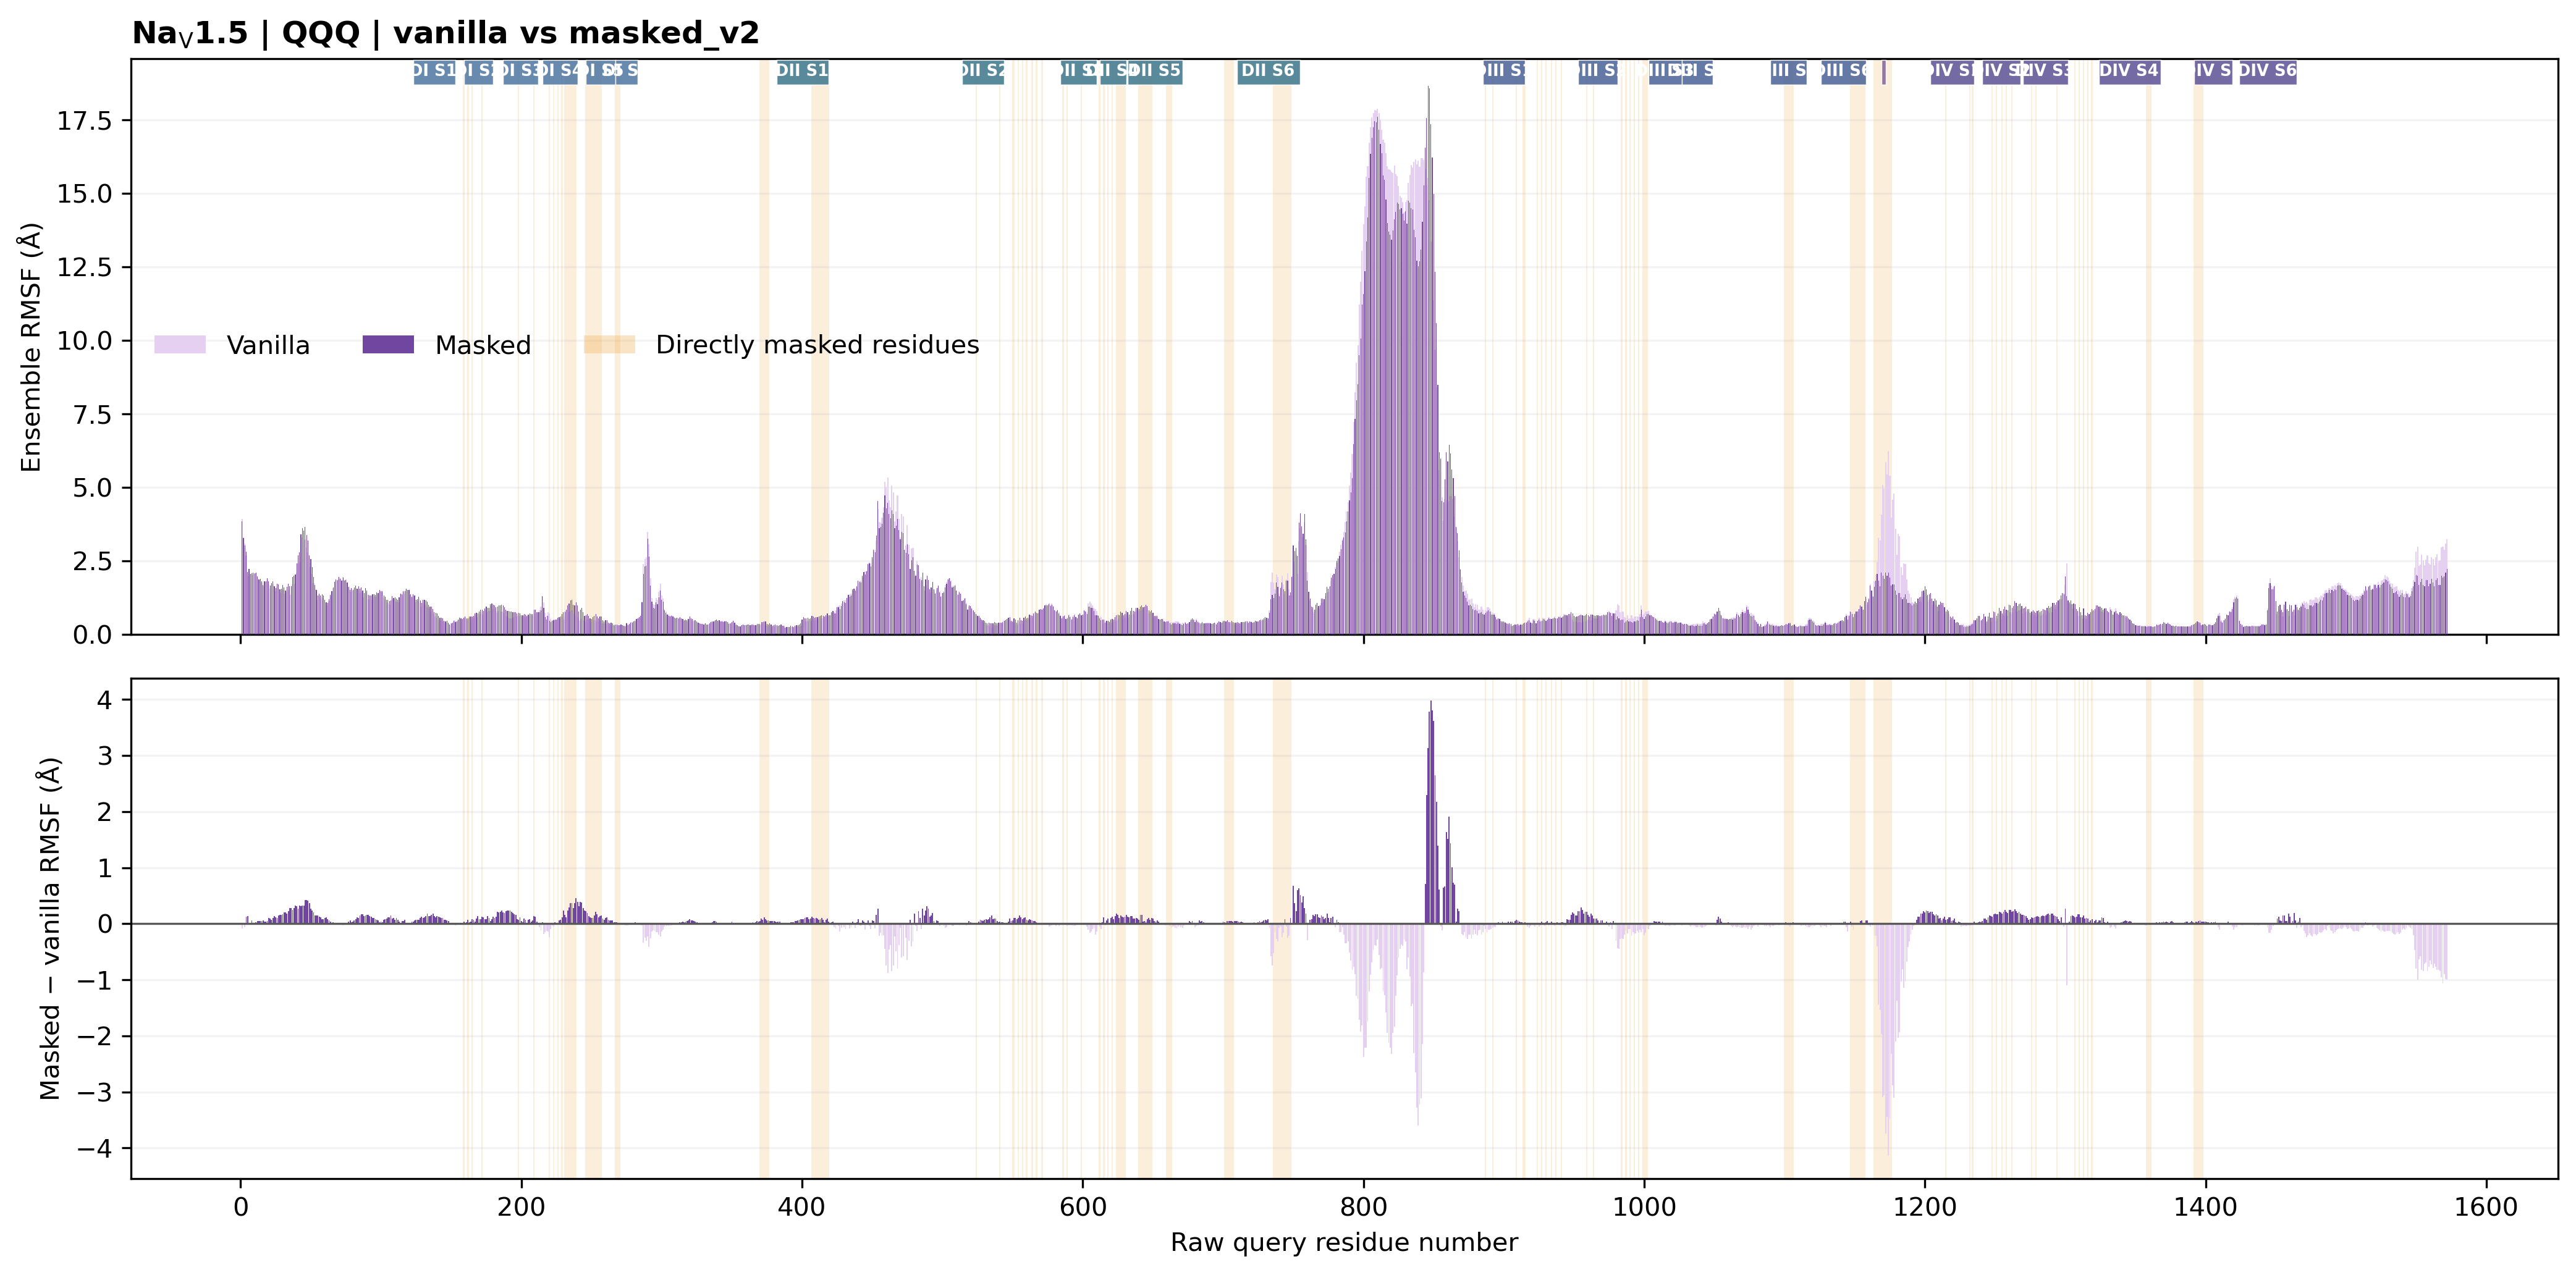

#### Whole-protein residue profile — line and magnitude-fill representation

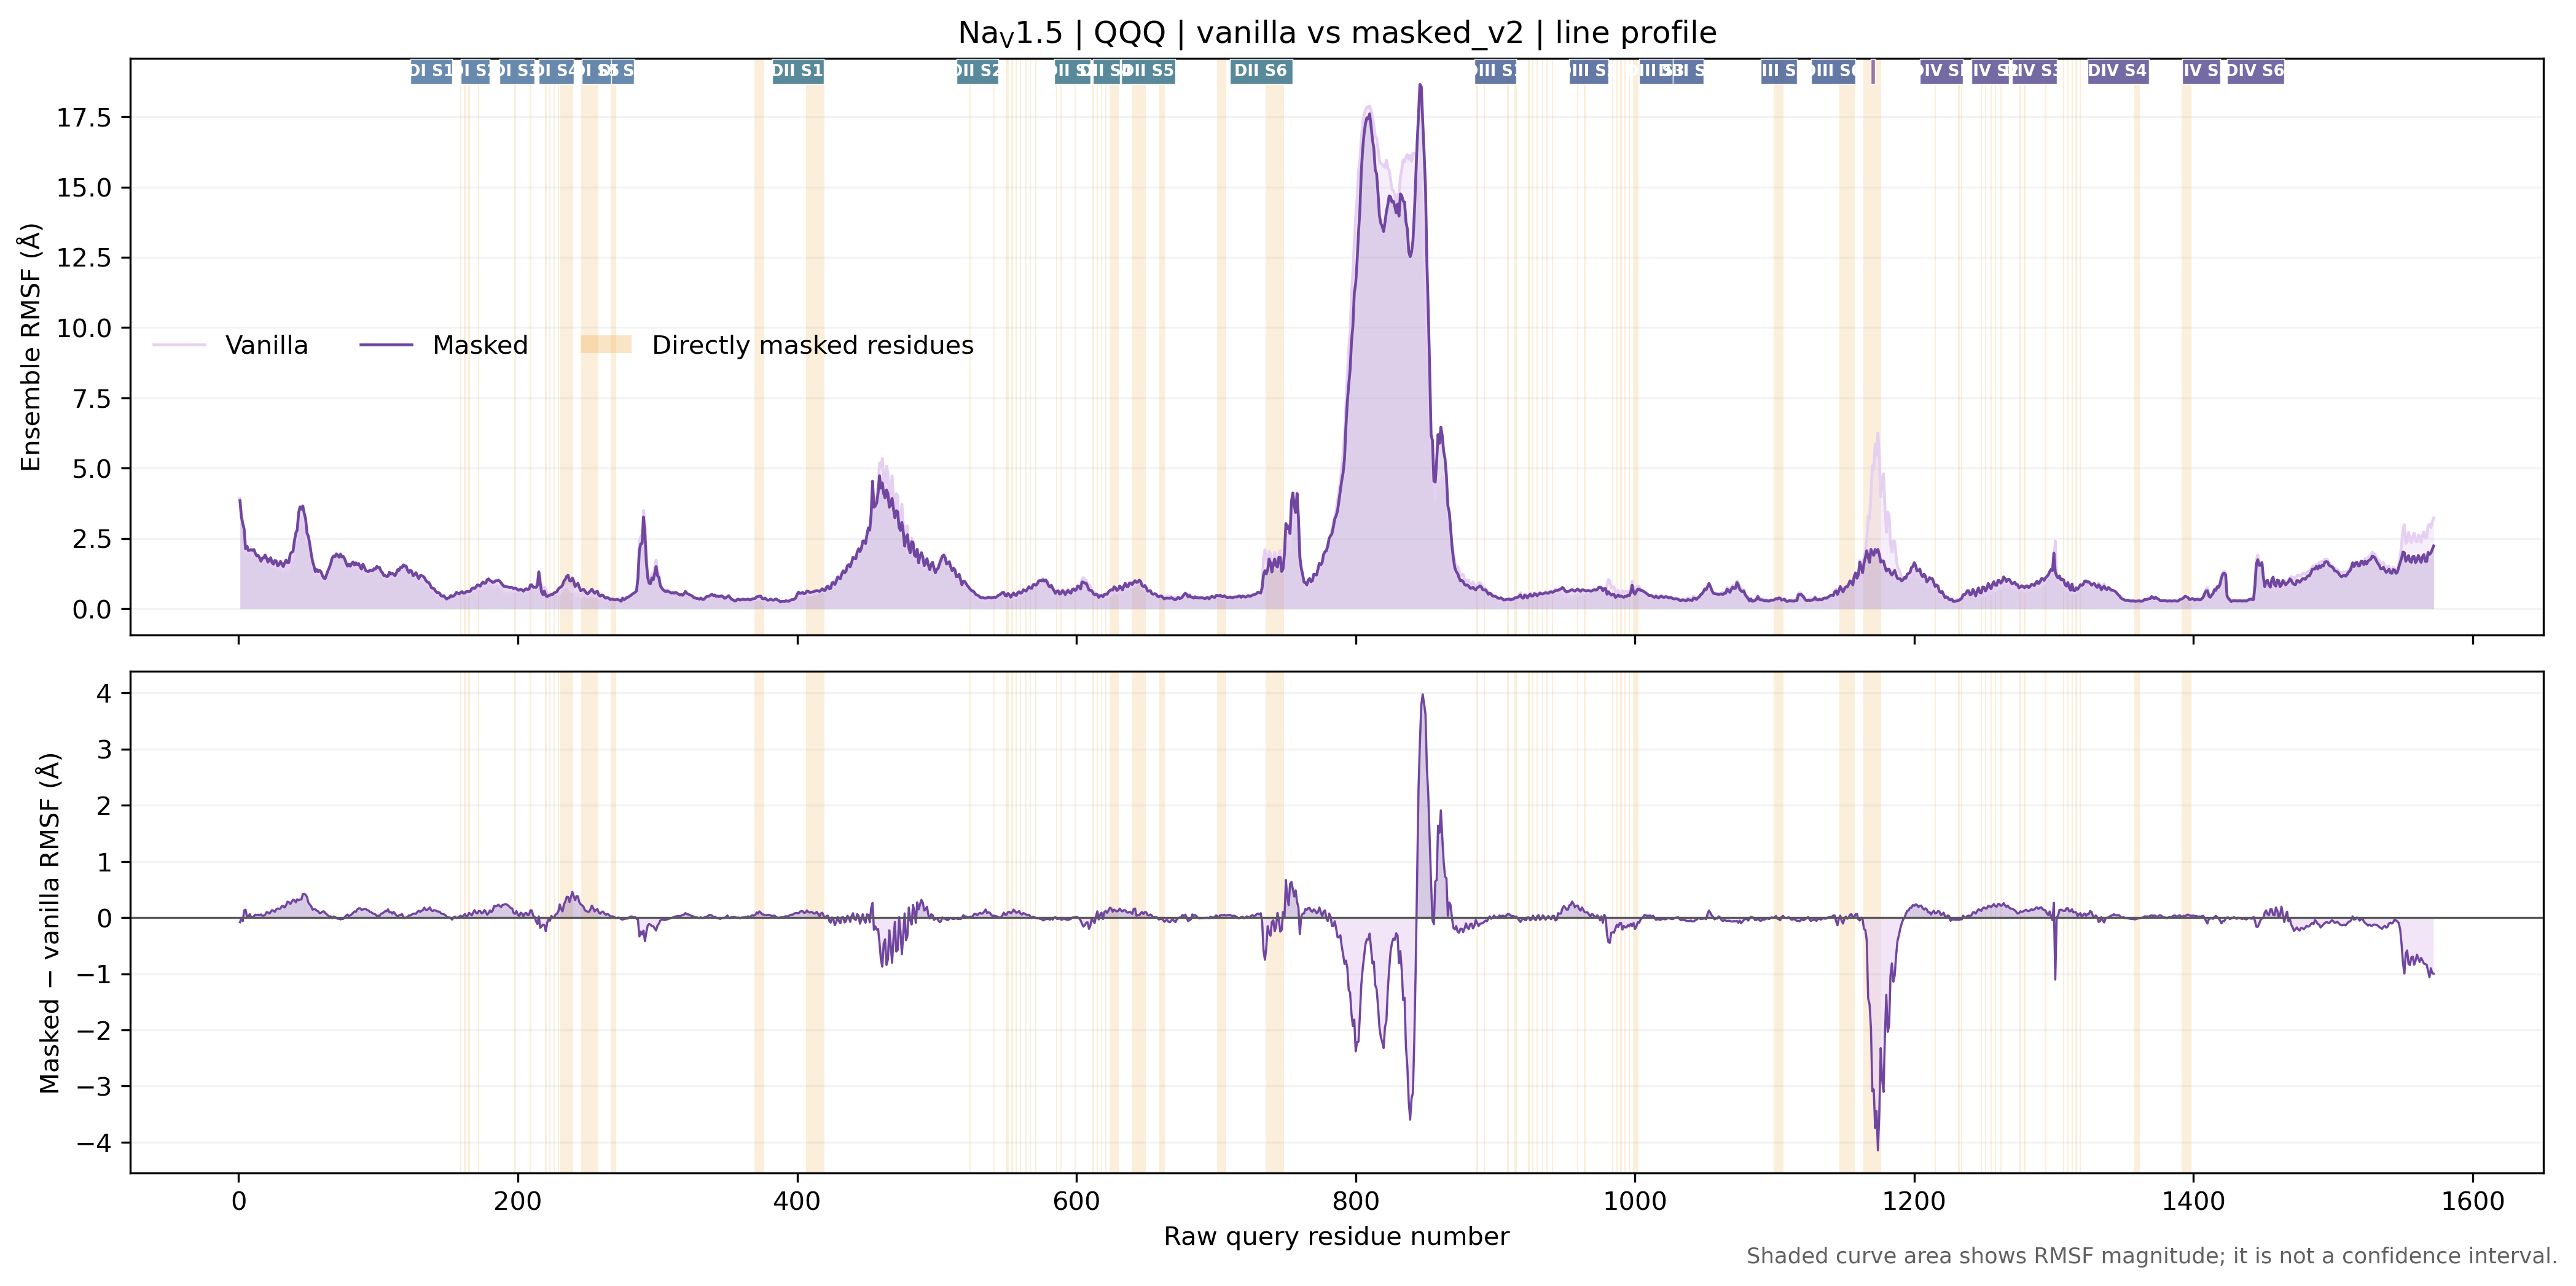

#### Mutation-centered window: raw residues 1140–1200

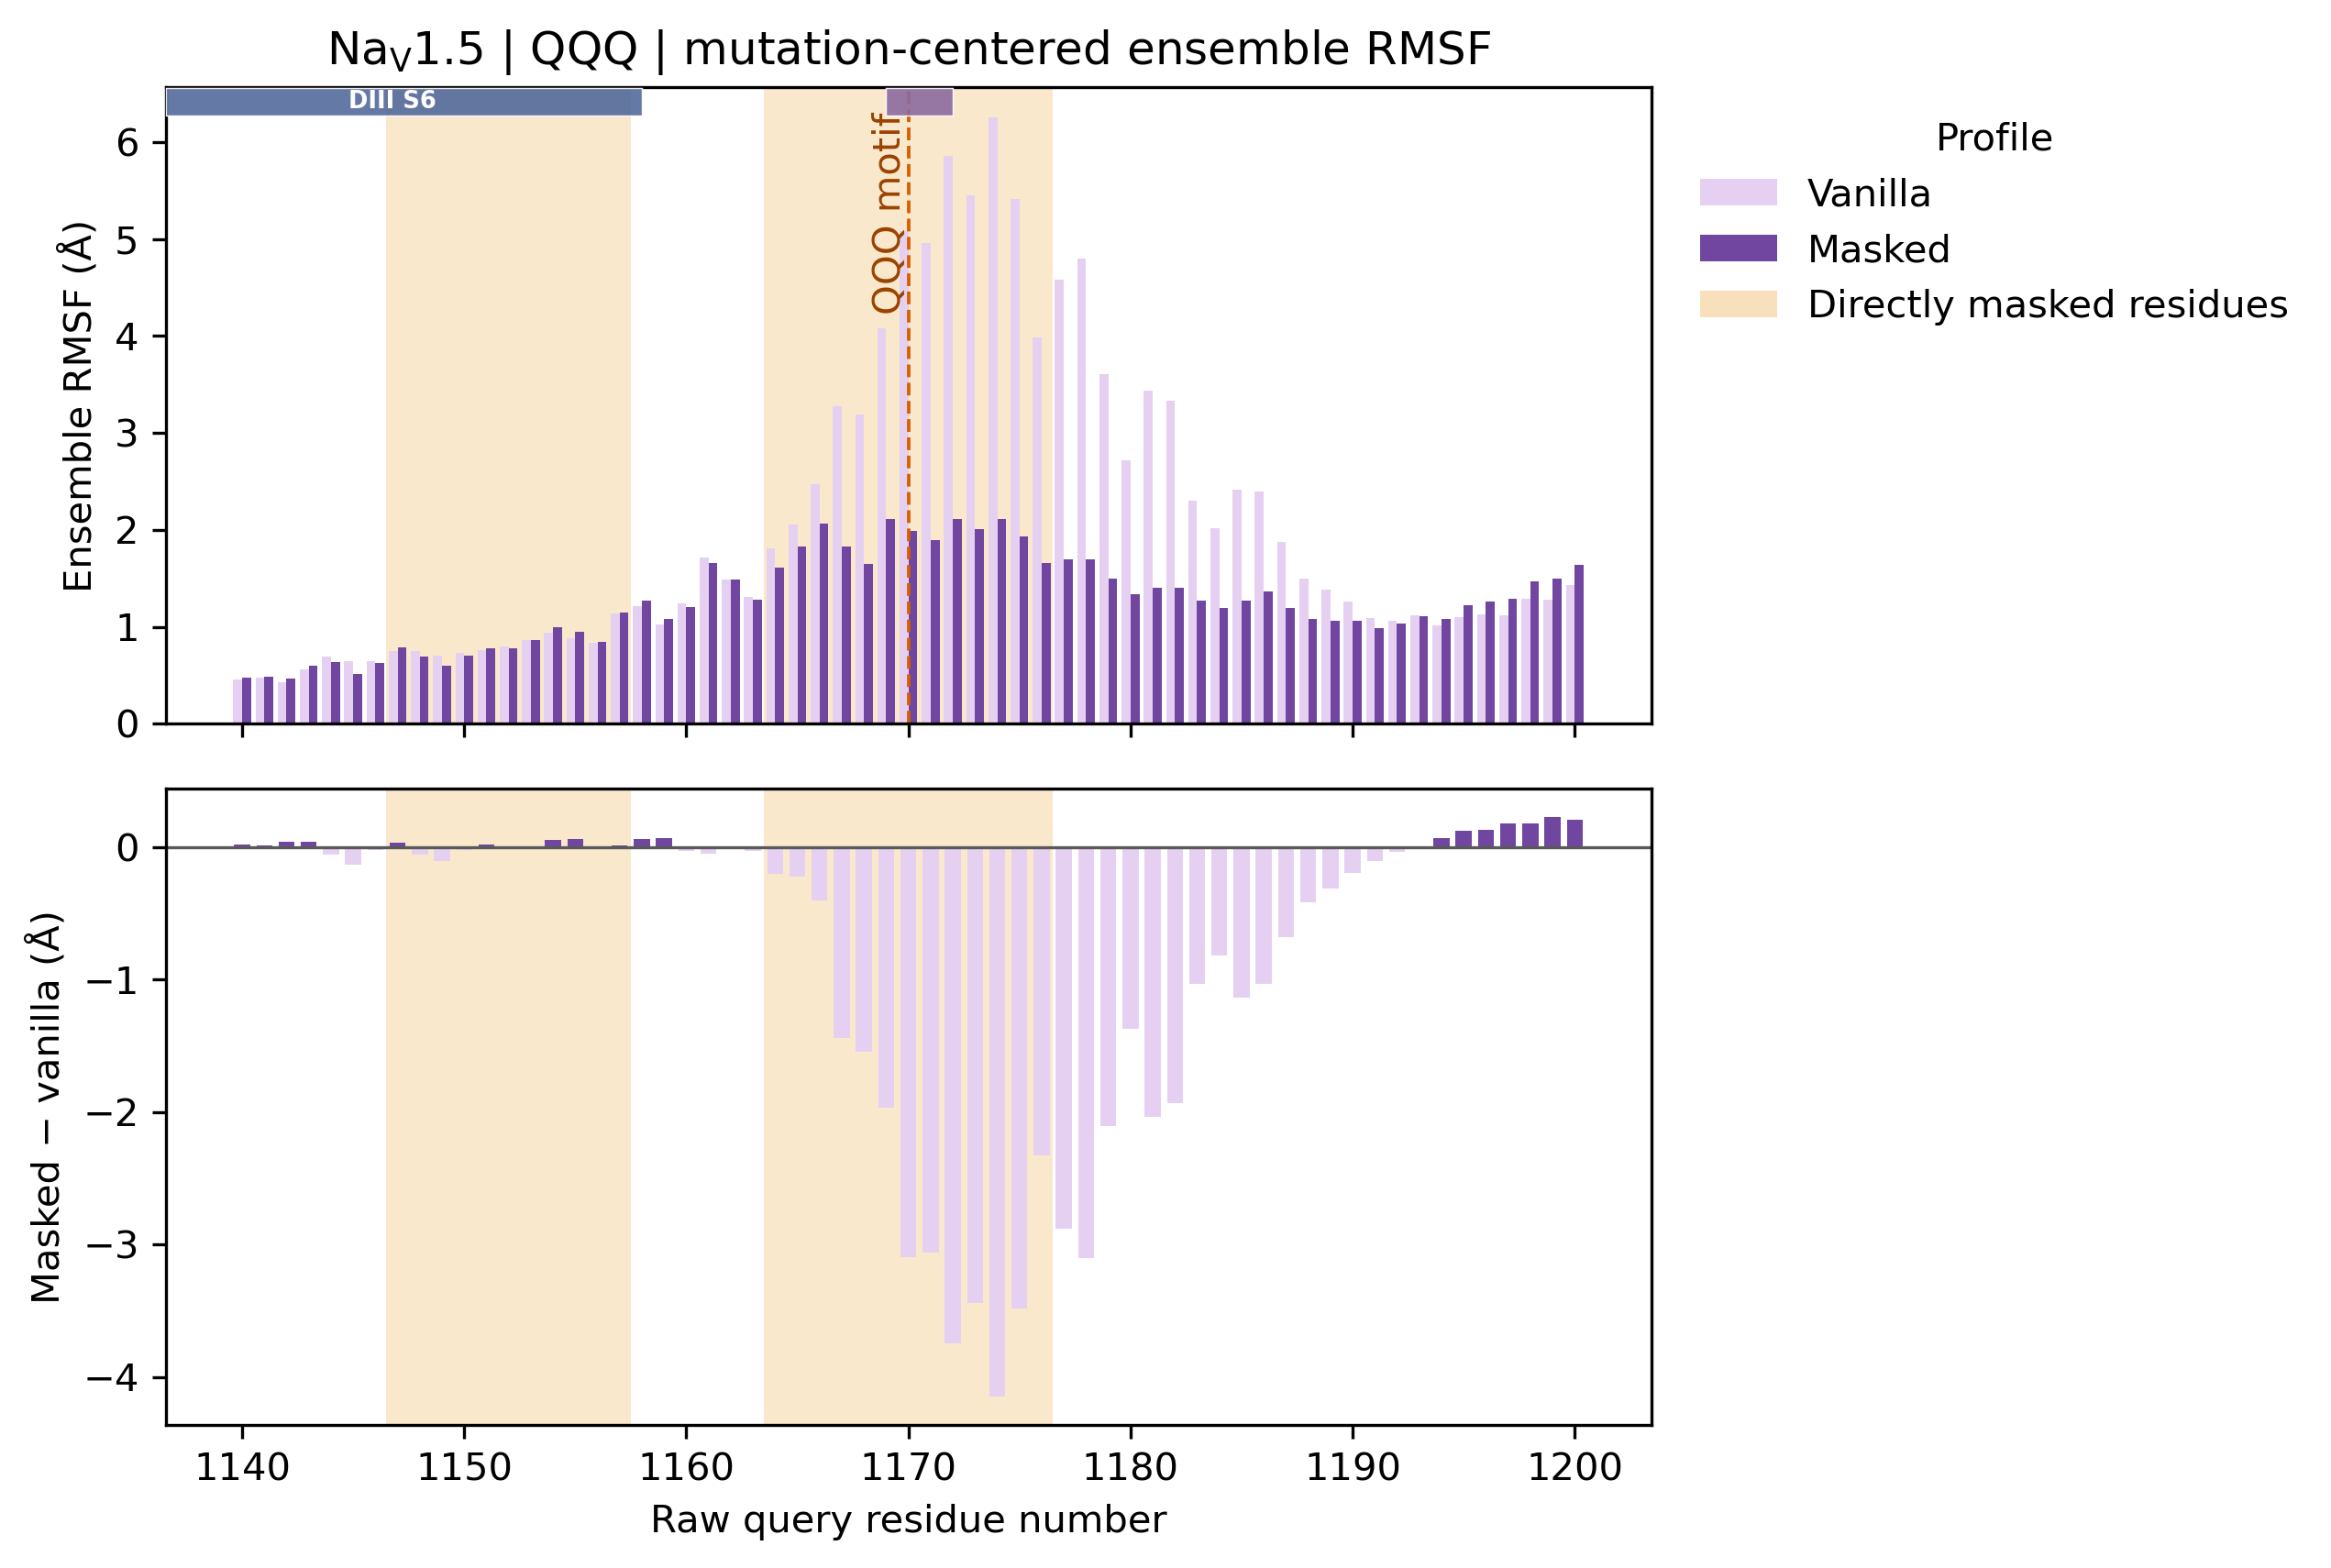

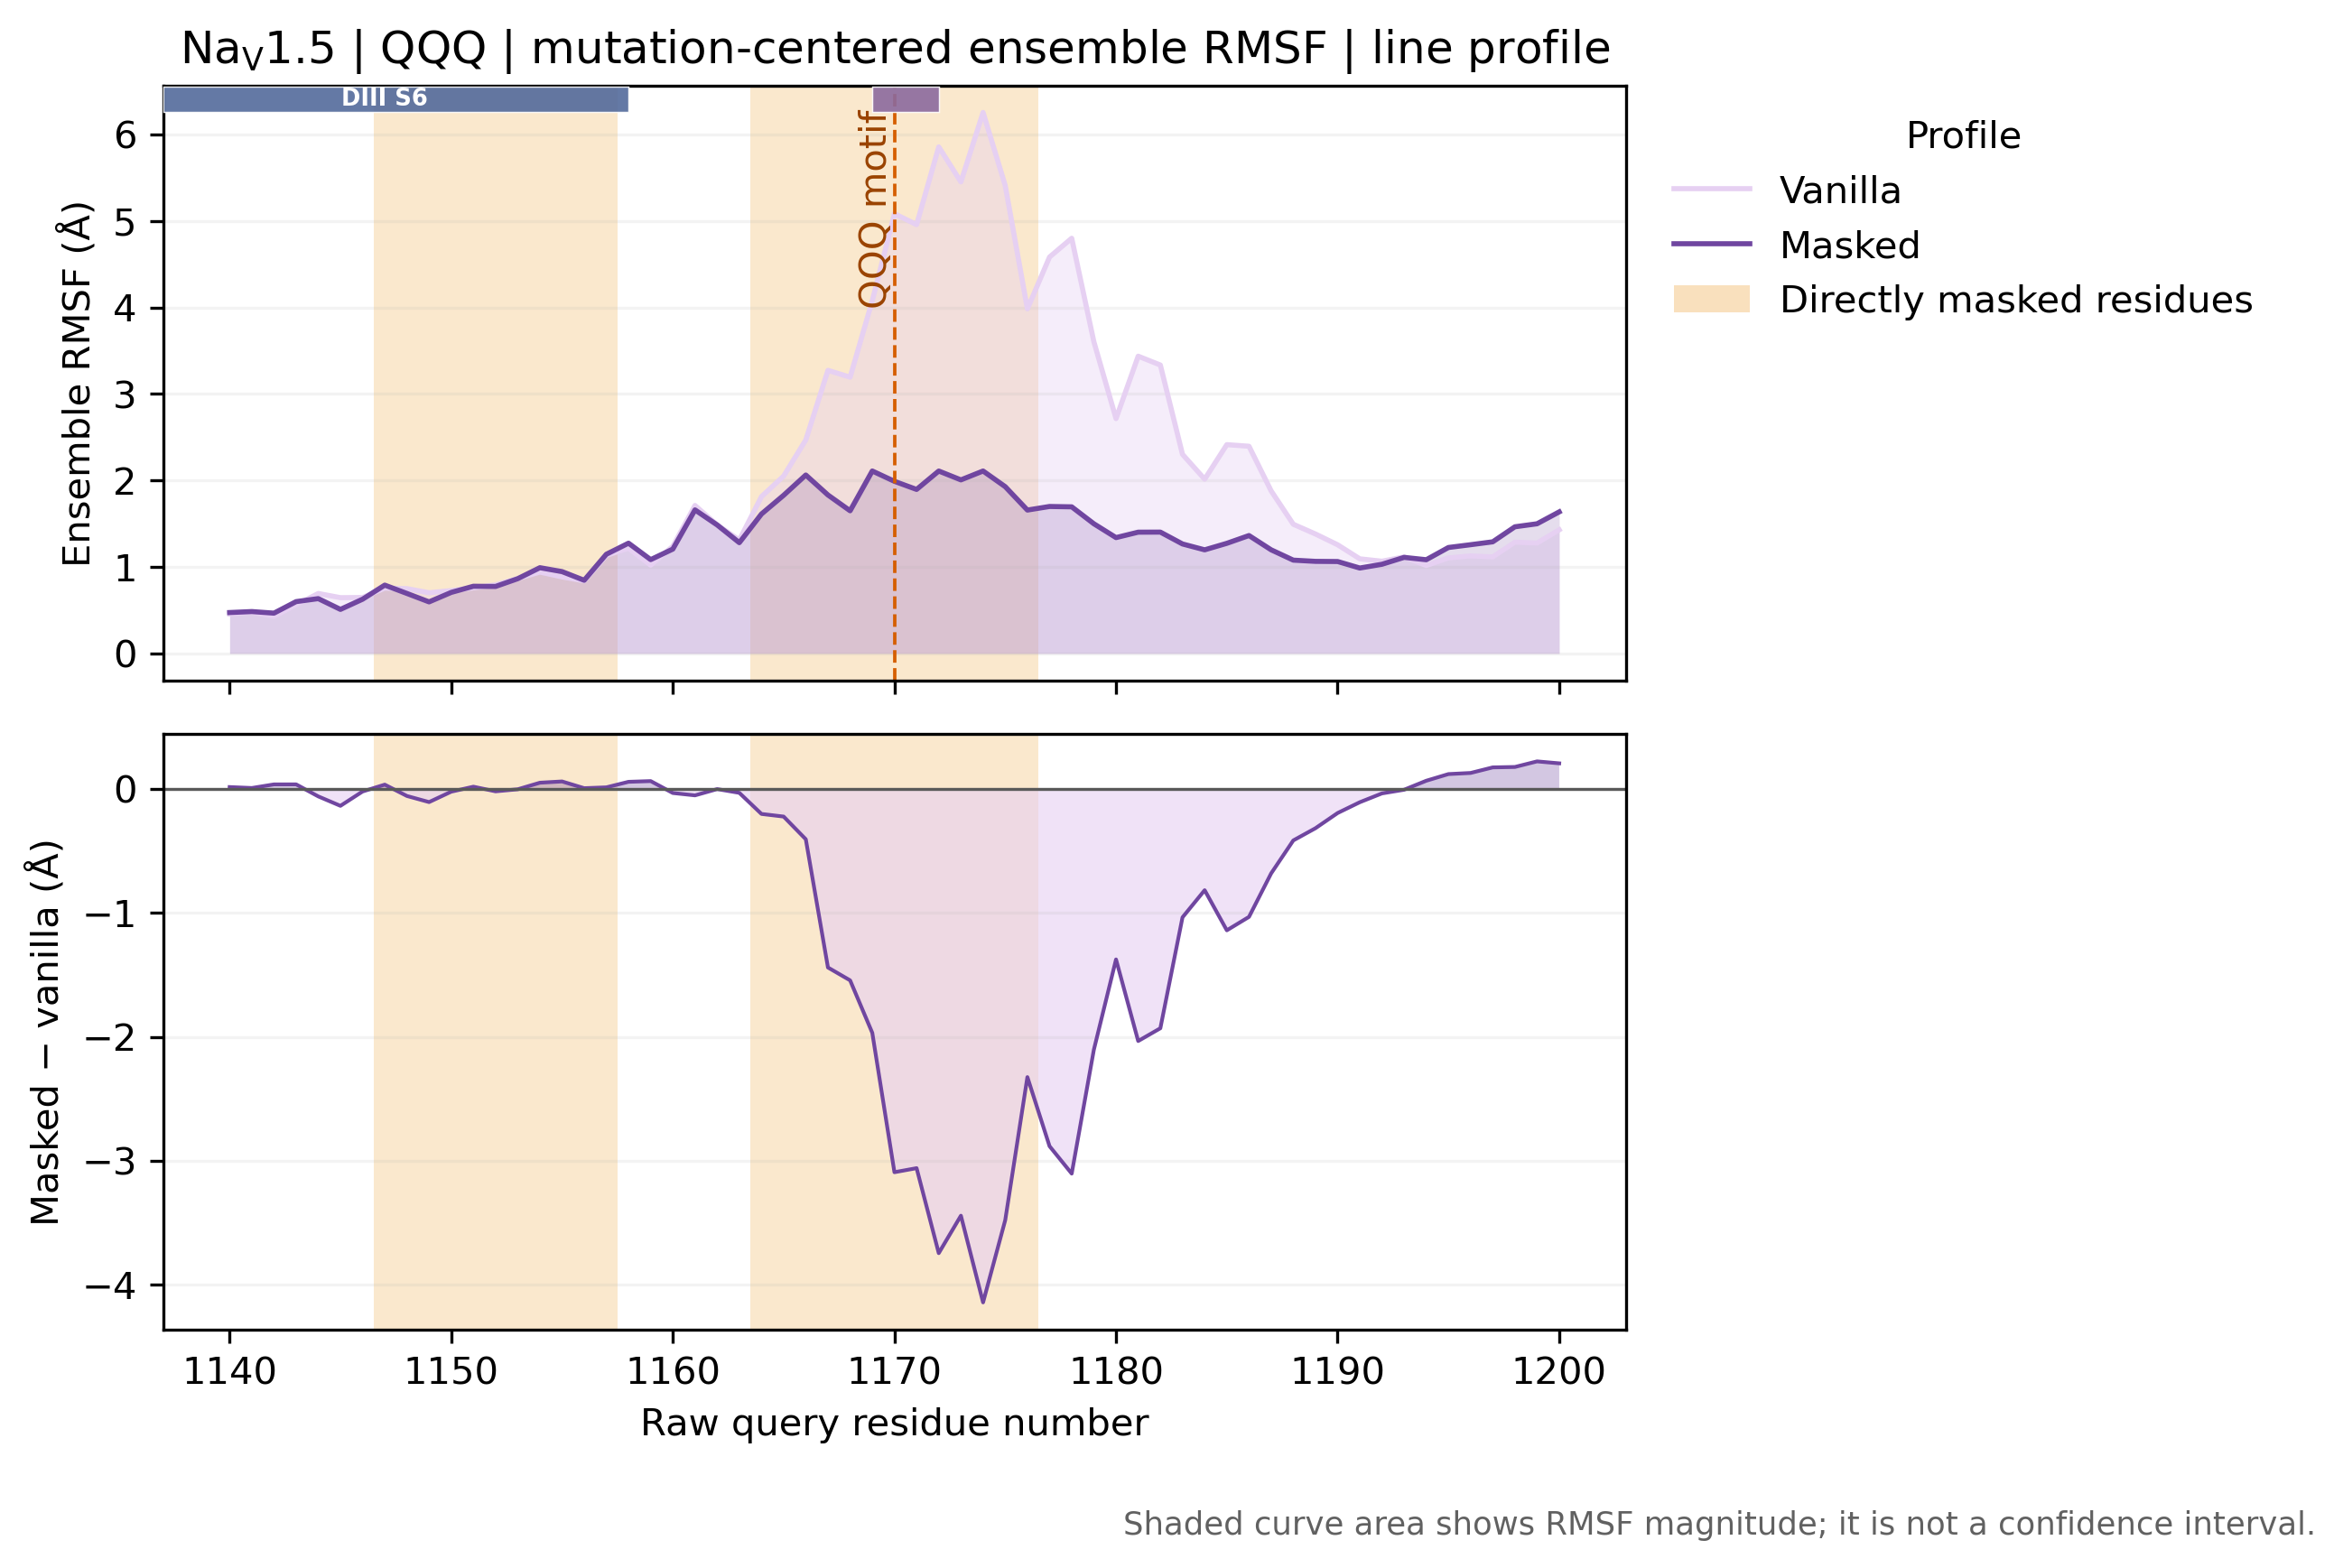

5 paired comparisons are represented above.


In [4]:
COMPARISONS=[('wt', 'masked'), ('wt', 'masked_v2'), ('wt', 'masked_v2_noIFM'), ('qqq', 'masked'), ('qqq', 'masked_v2')]
ZOOMS={'wt': (1140, 1200, {1170: 'IFM motif'}), 'qqq': (1140, 1200, {1170: 'QQQ motif'})}
comparison_tables=[]
for condition,protocol in COMPARISONS:
    condition_palette=ensemble_protocol_palette(CHANNEL,condition)
    display(Markdown(f'### {condition.upper()}: vanilla versus {protocol.replace("_", " ")}'))
    dataset_name=condition+'_'+protocol
    mask=set(mask_table.loc[(mask_table.dataset==dataset_name)&mask_table.directly_masked.astype(bool),'raw_residue_number'].astype(int)) if MASKS_AVAILABLE else set()
    comparison=paired_rmsf_comparison(profile,condition,protocol,schema['rmsf'],mask)
    comparison.to_csv(tables/f'{CHANNEL}_{condition}_{protocol}_paired_rmsf.csv',index=False)
    if MASKS_AVAILABLE:
        allocation,classes=summarize_comparison(comparison)
        allocation.assign(sequence_condition=condition,comparison_protocol=protocol).to_csv(tables/f'{CHANNEL}_{condition}_{protocol}_absolute_change_allocation.csv',index=False)
        classes.assign(sequence_condition=condition,comparison_protocol=protocol).to_csv(tables/f'{CHANNEL}_{condition}_{protocol}_mask_classes.csv',index=False)
    top=pd.concat([comparison.nlargest(20,'masked_minus_vanilla_rmsf_A'),comparison.nsmallest(20,'masked_minus_vanilla_rmsf_A')]).drop_duplicates()
    top.to_csv(tables/f'{CHANNEL}_{condition}_{protocol}_top_rmsf_changes.csv',index=False)
    paired_experimental_differences(profile,condition,protocol).to_csv(tables/f'{CHANNEL}_{condition}_{protocol}_experimental_differences.csv',index=False)
    display(Markdown('#### Whole-protein residue profile — bar representation'))
    whole_path=figures/f'{CHANNEL}_{condition}_{protocol}_whole_protein.png'
    plot_whole_protein(comparison,mask,f'{CHANNEL_LABEL} | {condition.upper()} | vanilla vs {protocol}',whole_path,topology=CHANNEL_TOPOLOGY,colors=condition_palette)
    display(Image(filename=str(whole_path),width=1100))
    display(Markdown('#### Whole-protein residue profile — line and magnitude-fill representation'))
    whole_line_path=figures/f'{CHANNEL}_{condition}_{protocol}_whole_protein_line.png'
    plot_whole_protein_lines(comparison,mask,f'{CHANNEL_LABEL} | {condition.upper()} | vanilla vs {protocol}',whole_line_path,topology=CHANNEL_TOPOLOGY,colors=condition_palette)
    display(Image(filename=str(whole_line_path),width=1100))
    if condition in ZOOMS:
        start,end,annotations=ZOOMS[condition]
        display(Markdown(f'#### Mutation-centered window: raw residues {start}–{end}'))
        zoom_path=figures/f'{CHANNEL}_{condition}_{protocol}_zoom.png'
        plot_zoom(comparison,mask,start,end,f'{CHANNEL_LABEL} | {condition.upper()} | mutation-centered ensemble RMSF',zoom_path,annotations,topology=CHANNEL_TOPOLOGY,colors=condition_palette)
        display(Image(filename=str(zoom_path),width=950))
        zoom_line_path=figures/f'{CHANNEL}_{condition}_{protocol}_zoom_line.png'
        plot_zoom_lines(comparison,mask,start,end,f'{CHANNEL_LABEL} | {condition.upper()} | mutation-centered ensemble RMSF',zoom_line_path,annotations,topology=CHANNEL_TOPOLOGY,colors=condition_palette)
        display(Image(filename=str(zoom_line_path),width=950))
    comparison_tables.append(comparison)
print(f'{len(comparison_tables)} paired comparisons are represented above.')

## Does the effect remain localized to the mask?

Residues are grouped by their linear sequence distance from the nearest directly masked position: directly masked, 1–5 residues away, 6–10 residues away, or more than 10 residues away. This is sequence distance, not three-dimensional spatial distance.

The first violin plot shows the distribution of $\Delta\mathrm{RMSF}$ in each class. Its internal lines mark the quartiles. The split violins then show the underlying vanilla and masked RMSF distributions directly: vanilla occupies the left half and masked the right half. These distributions summarize residues and do not treat neighboring residues as statistically independent replicates.

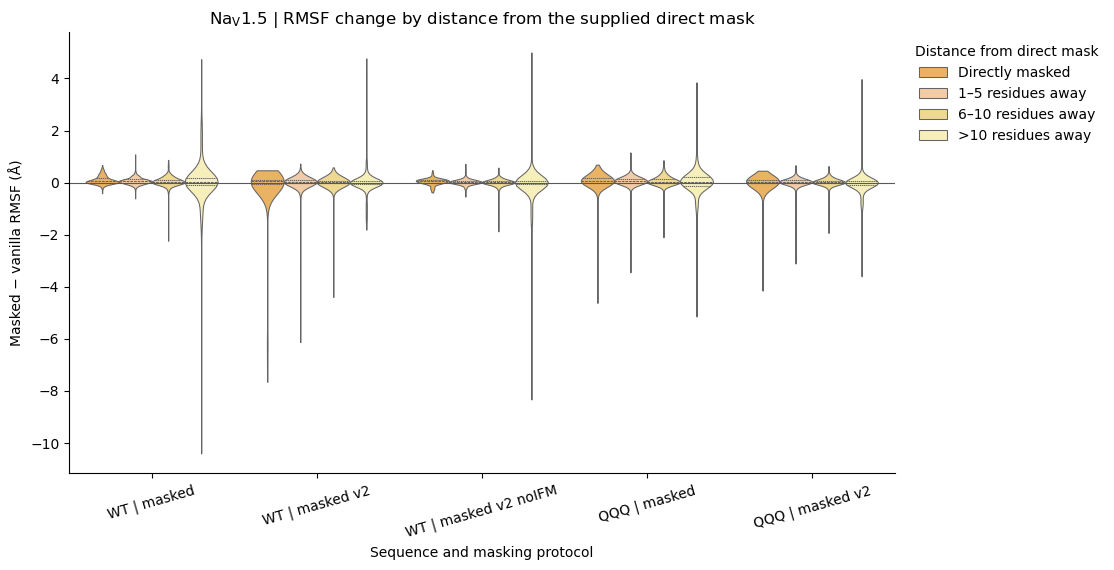

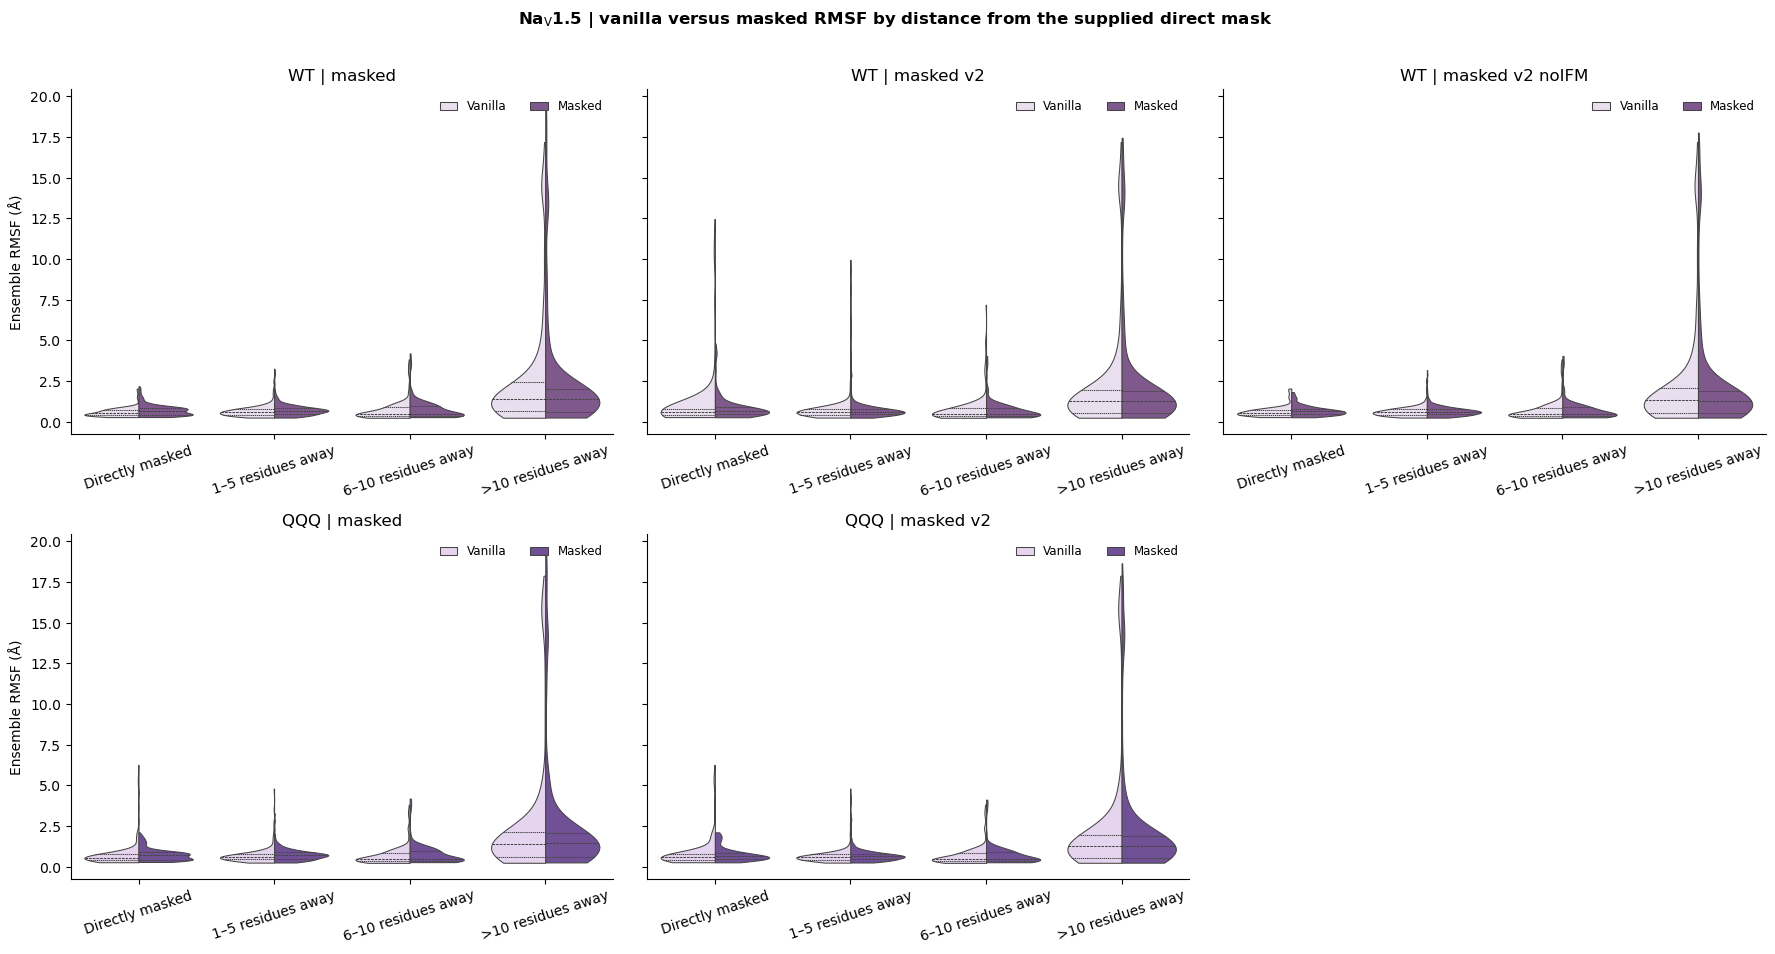

In [5]:
combined=pd.concat(comparison_tables,ignore_index=True)
if MASKS_AVAILABLE:
    combined['comparison_label']=combined.sequence_condition.str.upper()+' | '+combined.comparison_protocol.str.replace('_',' ',regex=False)
    class_order=['directly_masked','adjacent_to_mask_1_to_5','adjacent_to_mask_6_to_10','unmasked']
    class_labels={'directly_masked':'Directly masked','adjacent_to_mask_1_to_5':'1–5 residues away','adjacent_to_mask_6_to_10':'6–10 residues away','unmasked':'>10 residues away'}
    combined['residue_class']=combined.mask_sequence_class.map(class_labels)
    display_order=[class_labels[value] for value in class_order]
    fig,ax=plt.subplots(figsize=(max(10,2.25*combined.comparison_label.nunique()),5.8));sns.violinplot(data=combined,x='comparison_label',y='masked_minus_vanilla_rmsf_A',hue='residue_class',hue_order=display_order,cut=0,inner='quart',density_norm='width',common_norm=False,linewidth=.75,ax=ax,palette=[ACCENT_PALETTE['ORANGE'],ACCENT_PALETTE['PEACH'],ACCENT_PALETTE['YELLOW'],ACCENT_PALETTE['CREAM']])
    ax.axhline(0,color='.35',lw=.8);ax.set(xlabel='Sequence and masking protocol',ylabel='Masked − vanilla RMSF (Å)',title=f'{CHANNEL_LABEL} | RMSF change by distance from the supplied direct mask');ax.tick_params(axis='x',rotation=16);ax.legend(title='Distance from direct mask',frameon=False,bbox_to_anchor=(1.01,1),loc='upper left');sns.despine();fig.tight_layout();fig.savefig(figures/f'{CHANNEL}_mask_class_distributions.png',dpi=300,bbox_inches='tight');plt.show()
    panel_labels=combined.comparison_label.drop_duplicates().tolist();ncols=min(3,len(panel_labels));nrows=int(np.ceil(len(panel_labels)/ncols));fig,axes=plt.subplots(nrows,ncols,figsize=(6.0*ncols,4.7*nrows),sharey=True,squeeze=False)
    for panel_index,panel_label in enumerate(panel_labels):
        ax=axes.flat[panel_index];part=combined.loc[combined.comparison_label.eq(panel_label)].copy();long=part.melt(id_vars=['residue_class'],value_vars=['vanilla_rmsf_A','masked_rmsf_A'],var_name='ensemble',value_name='rmsf_A');long['ensemble']=long.ensemble.map({'vanilla_rmsf_A':'Vanilla','masked_rmsf_A':'Masked'})
        panel_condition=part.sequence_condition.iloc[0];panel_palette=ensemble_protocol_palette(CHANNEL,panel_condition)
        sns.violinplot(data=long,x='residue_class',y='rmsf_A',hue='ensemble',order=display_order,hue_order=['Vanilla','Masked'],split=True,inner='quart',cut=0,density_norm='width',common_norm=False,linewidth=.75,palette=panel_palette,ax=ax)
        ax.set(title=panel_label,xlabel='',ylabel='Ensemble RMSF (Å)' if panel_index%ncols==0 else '');ax.tick_params(axis='x',rotation=18);ax.legend(title=None,frameon=False,loc='upper right',ncol=2,fontsize=8.5,handlelength=1.5);sns.despine(ax=ax)
    for extra in axes.flat[len(panel_labels):]: extra.set_visible(False)
    fig.suptitle(f'{CHANNEL_LABEL} | vanilla versus masked RMSF by distance from the supplied direct mask',weight='bold',y=1.01);fig.tight_layout();fig.savefig(figures/f'{CHANNEL}_mask_class_split_vanilla_vs_masked.png',dpi=300,bbox_inches='tight');plt.show()
else: print('Mask-class distribution intentionally skipped until A3M extraction succeeds.')

## Redistribution across proposed channel segments

To examine whether RMSF changes extend beyond the targeted sequence blocks, the residue-level $\Delta\mathrm{RMSF}$ values are summarized within each provisional topology segment. The heatmap reports the median change for that segment. Positive cells indicate broader masked sampling; negative cells indicate broader vanilla sampling.

This analysis can identify nonlocal redistribution, but it does not establish a directional upstream/downstream mechanism. A distant segment can change because of structural coupling, a different global alignment response, altered coverage, or a coherent displacement of the ensemble. Segment boundaries are provisional, and neighboring residues are not independent statistical observations.

,condition,protocol,comparison,segment,domain,boundary_confidence,raw_start,raw_end,number_of_residues,number_directly_masked,fraction_directly_masked,median_delta_rmsf_A,mean_delta_rmsf_A,fraction_residues_increased
0,wt,masked,WT | masked,DI S1,DI,provisional,123,152,30,0,0.000,0.187,0.150,0.900
1,wt,masked,WT | masked,DI S2,DI,provisional,159,179,21,4,0.190,0.182,0.159,1.000
2,wt,masked,WT | masked,DI S3,DI,provisional,187,211,25,2,0.080,0.133,0.160,1.000
3,wt,masked,WT | masked,DI S4,DI,provisional,215,239,25,13,0.520,0.078,0.142,0.720
4,wt,masked,WT | masked,DI S5,DI,provisional,246,266,21,21,1.000,0.290,0.258,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,qqq,masked_v2,QQQ | masked v2,DIV S2,DIV,provisional,1241,1267,27,5,0.185,0.191,0.176,1.000
121,qqq,masked_v2,QQQ | masked v2,DIV S3,DIV,provisional,1270,1301,32,3,0.094,0.130,0.085,0.938
122,qqq,masked_v2,QQQ | masked v2,DIV S4,DIV,provisional,1324,1367,44,4,0.091,0.003,0.008,0.545
123,qqq,masked_v2,QQQ | masked v2,DIV S5,DIV,provisional,1392,1418,27,7,0.259,0.020,0.010,0.704


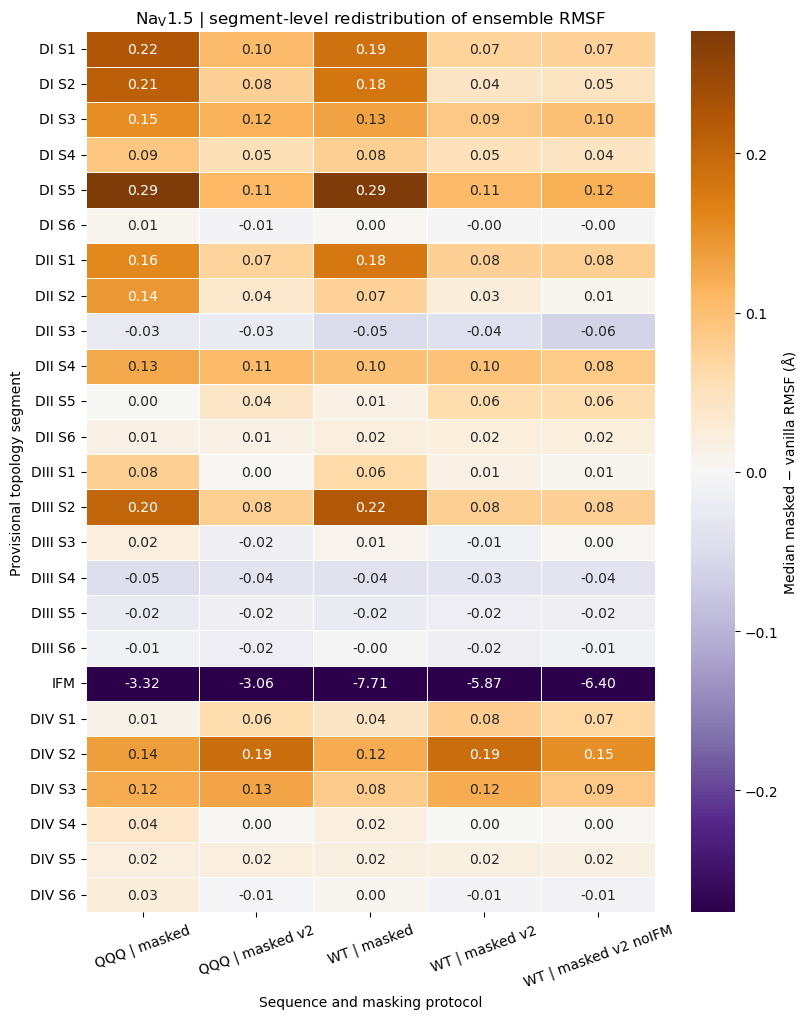

In [6]:
segment_rows=[]
for comparison in comparison_tables:
    condition=str(comparison.sequence_condition.iloc[0]);protocol=str(comparison.comparison_protocol.iloc[0])
    for segment in CHANNEL_TOPOLOGY:
        part=comparison.loc[comparison.raw_residue_number.between(segment['start'],segment['end'])]
        if part.empty: continue
        delta=part.masked_minus_vanilla_rmsf_A
        segment_rows.append({'condition':condition,'protocol':protocol,'comparison':condition.upper()+' | '+protocol.replace('_',' '),'segment':segment['label'],'domain':segment['domain'],'boundary_confidence':segment['confidence'],'raw_start':segment['start'],'raw_end':segment['end'],'number_of_residues':len(part),'number_directly_masked':int(part.directly_masked.sum()),'fraction_directly_masked':part.directly_masked.mean(),'median_delta_rmsf_A':delta.median(),'mean_delta_rmsf_A':delta.mean(),'fraction_residues_increased':delta.gt(0).mean()})
segment_summary=pd.DataFrame(segment_rows)
segment_summary.to_csv(tables/f'{CHANNEL}_topology_segment_rmsf_summary.csv',index=False)
display(segment_summary.round(3))
heat=segment_summary.pivot(index='segment',columns='comparison',values='median_delta_rmsf_A').reindex([segment['label'] for segment in CHANNEL_TOPOLOGY])
limit=max(.1,float(np.nanquantile(np.abs(heat.to_numpy()),.95)))
fig,ax=plt.subplots(figsize=(max(7,1.65*heat.shape[1]),max(5,.34*heat.shape[0]+1.8)))
sns.heatmap(heat,cmap='PuOr_r',center=0,vmin=-limit,vmax=limit,annot=True,fmt='.2f',linewidths=.4,linecolor='white',cbar_kws={'label':'Median masked − vanilla RMSF (Å)'},ax=ax)
ax.set(xlabel='Sequence and masking protocol',ylabel='Provisional topology segment',title=f'{CHANNEL_LABEL} | segment-level redistribution of ensemble RMSF');ax.tick_params(axis='x',rotation=20);ax.tick_params(axis='y',rotation=0);fig.tight_layout();fig.savefig(figures/f'{CHANNEL}_topology_segment_delta_heatmap.png',dpi=300,bbox_inches='tight');plt.show()

## Descriptive summary

The table reports the median masked-minus-vanilla RMSF inside and outside the direct mask, together with the fraction of residues for which masking increased RMSF. These values are compact descriptors of the profiles above; they are not hypothesis-test results.

A larger inside-mask median supports a localized response to targeted masking. A substantial outside-mask median or a large fraction of increased residues suggests that the effect propagates through the predicted structure or through the alignment frame. Experimental distance and RMSD comparisons are needed to determine whether that broader sampling moves toward relevant channel conformations.

In [7]:
summary=[]
for (condition,protocol),part in combined.groupby(['sequence_condition','comparison_protocol']):
    inside=part.loc[part.directly_masked,'masked_minus_vanilla_rmsf_A'].median() if MASKS_AVAILABLE else np.nan;outside=part.loc[~part.directly_masked,'masked_minus_vanilla_rmsf_A'].median()
    summary.append({'condition':condition,'protocol':protocol,'median_delta_inside_mask_A':inside,'median_delta_outside_mask_A':outside,'fraction_residues_increased':part.masked_minus_vanilla_rmsf_A.gt(0).mean()})
summary=pd.DataFrame(summary);summary.to_csv(tables/f'{CHANNEL}_automatic_summary.csv',index=False);display(summary)
print('Positive values indicate broader ensemble sampling, not inherently improved prediction. Experimental-distance deltas must be evaluated separately.')

,condition,protocol,median_delta_inside_mask_A,median_delta_outside_mask_A,fraction_residues_increased
0,qqq,masked,0.054673,0.041980,0.659033
1,qqq,masked_v2,0.041694,0.006204,0.556616
2,wt,masked,0.056304,0.030806,0.640585
3,wt,masked_v2,0.047527,0.007992,0.567430
4,wt,masked_v2_noIFM,0.055933,0.004136,0.552799


Positive values indicate broader ensemble sampling, not inherently improved prediction. Experimental-distance deltas must be evaluated separately.
